<a href="https://colab.research.google.com/github/farzadmohseni-ir/ckd-analysis/blob/main/datamining_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Data Mining Assignment 01  
## 🏥 Chronic Kidney Disease (CKD) Analysis  

---

## 🎓 Course Information  
📘 **Course:** Data Mining: Models, Algorithms, and Applications  
👨‍🏫 **Instructor:** Dr. Ahmadi  
🏫 **University:** Amirkabir University of Technology (Tehran Polytechnic)  

---

# 📌 Problem Description  

🧪 Select the **Chronic Kidney Disease (CKD)** dataset from the  
**UCI Machine Learning Repository** and provide a brief description of it.



# 🧩 Assignment Tasks  

## 🔧 (A) Data Preparation  

- Handle **missing values** and **noisy data**  
- Apply **data standardization** using **three different methods**



## 📉 (B) Feature Reduction  

Apply the following feature selection methods:

- 🔹 Filter Method  
- 🔹 Forward Selection  
- 🔹 Backward Elimination  
- 🔹 Hybrid Method (Forward + Backward)  
  - Explain how parameters **L** and **R** are selected  

📊 For each method:

- Present the selected features  
- Analyze and compare results in terms of:
  - Number of features  
  - Quality (performance)

📌 When needed, use **K-Nearest Neighbors (KNN)** for classification.



## 🧠 (C) Principal Component Analysis (PCA)  

- Apply PCA on the dataset  
- Determine how much variance each component explains  
- Plot the **Scree Plot**  
- Select the optimal number of components with justification  



## 🏁 (D) Final Evaluation  

Based on accuracy:

- Compare all methods:
  - Filter  
  - Forward  
  - Backward  
  - Hybrid  
  - PCA  

🎯 Determine which method provides the **best performance compared to using all features**.

---

# 📊 Dataset Overview  

- 📦 **Total Records:** 400  
- 📦 **Total Columns:** 26 (including ID and target)  
- 🆔 **ID Column:** Unique identifier (not used as a feature)  
- 📥 **Input Features:** 24  
- 🎯 **Target Variable:** `classification` (ckd / notckd)  
- 🔢 **Numerical Features:** 11  
- 🔤 **Nominal Features:** 14  
- ⚠️ **Missing Values:** Yes  

🔗 **Dataset Link:**  
https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease  

---

# 🧾 Feature Names and Descriptions  

| No. | Attribute | Type | Meaning | Description |
|-----|----------|------|---------|-------------|
| 0 | id | Nominal | Record ID | Unique identifier for each record |
| 1 | age | Numerical | Age | Age in years |
| 2 | bp | Numerical | Blood Pressure | Blood pressure in mm/Hg |
| 3 | sg | Nominal | Specific Gravity | Values: 1.005, 1.010, 1.015, 1.020, 1.025 |
| 4 | al | Nominal | Albumin | Values: 0, 1, 2, 3, 4, 5 |
| 5 | su | Nominal | Sugar | Values: 0, 1, 2, 3, 4, 5 |
| 6 | rbc | Nominal | Red Blood Cells | Values: normal, abnormal |
| 7 | pc | Nominal | Pus Cell | Values: normal, abnormal |
| 8 | pcc | Nominal | Pus Cell Clumps | Values: present, notpresent |
| 9 | ba | Nominal | Bacteria | Values: present, notpresent |
| 10 | bgr | Numerical | Blood Glucose Random | Measured in mgs/dl |
| 11 | bu | Numerical | Blood Urea | Measured in mgs/dl |
| 12 | sc | Numerical | Serum Creatinine | Measured in mgs/dl |
| 13 | sod | Numerical | Sodium | Measured in mEq/L |
| 14 | pot | Numerical | Potassium | Measured in mEq/L |
| 15 | hemo | Numerical | Hemoglobin | Measured in gms |
| 16 | pcv | Numerical | Packed Cell Volume | Packed cell volume |
| 17 | wc | Numerical | White Blood Cell Count | Measured in cells/cumm |
| 18 | rc | Numerical | Red Blood Cell Count | Measured in millions/cmm |
| 19 | htn | Nominal | Hypertension | Values: yes, no |
| 20 | dm | Nominal | Diabetes Mellitus | Values: yes, no |
| 21 | cad | Nominal | Coronary Artery Disease | Values: yes, no |
| 22 | appet | Nominal | Appetite | Values: good, poor |
| 23 | pe | Nominal | Pedal Edema | Values: yes, no |
| 24 | ane | Nominal | Anemia | Values: yes, no |
| 25 | classification | Nominal | Class Label | Values: ckd (Chronic Kidney Disease), notckd (Not CKD) |

---

In [ ]:
# ============================================================
# BOX 1 — Load CKD dataset from Google Drive into Colab
# ============================================================

import os
import numpy as np
import pandas as pd

# ----------------------------
# Install gdown (if missing)
# ----------------------------
try:
    import gdown
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "gdown"], check=True)
    import gdown

# ----------------------------
# Config
# ----------------------------
FILE_ID = "1be3sZ9fZiilOaRr9pWLnEN9hkgKyV_uy"
OUTPUT_FILE = "ckd_dataset.csv"
DOWNLOAD_URL = f"https://drive.google.com/uc?id={FILE_ID}"

# ----------------------------
# Download (with overwrite safety)
# ----------------------------
if not os.path.exists(OUTPUT_FILE):
    print("Downloading dataset...")
    gdown.download(DOWNLOAD_URL, OUTPUT_FILE, quiet=False)
else:
    print("File already exists. Skipping download.")

# ----------------------------
# Validate file
# ----------------------------
if not os.path.exists(OUTPUT_FILE):
    raise FileNotFoundError(f"Download failed: '{OUTPUT_FILE}' not found.")

# ----------------------------
# Load dataset
# ----------------------------
df = pd.read_csv(OUTPUT_FILE)

# ----------------------------
# Basic sanity checks
# ----------------------------
print("Dataset loaded successfully ")

df.head()

File already exists. Skipping download.
Dataset loaded successfully 


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
# ============================================================
# BOX 2 — Inspect dataset shape
# ============================================================

n_rows, n_cols = df.shape

print(f"Number of samples (rows): {n_rows}")
print(f"Number of features (columns): {n_cols}")

Number of samples (rows): 400
Number of features (columns): 26


In [ ]:
# ============================================================
# BOX 3 — Inspect column names
# ============================================================

print("Column names:")
print(df.columns.tolist())

Column names:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [ ]:
# ============================================================
# BOX 4 — Inspect data types and missing structure
# ============================================================

print("=== DataFrame Info ===")
df.info()

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc          

In [ ]:
# ============================================================
# BOX 5 — Remove ID column
# ============================================================

# Drop 'id' column if it exists
if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("Column 'id' removed successfully.")
else:
    print("Column 'id' not found.")

# Verify updated columns
print("\nRemaining columns:")
print(df.columns.tolist())

Column 'id' removed successfully.

Remaining columns:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [ ]:
# ============================================================
# BOX 6 — Detect and remove duplicate rows
# ============================================================

# ----------------------------
# Count duplicate rows
# ----------------------------
duplicate_mask = df.duplicated(keep='first')
duplicate_count = int(duplicate_mask.sum())

print(f"Number of duplicate rows before removal: {duplicate_count}")

# ----------------------------
# Optional: Inspect duplicates (for analysis/reporting)
# ----------------------------
if duplicate_count > 0:
    print("\nSample duplicate rows:")
    display(df[duplicate_mask].head())

# ----------------------------
# Remove duplicates
# ----------------------------
if duplicate_count > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print("\nDuplicate rows removed successfully.")
else:
    print("\nNo duplicate rows found.")

# ----------------------------
# Final verification
# ----------------------------
print(f"\nDataset shape after duplicate removal: {df.shape}")

# Sanity check
assert df.duplicated().sum() == 0, "Duplicates still exist!"

Number of duplicate rows before removal: 0

No duplicate rows found.

Dataset shape after duplicate removal: (400, 25)


In [ ]:
# ============================================================
# BOX 7 — Class Distribution (CKD vs Non-CKD)
#   - Clean class labels (non-destructive)
#   - Show class counts and percentages (consistent order)
# ============================================================

# Clean text labels (temporary)
classification_clean = df["classification"].astype(str).str.strip().str.lower()

# Counts
counts = classification_clean.value_counts().sort_index()

print("Class counts:")
print(counts)

# Percentages
percent = (classification_clean.value_counts(normalize=True) * 100).sort_index()

print("\nClass percentage (%):")
print(percent.round(2))

Class counts:
classification
ckd       250
notckd    150
Name: count, dtype: int64

Class percentage (%):
classification
ckd       62.5
notckd    37.5
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# BOX 8 — Descriptive Statistics
#   - Summary statistics for numerical features
# ============================================================

# Descriptive statistics
desc = df.describe().T.round(3)

print("=== Descriptive Statistics (Numeric Features) ===")
display(desc)

=== Descriptive Statistics (Numeric Features) ===


,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483,17.170,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469,13.684,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017,0.006,1.005,1.01,1.02,1.02,1.025
al,354.0,1.017,1.353,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450,1.099,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.037,79.282,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.426,50.503,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072,5.741,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.529,10.409,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627,3.194,2.500,3.80,4.40,4.90,47.000


In [ ]:
# ============================================================
# BOX 9 — Clean and encode 'rbc' and 'pc' columns
#   - Remove extra spaces and inconsistencies
#   - Standardize text values
#   - Convert categorical values to numeric (binary encoding)
# ============================================================

# Columns to process
cols = ['rbc', 'pc']

for col in cols:
    # Step 1: Convert to string (safe handling)
    df[col] = df[col].astype("string")

    # Step 2: Clean text
    df[col] = df[col].str.strip().str.lower()

    # Step 3: Replace invalid placeholders
    df[col] = df[col].replace(['nan', 'none', '', '?'], np.nan)  # '?' added

    # Step 4: Encode values
    df[col] = df[col].map({
        'normal': 1,
        'abnormal': 0
    })

In [ ]:
# ============================================================
# BOX 10 — Clean and encode 'pcc' and 'ba' columns
#   - Standardize categorical text values
#   - Convert 'present' / 'notpresent' to numeric (1 / 0)
# ============================================================

# Columns to process
cols = ['pcc', 'ba']

for col in cols:
    # Step 1: Convert to string (safe)
    df[col] = df[col].astype("string")

    # Step 2: Clean text
    df[col] = df[col].str.strip().str.lower()

    # Step 3: Replace invalid placeholders
    df[col] = df[col].replace(['nan', 'none', '', '?'], np.nan)  # '?' added

    # Step 4: Encode values
    df[col] = df[col].map({
        'present': 1,
        'notpresent': 0
    })

In [ ]:
# ============================================================
# BOX 11 — Clean and encode 'htn', 'dm', 'cad', 'pe', 'ane'
#   - Fix messy text values (spaces, tabs, casing)
#   - Convert 'yes' / 'no' to numeric (1 / 0)
# ============================================================

# Columns to process
cols = ['htn', 'dm', 'cad', 'pe', 'ane']

for col in cols:
    # Step 1: Convert to string safely
    df[col] = df[col].astype("string")

    # Step 2: Clean text
    df[col] = df[col].str.strip().str.lower()
    df[col] = df[col].str.replace(r'\t', '', regex=True)

    # Step 3: Replace invalid placeholders with NaN
    df[col] = df[col].replace(['nan', 'none', '', '?'], np.nan)

    # Step 4: Encode values
    df[col] = df[col].map({
        'yes': 1,
        'no': 0
    })

In [ ]:
# ============================================================
# BOX 12 — Clean and encode 'appet'
#   - Standardize text values in the appetite column
#   - Convert 'good' / 'poor' to numeric (1 / 0)
# ============================================================

# Column to process
col = 'appet'

# Step 1: Convert to string (safe)
df[col] = df[col].astype("string")

# Step 2: Clean text
df[col] = df[col].str.strip().str.lower()
df[col] = df[col].str.replace(r'\t', '', regex=True)

# Step 3: Replace invalid placeholders
df[col] = df[col].replace(['nan', 'none', '', '?'], np.nan)

# Step 4: Encode values
df[col] = df[col].map({
    'good': 1,
    'poor': 0
})

In [ ]:
# ============================================================
# BOX 13 — Clean and encode 'classification' (target variable)
#   - Standardize target labels
#   - Convert 'ckd' / 'notckd' to numeric (1 / 0)
# ============================================================

col = 'classification'

# Step 1: Convert to string (safe)
df[col] = df[col].astype("string")

# Step 2: Clean text
df[col] = df[col].str.strip().str.lower()
df[col] = df[col].str.replace(r'\t', '', regex=True)

# Step 3: Replace invalid placeholders
df[col] = df[col].replace(['nan', 'none', '', '?'], np.nan)

# Step 4: Encode target
df[col] = df[col].map({
    'ckd': 1,
    'notckd': 0
}).astype("Int64")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    float64
 6   pc              335 non-null    float64
 7   pcc             396 non-null    float64
 8   ba              396 non-null    float64
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    object 
 16  wc              295 non-null    object 
 17  rc              270 non-null    obj

In [ ]:
# ============================================================
# BOX 14 — Convert 'pcv', 'wc', 'rc' from object to numeric
#   - These columns are numeric but stored as strings
#   - Clean text and convert to float
# ============================================================

cols = ['pcv', 'wc', 'rc']

for col in cols:
    # Step 1: Convert to string
    df[col] = df[col].astype("string")

    # Step 2: Clean text (remove spaces and tabs)
    df[col] = df[col].str.strip()
    df[col] = df[col].str.replace('\t', '', regex=True)

    # Step 3: Replace invalid values with NaN
    df[col] = df[col].replace(['nan', 'none', '', '?'], np.nan)

    # Step 4: Convert to numeric
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)

# Check result
print(df[['pcv', 'wc', 'rc']].dtypes)

pcv    float64
wc     float64
rc     float64
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    float64
 6   pc              335 non-null    float64
 7   pcc             396 non-null    float64
 8   ba              396 non-null    float64
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              269 non-null    flo

In [ ]:
# ============================================================
# BOX 15 — Comprehensive missing value detection (robust)
#   - Detect ALL types of missing/invalid values
#   - Report count and percentage per column
#   - Based on total dataset size (400 rows)
# ============================================================

# Create a safe copy
df_check = df.copy()

# Standardize any remaining invalid text-like entries to NaN
df_check = df_check.replace(
    ["", " ", "  ", "\t", "nan", "NaN", "none", "None"],
    np.nan
)

# Compute missing counts
missing_count = df_check.isnull().sum()

# Total rows
total_rows = len(df_check)

# Compute missing percentage
missing_percent = ((missing_count / total_rows) * 100).round(2)

# Build report
missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent (%)": missing_percent
}).sort_values(by="missing_count", ascending=False)

# Display
print("Missing Values Report (per column):")
display(missing_report)

Missing Values Report (per column):


,missing_count,missing_percent (%)
rbc,152,38.00
rc,131,32.75
wc,106,26.50
pot,88,22.00
sod,87,21.75
pcv,71,17.75
pc,65,16.25
hemo,52,13.00
su,49,12.25
sg,47,11.75


In [ ]:
# ============================================================
# BOX 16 — Count Complete vs Incomplete Records
# Purpose:
#   - Identify rows with missing values
#   - Count complete and incomplete records
# ============================================================

# Number of rows with at least one missing value
incomplete_rows = df.isnull().any(axis=1).sum()

# Number of rows with NO missing values
complete_rows = df.isnull().sum(axis=1).eq(0).sum()

# Total rows
total_rows = len(df)

# Print results
print("Total rows        :", total_rows)
print("Complete rows     :", complete_rows)
print("Incomplete rows   :", incomplete_rows)

Total rows        : 400
Complete rows     : 158
Incomplete rows   : 242


In [ ]:
# ============================================================
# BOX 17 — Detect Highly Incomplete Rows (High Missing Ratio)
# ============================================================

# Calculate missing ratio per row
missing_ratio = df.isnull().mean(axis=1)

# Define threshold (e.g., more than 50% missing)
threshold = 0.5

# Count rows above threshold
high_missing_rows = (missing_ratio > threshold).sum()

# Total rows
total_rows = len(df)

# Print results
print("Total rows                :", total_rows)
print("Rows with >50% missing    :", high_missing_rows)
print("Percentage (%)            :", round(100 * high_missing_rows / total_rows, 2))

Total rows                : 400
Rows with >50% missing    : 0
Percentage (%)            : 0.0


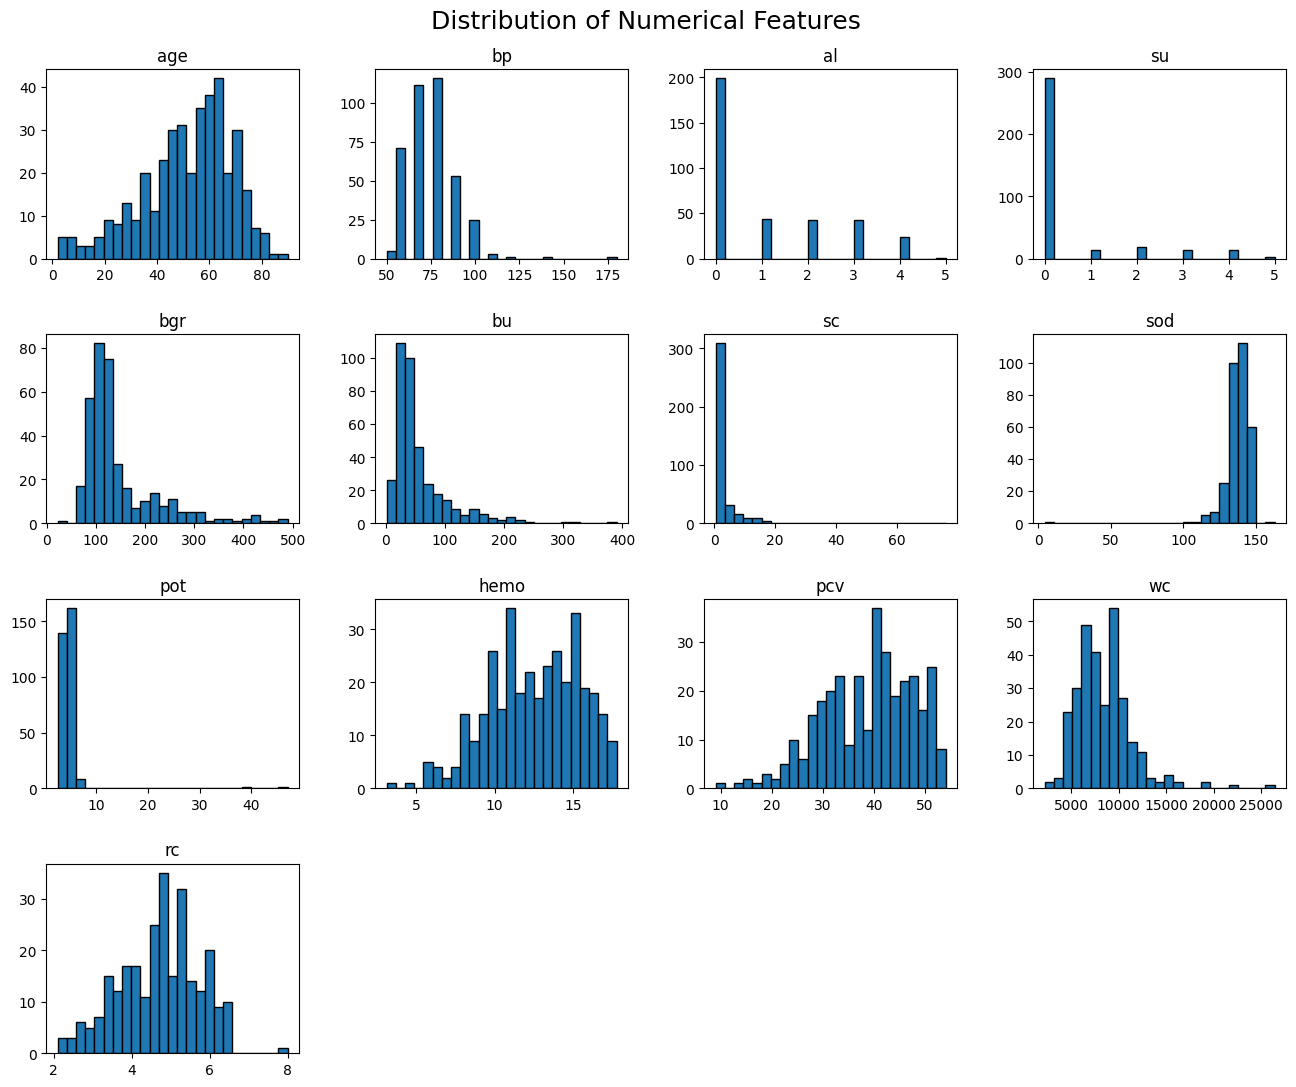

In [ ]:
# ============================================================
# BOX 18 — Histogram Analysis of Numerical Features
#   - Visualize the distribution of numerical features
#   - Examine spread, skewness, and overall shape
#   - Exclude binary / low-variation features for cleaner plots
#   - Non-destructive: this box does NOT modify the original dataframe
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Step 1 — Select numerical features only
# ------------------------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns

# ------------------------------------------------------------
# Step 2 — Exclude binary or low-variation features
# Reason:
#   Features with very few unique values are not informative in
#   histogram-based distribution analysis and may reduce readability.
# ------------------------------------------------------------
numeric_cols = [
    col for col in numeric_cols
    if df[col].nunique() > 5
]

# ------------------------------------------------------------
# Step 3 — Plot histograms
# ------------------------------------------------------------
df[numeric_cols].hist(
    figsize=(16, 12),
    bins=25,
    edgecolor="black"
)

# ------------------------------------------------------------
# Step 4 — Improve figure layout and readability
# ------------------------------------------------------------
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.subplots_adjust(top=0.93, hspace=0.4, wspace=0.3)

# Remove subplot gridlines for a cleaner appearance
for ax in plt.gcf().axes:
    ax.grid(False)

plt.show()

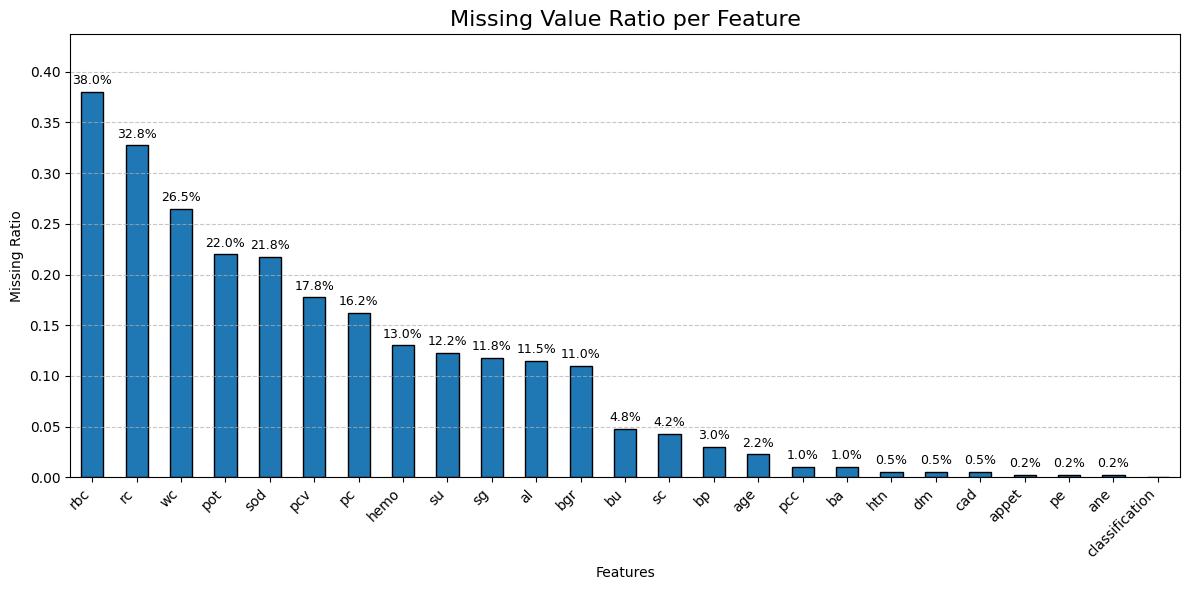

In [ ]:
# ============================================================
# BOX 19 — Missing Value Ratio per Feature
#   - Quantify and visualize the proportion of missing values
#     for each feature
#   - Support decision-making for imputation or feature removal
#   - Non-destructive: does NOT modify the original dataframe
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 1 — Compute missing ratio per feature
# ------------------------------------------------------------
missing_ratio = (
    df.isnull()
    .mean()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# Step 2 — Create bar plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

ax = missing_ratio.plot(
    kind="bar",
    edgecolor="black"
)

# ------------------------------------------------------------
# Step 3 — Styling and readability improvements
# ------------------------------------------------------------
plt.title("Missing Value Ratio per Feature", fontsize=16)
plt.ylabel("Missing Ratio")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")

# Add horizontal grid for easier comparison
plt.grid(axis="y", linestyle="--", alpha=0.7)

# ------------------------------------------------------------
# Step 4 — Add percentage labels above bars
# ------------------------------------------------------------
y_max = missing_ratio.max()

# Handle edge case: no missing values at all
if y_max == 0:
    y_max = 1  # prevent zero scaling issues

for i, v in enumerate(missing_ratio):
    if v > 0:  # show labels only for non-zero values
        ax.text(
            i,
            v + 0.02 * y_max,
            f"{v * 100:.1f}%",
            ha="center",
            fontsize=9
        )

# Expand y-axis to prevent label clipping
plt.ylim(0, y_max * 1.15)

# ------------------------------------------------------------
# Final layout
# ------------------------------------------------------------
plt.tight_layout()
plt.show()

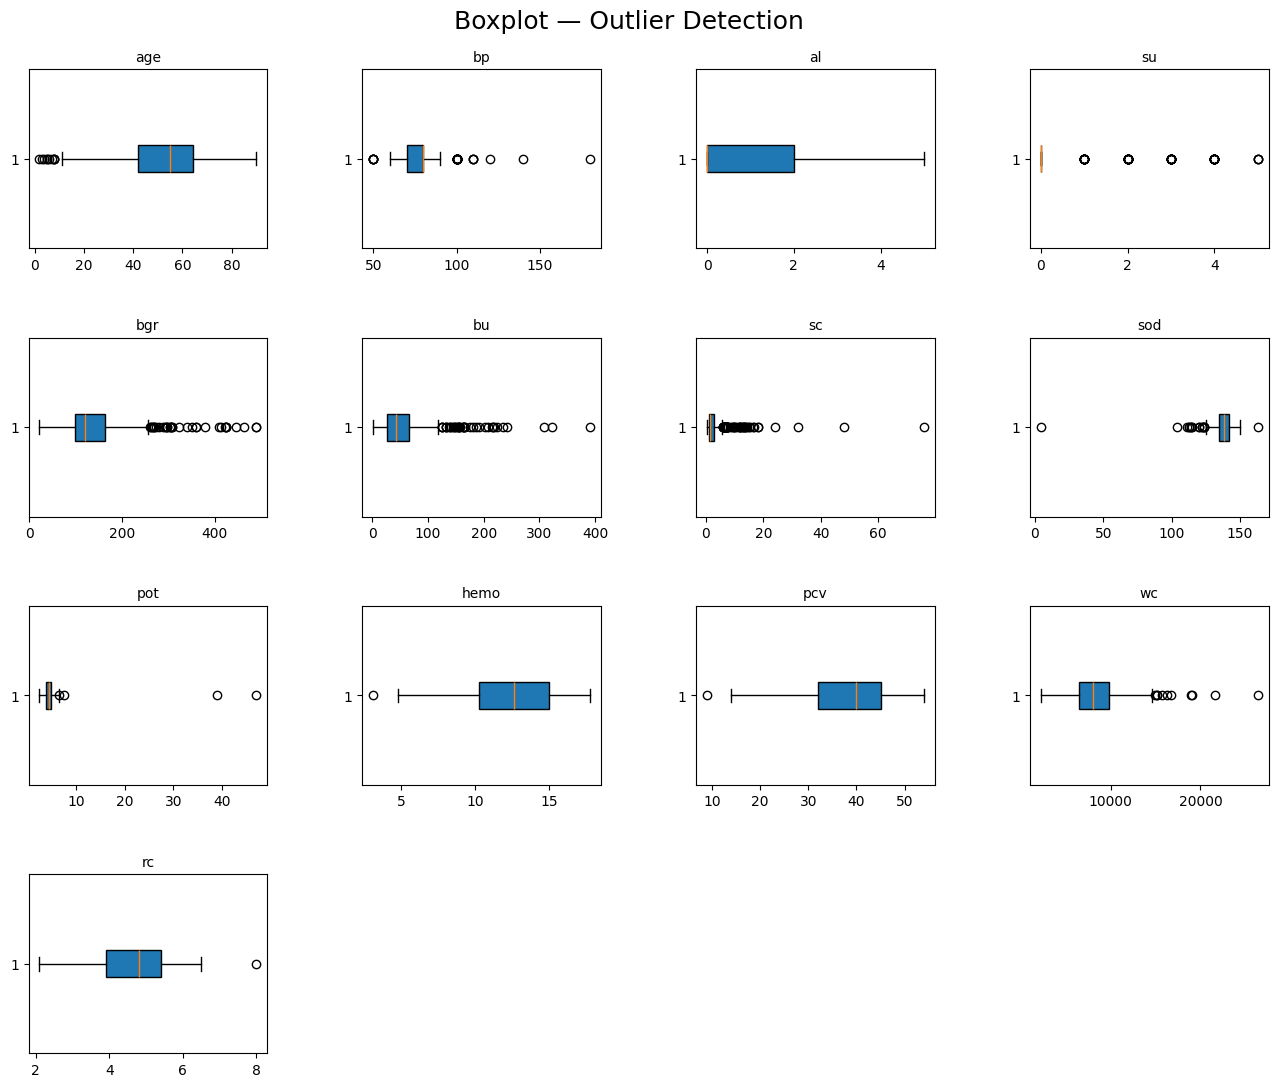

In [ ]:
# ============================================================
# BOX 20 — Boxplot Analysis for Outlier Detection
#   - Visualize potential outliers in numerical features
#   - Support imputation strategy selection (e.g., mean vs median)
#   - Exclude binary / low-variation features for clearer analysis
#   - Non-destructive: this box does NOT modify the original dataframe
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Step 1 — Select numerical features only
# ------------------------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns

# ------------------------------------------------------------
# Step 2 — Exclude binary or low-variation features
# Reason:
#   Features with very few unique values are not suitable for
#   boxplot-based outlier analysis and may reduce readability.
# ------------------------------------------------------------
numeric_cols = [
    col for col in numeric_cols
    if df[col].nunique() > 5
]

# ------------------------------------------------------------
# Step 3 — Define subplot grid size
# ------------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# ------------------------------------------------------------
# Step 4 — Create subplot canvas
# ------------------------------------------------------------
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))

# Ensure axes is always one-dimensional for robust iteration
axes = np.array(axes).reshape(-1)

# ------------------------------------------------------------
# Step 5 — Plot one boxplot per feature
# ------------------------------------------------------------
for i, col in enumerate(numeric_cols):
    feature_data = df[col].dropna()

    axes[i].boxplot(
        feature_data,
        vert=False,
        patch_artist=True
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(False)

# ------------------------------------------------------------
# Step 6 — Remove unused subplot axes
# ------------------------------------------------------------
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# ------------------------------------------------------------
# Step 7 — Adjust figure layout
# ------------------------------------------------------------
plt.suptitle("Boxplot — Outlier Detection", fontsize=18)
plt.subplots_adjust(top=0.93, hspace=0.5, wspace=0.4)

plt.show()

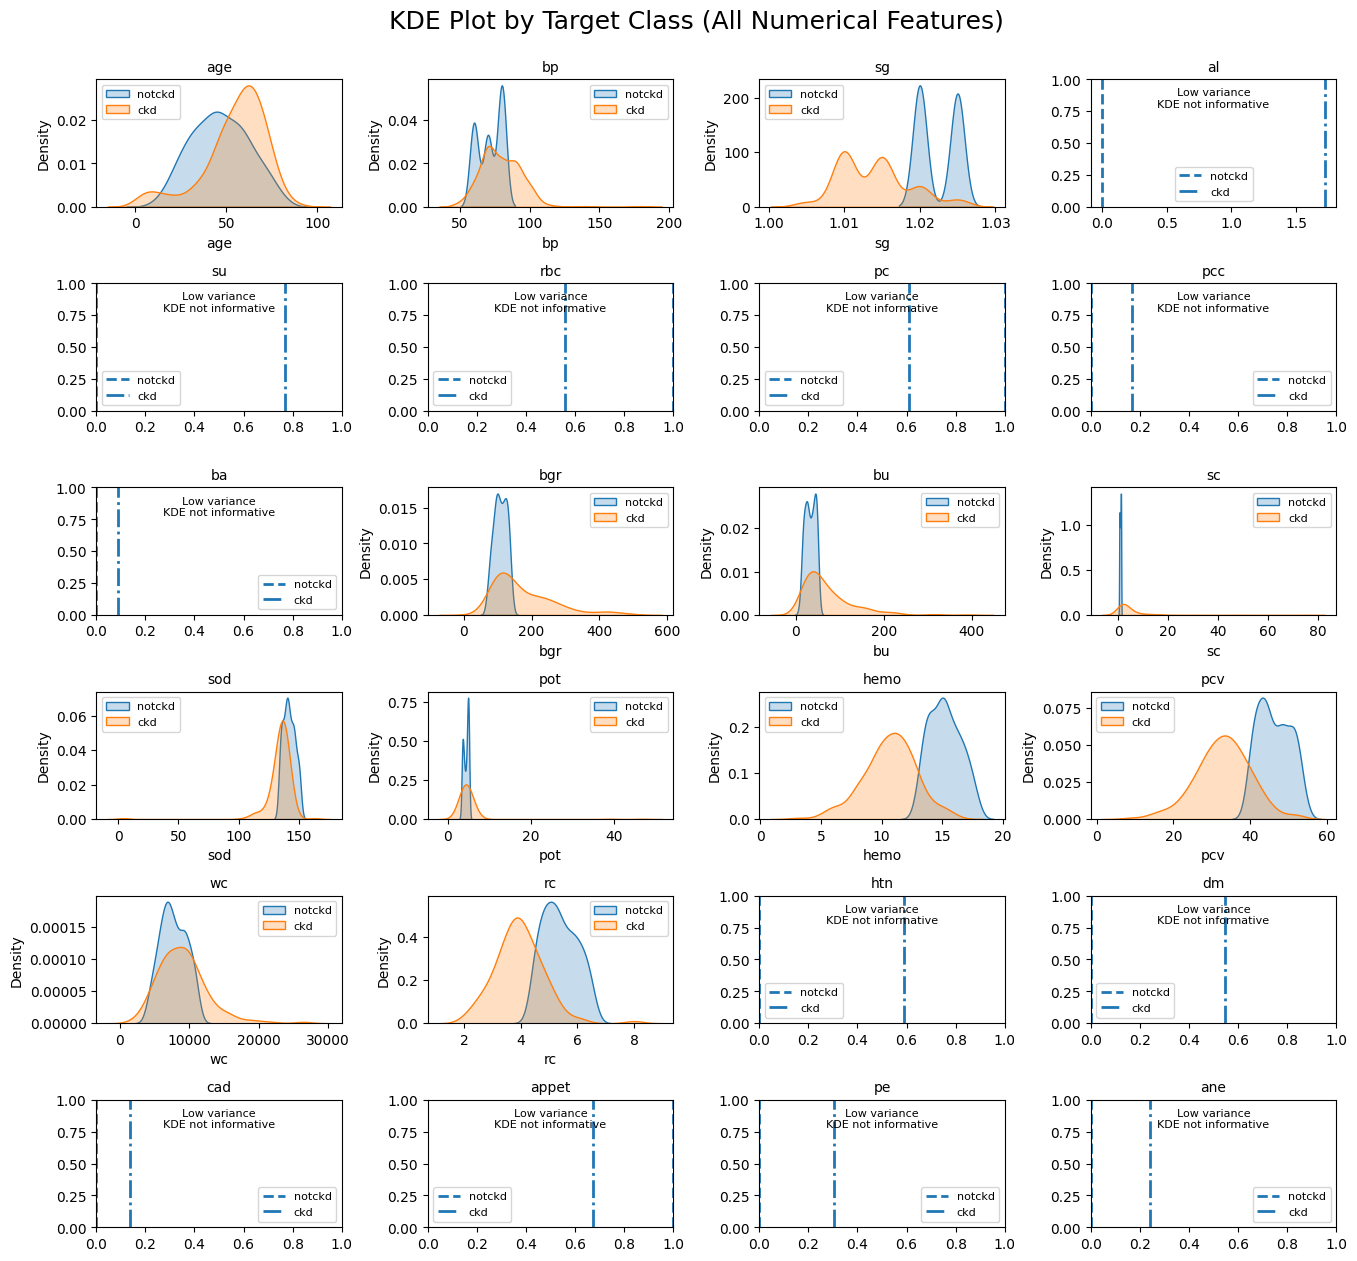

In [ ]:
# ============================================================
# BOX 21 — KDE Plot by Target Class (Show All Features)
#   - Compare the distribution of all numerical features across
#     the two target classes
#   - Show every numerical feature except the target itself
#   - Fall back to vertical reference lines when KDE is not
#     meaningful because one class has zero variance
#   - Target is assumed to be already encoded:
#         0 = notckd
#         1 = ckd
#   - Non-destructive: this box does NOT modify the original dataframe
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------
# Step 1 — Define target column
# ------------------------------------------------------------
target_col = "classification"

# ------------------------------------------------------------
# Step 2 — Select all numerical features except the target
# ------------------------------------------------------------
numeric_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col != target_col
]

# ------------------------------------------------------------
# Step 3 — Define subplot grid size
# ------------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# ------------------------------------------------------------
# Step 4 — Create subplot canvas
# ------------------------------------------------------------
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
axes = np.array(axes).reshape(-1)

# ------------------------------------------------------------
# Step 5 — Plot each feature
# ------------------------------------------------------------
for i, col in enumerate(numeric_cols):
    ax = axes[i]

    data_0 = df.loc[df[target_col] == 0, col].dropna()
    data_1 = df.loc[df[target_col] == 1, col].dropna()

    var_0_ok = data_0.nunique() > 1
    var_1_ok = data_1.nunique() > 1

    # Case 1: both classes have enough variation for KDE
    if var_0_ok and var_1_ok:
        sns.kdeplot(
            x=data_0,
            fill=True,
            warn_singular=False,
            ax=ax,
            label="notckd"
        )
        sns.kdeplot(
            x=data_1,
            fill=True,
            warn_singular=False,
            ax=ax,
            label="ckd"
        )

    # Case 2: one or both classes have zero variance
    else:
        # Plot constant-value reference lines when possible
        if len(data_0) > 0:
            ax.axvline(
                data_0.iloc[0] if data_0.nunique() == 1 else data_0.mean(),
                linestyle="--",
                linewidth=2,
                label="notckd"
            )

        if len(data_1) > 0:
            ax.axvline(
                data_1.iloc[0] if data_1.nunique() == 1 else data_1.mean(),
                linestyle="-.",
                linewidth=2,
                label="ckd"
            )

        ax.text(
            0.5, 0.85,
            "Low variance\nKDE not informative",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=8
        )

    ax.set_title(col, fontsize=10)
    ax.grid(False)
    ax.legend(fontsize=8)

# ------------------------------------------------------------
# Step 6 — Remove unused subplot axes
# ------------------------------------------------------------
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# ------------------------------------------------------------
# Step 7 — Adjust layout
# ------------------------------------------------------------
plt.suptitle("KDE Plot by Target Class (All Numerical Features)", fontsize=18)
plt.subplots_adjust(top=0.93, hspace=0.6, wspace=0.35)

plt.show()

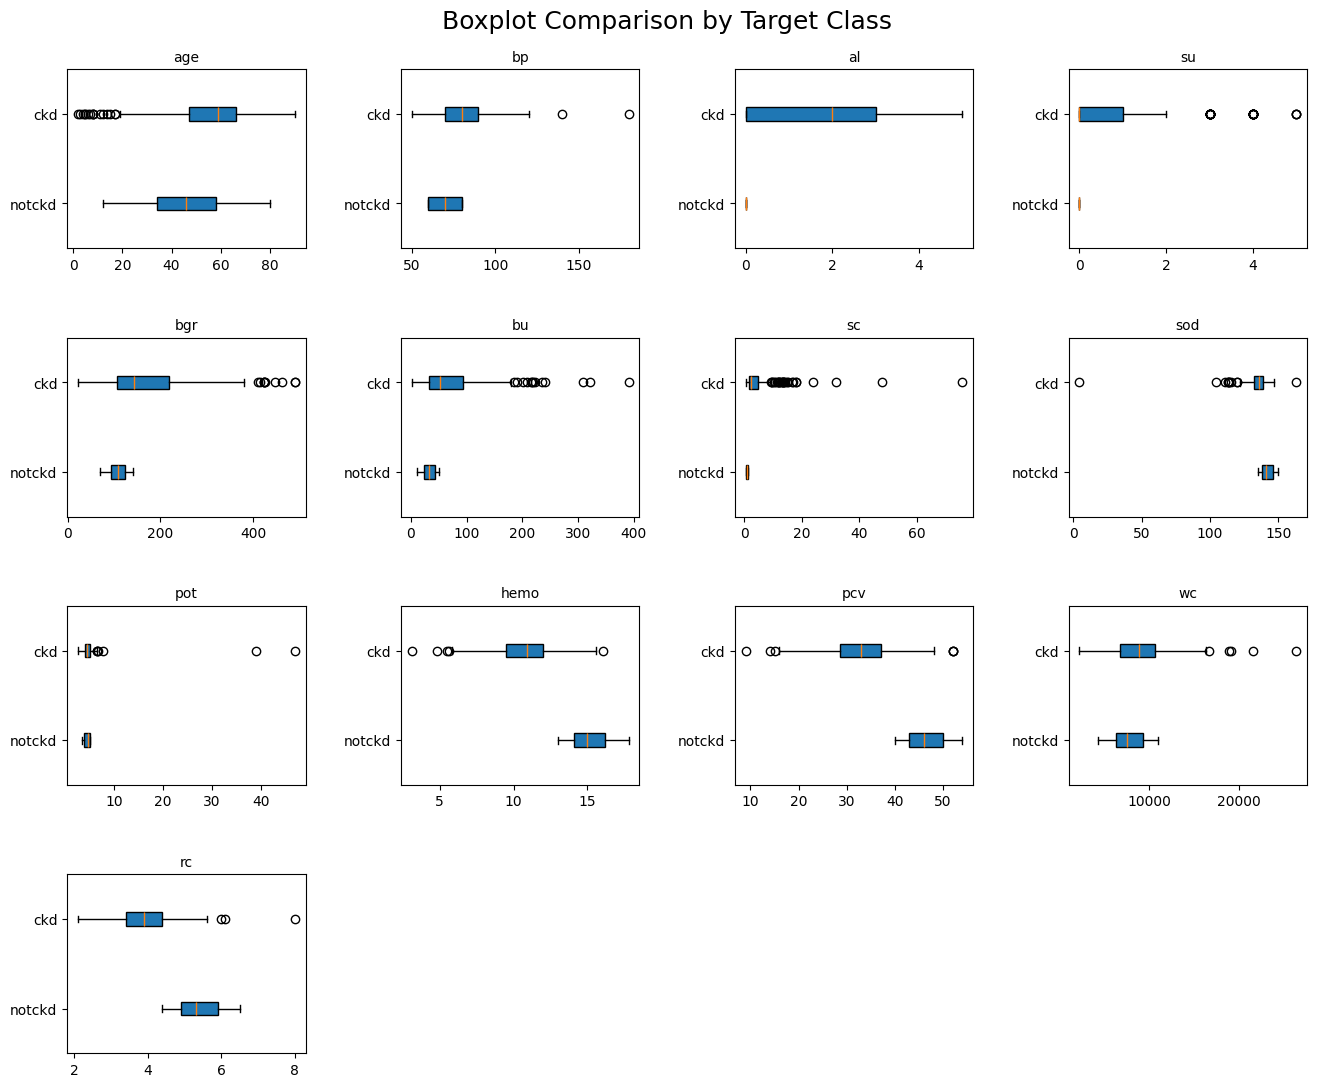

In [ ]:
# ============================================================
# BOX 22 — Boxplot Comparison by Target Class
#   - Compare the distribution of numerical features across
#     the two target classes
#   - Highlight differences in central tendency, spread,
#     and potential class separation
#   - Target is assumed to be already encoded:
#         0 = notckd
#         1 = ckd
#   - Non-destructive: this box does NOT modify the original dataframe
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Step 1 — Define target column
# ------------------------------------------------------------
target_col = "classification"

# ------------------------------------------------------------
# Step 2 — Select numerical features only
# ------------------------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns

# ------------------------------------------------------------
# Step 3 — Exclude the target column and low-variation features
# Reason:
#   Features with very few unique values are not informative
#   for continuous boxplot comparison and may reduce clarity.
# ------------------------------------------------------------
numeric_cols = [
    col for col in numeric_cols
    if col != target_col and df[col].nunique() > 5
]

# ------------------------------------------------------------
# Step 4 — Define subplot grid size
# ------------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# ------------------------------------------------------------
# Step 5 — Create subplot canvas
# ------------------------------------------------------------
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = np.array(axes).reshape(-1)

# ------------------------------------------------------------
# Step 6 — Plot one boxplot per feature by target class
# ------------------------------------------------------------
for i, col in enumerate(numeric_cols):
    data_0 = df.loc[df[target_col] == 0, col].dropna()
    data_1 = df.loc[df[target_col] == 1, col].dropna()

    # Plot only if both classes contain at least one valid value
    if len(data_0) > 0 and len(data_1) > 0:
        axes[i].boxplot(
            [data_0, data_1],
            tick_labels=["notckd", "ckd"],
            vert=False,
            patch_artist=True
        )
        axes[i].set_title(col, fontsize=10)
        axes[i].grid(False)
    else:
        axes[i].set_visible(False)

# ------------------------------------------------------------
# Step 7 — Remove unused subplot axes
# ------------------------------------------------------------
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# ------------------------------------------------------------
# Step 8 — Adjust figure layout
# ------------------------------------------------------------
plt.suptitle("Boxplot Comparison by Target Class", fontsize=18)
plt.subplots_adjust(top=0.93, hspace=0.5, wspace=0.4)

plt.show()

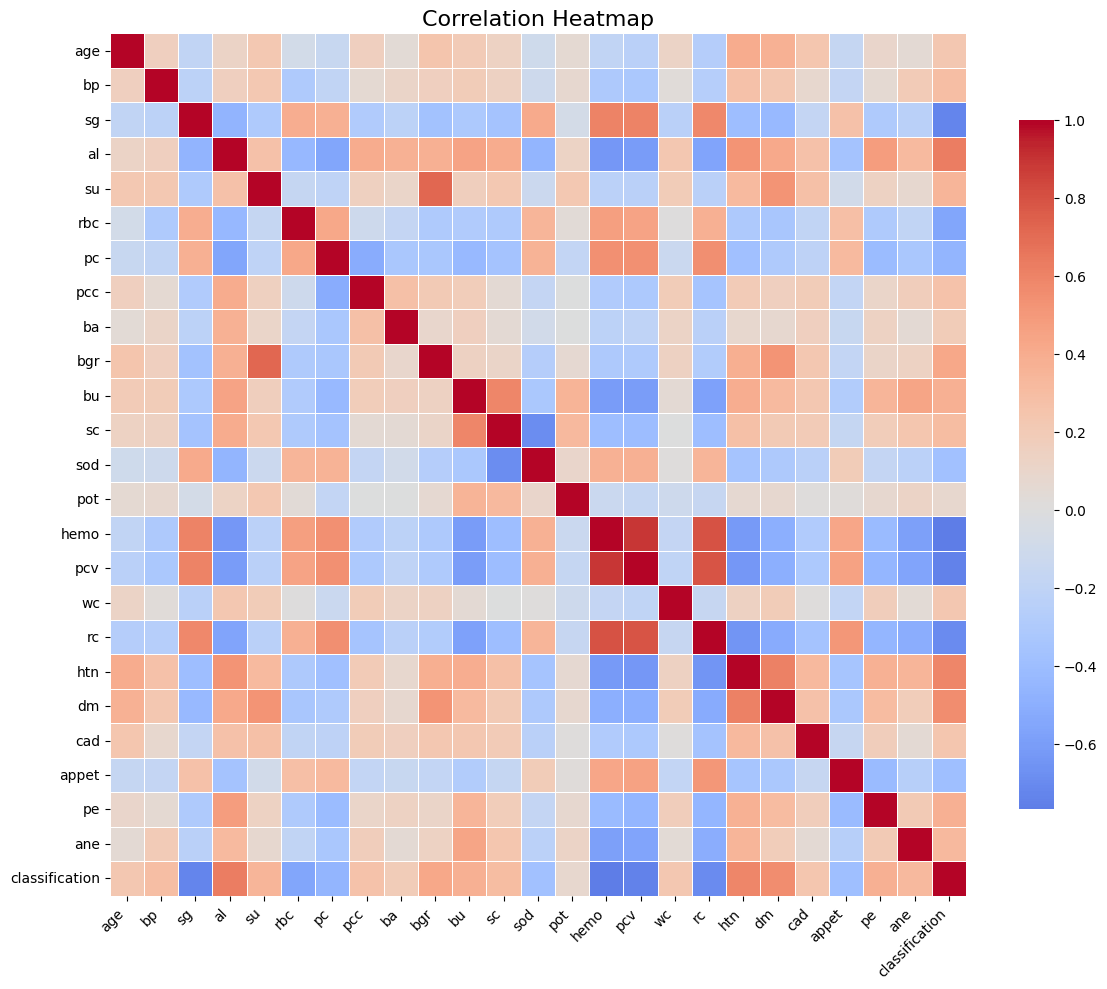

In [ ]:
# ============================================================
# BOX 23 — Correlation Heatmap of Numerical Features
#   - Visualize pairwise linear relationships between numerical features
#   - Detect multicollinearity and redundant variables
#   - Support feature selection and dimensionality reduction
#   - Uses Pearson correlation by default
#   - Non-destructive: does NOT modify the original dataframe
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------
# Step 1 — Select numerical features only
# ------------------------------------------------------------
numeric_df = df.select_dtypes(include=np.number)

# ------------------------------------------------------------
# Step 2 — Compute correlation matrix
# ------------------------------------------------------------
corr_matrix = numeric_df.corr()

# ------------------------------------------------------------
# Step 3 — Plot heatmap
# ------------------------------------------------------------
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=False,
    cbar_kws={"shrink": 0.8},
    annot=False  # keep clean (avoid clutter for many features)
)

# ------------------------------------------------------------
# Step 4 — Improve readability
# ------------------------------------------------------------
plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# ------------------------------------------------------------
# Step 5 — Final layout
# ------------------------------------------------------------
plt.tight_layout()
plt.show()

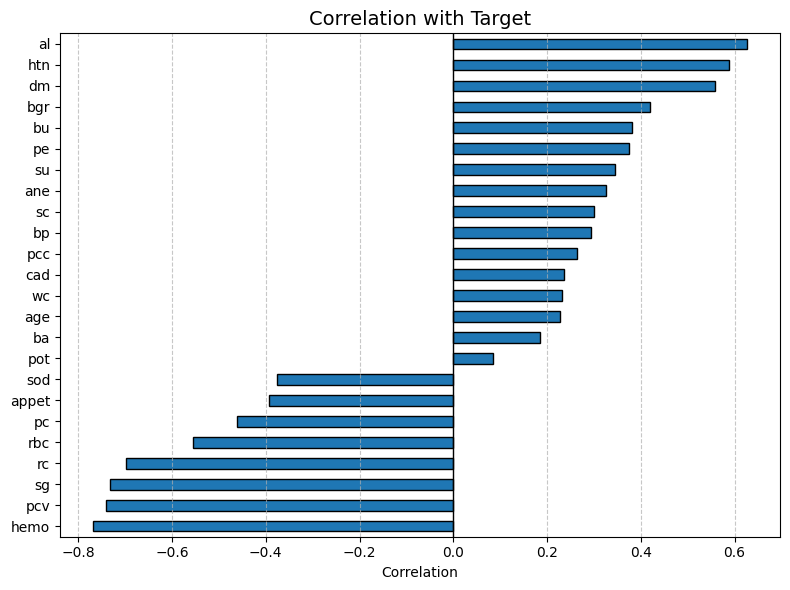

In [ ]:
# ============================================================
# BOX 24 — Correlation with Target Variable
#   - Measure linear relationship between each numerical feature
#     and the target variable
#   - Identify potentially important features for classification
#   - Uses Pearson correlation
#   - Target must be numeric (e.g., 0 = notckd, 1 = ckd)
#   - Non-destructive: does NOT modify the original dataframe
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 1 — Define target column
# ------------------------------------------------------------
target_col = "classification"

# ------------------------------------------------------------
# Step 2 — Compute correlation with target
# ------------------------------------------------------------
numeric_df = df.select_dtypes(include='number')

# Ensure target exists in numeric columns
if target_col not in numeric_df.columns:
    raise ValueError(f"Target column '{target_col}' must be numeric.")

corr_with_target = (
    numeric_df
    .corr()[target_col]
    .drop(target_col)
    .sort_values()
)

# ------------------------------------------------------------
# Step 3 — Plot horizontal bar chart
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

ax = corr_with_target.plot(
    kind="barh",
    edgecolor="black"
)

# ------------------------------------------------------------
# Step 4 — Styling and readability improvements
# ------------------------------------------------------------
plt.title("Correlation with Target", fontsize=14)
plt.xlabel("Correlation")

# Add vertical grid for easier comparison
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Optional: highlight zero line
plt.axvline(0, color='black', linewidth=1)

# ------------------------------------------------------------
# Step 5 — Final layout
# ------------------------------------------------------------
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BOX 25 — Separate Features and Target
#
#   - Define input features (X) and target variable (y)
#   - Prepare the dataset for subsequent splitting and modeling
# ============================================================

# ------------------------------------------------------------
# Step 1 — Define target variable
# ------------------------------------------------------------
y = df["classification"].astype(int)

# ------------------------------------------------------------
# Step 2 — Define input features
# ------------------------------------------------------------
X = df.drop(columns=["classification"])

# ------------------------------------------------------------
# Step 3 — Shape check
# ------------------------------------------------------------
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 24)
y shape: (400,)


In [ ]:
# ============================================================
# BOX 26 — Train / Validation / Test Split
#
#   - Split the dataset into three disjoint subsets:
#         1) Training set   → model training
#         2) Validation set → feature selection and tuning
#         3) Test set       → final evaluation only
#
#   - First split: (Train + Validation) vs Test
#   - Second split: Train vs Validation
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Step 1 — Split into temporary set and final test set
# ------------------------------------------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,      # Final test set = 20%
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Step 2 — Split temporary set into train and validation sets
# ------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,      # 0.25 × 0.80 = 0.20 → validation = 20%
    random_state=42,
    stratify=y_temp
)

# Final proportions:
#   - Train      = 60%
#   - Validation = 20%
#   - Test       = 20%

# ------------------------------------------------------------
# Step 3 — Shape checks
# ------------------------------------------------------------
print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

# ------------------------------------------------------------
# Step 4 — Class distribution checks
# ------------------------------------------------------------
print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

X_train shape: (240, 24)
X_val shape  : (80, 24)
X_test shape : (80, 24)
y_train shape: (240,)
y_val shape  : (80,)
y_test shape : (80,)

Train class distribution:
classification
1    150
0     90
Name: count, dtype: int64

Validation class distribution:
classification
1    50
0    30
Name: count, dtype: int64

Test class distribution:
classification
1    50
0    30
Name: count, dtype: int64


In [ ]:
# ============================================================
# BOX 27 — Mode Imputation for Binary and Ordinal Features
#
# Purpose:
#   - Learn mode values from training data only
#   - Apply the learned values to train, validation, and test
#   - Cover binary and ordinal variables
#   - Avoid data leakage
# ============================================================

mode_impute_cols = [
    # Binary features
    'rbc', 'pc', 'pcc', 'ba',
    'htn', 'dm', 'cad',
    'appet', 'pe', 'ane',

    # Ordinal features
    'sg', 'al', 'su'
]

# ------------------------------------------------------------
# Step 1 — Keep only columns that actually exist
# ------------------------------------------------------------
mode_impute_cols = [col for col in mode_impute_cols if col in X_train.columns]

# ------------------------------------------------------------
# Step 2 — Learn mode values from training set only
# ------------------------------------------------------------
mode_values = {}

for col in mode_impute_cols:
    mode_series = X_train[col].mode(dropna=True)

    if not mode_series.empty and pd.notna(mode_series.iloc[0]):
        mode_values[col] = mode_series.iloc[0]

# ------------------------------------------------------------
# Step 3 — Apply learned mode values to all splits
# ------------------------------------------------------------
for col, mode_value in mode_values.items():
    X_train.loc[:, col] = X_train[col].fillna(mode_value)
    X_val.loc[:, col]   = X_val[col].fillna(mode_value)
    X_test.loc[:, col]  = X_test[col].fillna(mode_value)

# ------------------------------------------------------------
# Step 4 — Check remaining missing values
# ------------------------------------------------------------
print("Remaining missing values after mode imputation (train):")
print(X_train[mode_impute_cols].isna().sum())

print("\nRemaining missing values after mode imputation (validation):")
print(X_val[mode_impute_cols].isna().sum())

print("\nRemaining missing values after mode imputation (test):")
print(X_test[mode_impute_cols].isna().sum())

Remaining missing values after mode imputation (train):
rbc      0
pc       0
pcc      0
ba       0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
sg       0
al       0
su       0
dtype: int64

Remaining missing values after mode imputation (validation):
rbc      0
pc       0
pcc      0
ba       0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
sg       0
al       0
su       0
dtype: int64

Remaining missing values after mode imputation (test):
rbc      0
pc       0
pcc      0
ba       0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
sg       0
al       0
su       0
dtype: int64


In [ ]:
# ============================================================
# BOX 28 — Median Imputation for Continuous Features
#
# Purpose:
#   - Learn median values from training data only
#   - Apply the learned values to train, validation, and test
#   - Cover continuous numerical variables
#   - Avoid data leakage
# ============================================================

continuous_cols = [
    'age', 'bp',
    'bgr', 'bu', 'sc', 'sod', 'pot',
    'hemo', 'pcv', 'wc', 'rc'
]

# ------------------------------------------------------------
# Step 1 — Keep only columns that actually exist
# ------------------------------------------------------------
continuous_cols = [col for col in continuous_cols if col in X_train.columns]

# ------------------------------------------------------------
# Step 2 — Learn median values from training set only
# ------------------------------------------------------------
median_values = {}

for col in continuous_cols:
    median_value = X_train[col].median()

    if pd.notna(median_value):
        median_values[col] = median_value

# ------------------------------------------------------------
# Step 3 — Apply learned median values to all splits
# ------------------------------------------------------------
for col, median_value in median_values.items():
    X_train.loc[:, col] = X_train[col].fillna(median_value)
    X_val.loc[:, col]   = X_val[col].fillna(median_value)
    X_test.loc[:, col]  = X_test[col].fillna(median_value)

# ------------------------------------------------------------
# Step 4 — Check remaining missing values
# ------------------------------------------------------------
print("Remaining missing values after median imputation (train):")
print(X_train[continuous_cols].isna().sum())

print("\nRemaining missing values after median imputation (validation):")
print(X_val[continuous_cols].isna().sum())

print("\nRemaining missing values after median imputation (test):")
print(X_test[continuous_cols].isna().sum())

Remaining missing values after median imputation (train):
age     0
bp      0
bgr     0
bu      0
sc      0
sod     0
pot     0
hemo    0
pcv     0
wc      0
rc      0
dtype: int64

Remaining missing values after median imputation (validation):
age     0
bp      0
bgr     0
bu      0
sc      0
sod     0
pot     0
hemo    0
pcv     0
wc      0
rc      0
dtype: int64

Remaining missing values after median imputation (test):
age     0
bp      0
bgr     0
bu      0
sc      0
sod     0
pot     0
hemo    0
pcv     0
wc      0
rc      0
dtype: int64


In [ ]:
# ============================================================
# BOX 29 — Dataset Structure Summary
#
# Purpose:
#   - Display structure (info) of:
#       1) Full dataset (df)
#       2) Training set
#       3) Validation set
#       4) Test set
#   - Useful for checking:
#       - Data types
#       - Missing values
#       - Column consistency
# ============================================================

def show_info(df_obj, name):
    print("\n" + "="*60)
    print(f"{name}")
    print("="*60)
    df_obj.info()

# ------------------------------------------------------------
# Full dataset
# ------------------------------------------------------------
show_info(df, "FULL DATASET (df)")

# ------------------------------------------------------------
# Training set
# ------------------------------------------------------------
show_info(X_train, "TRAIN SET (X_train)")

# ------------------------------------------------------------
# Validation set
# ------------------------------------------------------------
show_info(X_val, "VALIDATION SET (X_val)")

# ------------------------------------------------------------
# Test set
# ------------------------------------------------------------
show_info(X_test, "TEST SET (X_test)")


FULL DATASET (df)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    float64
 6   pc              335 non-null    float64
 7   pcc             396 non-null    float64
 8   ba              396 non-null    float64
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              

In [ ]:
# ============================================================
# BOX 30 — Descriptive Statistics (ALL SPLITS)
#
# Purpose:
#   - Display summary statistics for:
#       1) Full dataset (df)
#       2) Training set
#       3) Validation set
#       4) Test set
#   - Rounded for better readability
# ============================================================

def show_describe(df_obj, name):
    print("\n" + "="*60)
    print(f"Descriptive Statistics — {name}")
    print("="*60)

    desc = df_obj.describe().T.round(3)
    display(desc)

# ------------------------------------------------------------
# Full dataset
# ------------------------------------------------------------
show_describe(df, "FULL DATASET (df)")

# ------------------------------------------------------------
# Training set
# ------------------------------------------------------------
show_describe(X_train, "TRAIN SET (X_train)")

# ------------------------------------------------------------
# Validation set
# ------------------------------------------------------------
show_describe(X_val, "VALIDATION SET (X_val)")

# ------------------------------------------------------------
# Test set
# ------------------------------------------------------------
show_describe(X_test, "TEST SET (X_test)")


Descriptive Statistics — FULL DATASET (df)


,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.0,42.0,55.0,64.5,90.0
bp,388.0,76.469072,13.683637,50.0,70.0,80.0,80.0,180.0
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.0,0.0,0.0,2.0,5.0
su,351.0,0.450142,1.099191,0.0,0.0,0.0,0.0,5.0
rbc,248.0,0.810484,0.392711,0.0,1.0,1.0,1.0,1.0
pc,335.0,0.773134,0.419431,0.0,1.0,1.0,1.0,1.0
pcc,396.0,0.106061,0.308305,0.0,0.0,0.0,0.0,1.0
ba,396.0,0.055556,0.229351,0.0,0.0,0.0,0.0,1.0
bgr,356.0,148.036517,79.281714,22.0,99.0,121.0,163.0,490.0



Descriptive Statistics — TRAIN SET (X_train)


,count,mean,std,min,25%,50%,75%,max
age,240.0,50.025,17.415,2.000,41.000,51.50,62.000,90.000
bp,240.0,76.417,12.629,50.000,70.000,80.00,80.000,140.000
sg,240.0,1.018,0.005,1.005,1.015,1.02,1.020,1.025
al,240.0,0.862,1.285,0.000,0.000,0.00,2.000,5.000
su,240.0,0.275,0.858,0.000,0.000,0.00,0.000,5.000
rbc,240.0,0.904,0.295,0.000,1.000,1.00,1.000,1.000
pc,240.0,0.817,0.388,0.000,1.000,1.00,1.000,1.000
pcc,240.0,0.129,0.336,0.000,0.000,0.00,0.000,1.000
ba,240.0,0.067,0.250,0.000,0.000,0.00,0.000,1.000
bgr,240.0,140.062,70.447,22.000,101.000,120.00,140.000,490.000



Descriptive Statistics — VALIDATION SET (X_val)


,count,mean,std,min,25%,50%,75%,max
age,80.0,54.312,15.078,7.000,46.00,55.50,64.250,81.000
bp,80.0,78.250,17.341,50.000,70.00,80.00,90.000,180.000
sg,80.0,1.017,0.005,1.005,1.01,1.02,1.020,1.025
al,80.0,0.925,1.339,0.000,0.00,0.00,2.000,4.000
su,80.0,0.525,1.242,0.000,0.00,0.00,0.000,5.000
rbc,80.0,0.838,0.371,0.000,1.00,1.00,1.000,1.000
pc,80.0,0.762,0.428,0.000,1.00,1.00,1.000,1.000
pcc,80.0,0.100,0.302,0.000,0.00,0.00,0.000,1.000
ba,80.0,0.050,0.219,0.000,0.00,0.00,0.000,1.000
bgr,80.0,148.125,75.300,81.000,105.75,120.00,154.000,490.000



Descriptive Statistics — TEST SET (X_test)


,count,mean,std,min,25%,50%,75%,max
age,80.0,53.031,17.131,8.000,42.750,56.00,65.000,83.000
bp,80.0,75.375,11.467,50.000,70.000,80.00,80.000,100.000
sg,80.0,1.018,0.006,1.005,1.015,1.02,1.021,1.025
al,80.0,0.988,1.382,0.000,0.000,0.00,2.000,4.000
su,80.0,0.625,1.257,0.000,0.000,0.00,0.000,5.000
rbc,80.0,0.862,0.347,0.000,1.000,1.00,1.000,1.000
pc,80.0,0.838,0.371,0.000,1.000,1.00,1.000,1.000
pcc,80.0,0.038,0.191,0.000,0.000,0.00,0.000,1.000
ba,80.0,0.025,0.157,0.000,0.000,0.00,0.000,1.000
bgr,80.0,156.450,87.943,70.000,95.750,120.00,195.750,447.000


In [ ]:
# ============================================================
# BOX 31 — IQR-based Outlier Detection (Scratch-Based, Full DataFrame)
#
# Purpose:
#   - Detect outliers in the FULL dataset using the IQR rule
#   - Use only true continuous variables
#   - Compute quartiles manually (scratch-based)
#   - Keep the original df unchanged
#   - Show only useful summary information
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Step 0 — Copy dataset to keep original df unchanged
# ------------------------------------------------------------
df_iqr = df.copy()

# ------------------------------------------------------------
# Step 1 — Define true continuous numerical columns only
# ------------------------------------------------------------
continuous_cols = [
    'age', 'bp',
    'bgr', 'bu', 'sc', 'sod', 'pot',
    'hemo', 'pcv', 'wc', 'rc'
]

continuous_cols = [col for col in continuous_cols if col in df_iqr.columns]

# ------------------------------------------------------------
# Step 2 — Ensure numeric dtype
# ------------------------------------------------------------
for col in continuous_cols:
    df_iqr[col] = pd.to_numeric(df_iqr[col], errors='coerce')

# ------------------------------------------------------------
# Step 3 — Helper: manual percentile with linear interpolation
# ------------------------------------------------------------
def percentile_manual(values, p):
    values = sorted(values)
    n = len(values)

    if n == 0:
        return np.nan

    pos = p * (n - 1)
    lower_idx = int(np.floor(pos))
    upper_idx = int(np.ceil(pos))

    if lower_idx == upper_idx:
        return values[lower_idx]

    lower_val = values[lower_idx]
    upper_val = values[upper_idx]

    return lower_val + (upper_val - lower_val) * (pos - lower_idx)

# ------------------------------------------------------------
# Step 4 — IQR detection
# ------------------------------------------------------------
iqr_flags = pd.DataFrame(index=df_iqr.index)
feature_outlier_counts = {}

for col in continuous_cols:
    values = df_iqr[col].dropna().tolist()

    Q1 = percentile_manual(values, 0.25)
    Q3 = percentile_manual(values, 0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    col_flags = (df_iqr[col] < lower_bound) | (df_iqr[col] > upper_bound)
    iqr_flags[col] = col_flags

    feature_outlier_counts[col] = int(col_flags.sum())

# ------------------------------------------------------------
# Step 5 — Row-level outlier count
# ------------------------------------------------------------
df_iqr["outlier_count_IQR"] = iqr_flags.sum(axis=1)

total_rows = len(df_iqr)
rows_with_outliers = int((df_iqr["outlier_count_IQR"] > 0).sum())
rows_without_outliers = int((df_iqr["outlier_count_IQR"] == 0).sum())
row_outlier_ratio = rows_with_outliers / total_rows

# ------------------------------------------------------------
# Step 6 — Feature-level summary
# ------------------------------------------------------------
iqr_summary_df = pd.DataFrame({
    "Feature": list(feature_outlier_counts.keys()),
    "Outlier_Count": list(feature_outlier_counts.values())
})

iqr_summary_df["Outlier_Ratio"] = (iqr_summary_df["Outlier_Count"] / total_rows).round(4)
iqr_summary_df = iqr_summary_df.sort_values(
    by="Outlier_Count",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 7 — Print only useful results
# ------------------------------------------------------------
print("=== IQR-based Outlier Detection Completed ===")
print(f"Total rows                   : {total_rows}")
print(f"Rows with at least 1 outlier : {rows_with_outliers}")
print(f"Rows without outliers        : {rows_without_outliers}")
print(f"Row-level outlier ratio      : {row_outlier_ratio:.4f}")

print("\n=== Outlier Count by Feature ===")
display(iqr_summary_df)

=== IQR-based Outlier Detection Completed ===
Total rows                   : 400
Rows with at least 1 outlier : 127
Rows without outliers        : 273
Row-level outlier ratio      : 0.3175

=== Outlier Count by Feature ===


,Feature,Outlier_Count,Outlier_Ratio
0,sc,51,0.1275
1,bu,38,0.0950
2,bp,36,0.0900
3,bgr,34,0.0850
4,sod,16,0.0400
5,age,10,0.0250
6,wc,10,0.0250
7,pot,4,0.0100
8,hemo,1,0.0025
9,pcv,1,0.0025


In [ ]:
# ============================================================
# BOX 32 — Z-score Outlier Detection
#
# Purpose:
#   - Detect outliers in the FULL dataset using the Z-score rule
#   - Use only true continuous variables
#   - Compute mean and standard deviation manually (scratch-based)
#   - Keep the original df unchanged
# ============================================================

import numpy as np
import pandas as pd

# Copy data
df_z = df.copy()

# True continuous columns only
continuous_cols = [
    'age', 'bp',
    'bgr', 'bu', 'sc', 'sod', 'pot',
    'hemo', 'pcv', 'wc', 'rc'
]

continuous_cols = [col for col in continuous_cols if col in df_z.columns]

# Ensure numeric
for col in continuous_cols:
    df_z[col] = pd.to_numeric(df_z[col], errors='coerce')

# ------------------------------------------------------------
# Helper: compute mean manually
# ------------------------------------------------------------
def mean_manual(values):
    clean_values = [v for v in values if not pd.isna(v)]
    n = len(clean_values)

    if n == 0:
        return np.nan

    return sum(clean_values) / n

# ------------------------------------------------------------
# Helper: compute std manually
# ------------------------------------------------------------
def std_manual(values, mean_value):
    clean_values = [v for v in values if not pd.isna(v)]
    n = len(clean_values)

    if n == 0:
        return np.nan

    variance = sum((v - mean_value) ** 2 for v in clean_values) / n
    return np.sqrt(variance)

# ------------------------------------------------------------
# Z-score detection
# ------------------------------------------------------------
z_flags = pd.DataFrame(index=df_z.index)
feature_outlier_counts = {}

for col in continuous_cols:
    values = df_z[col].tolist()

    mu = mean_manual(values)
    sigma = std_manual(values, mu)

    if pd.isna(sigma) or sigma == 0:
        z_flags[col] = False
        feature_outlier_counts[col] = 0
        continue

    col_flags = df_z[col].apply(
        lambda x: abs((x - mu) / sigma) > 3 if not pd.isna(x) else False
    )

    z_flags[col] = col_flags
    feature_outlier_counts[col] = int(col_flags.sum())

# ------------------------------------------------------------
# Row-level outlier count
# ------------------------------------------------------------
df_z["outlier_count_Z"] = z_flags.sum(axis=1)

total_rows = len(df_z)
rows_with_outliers = int((df_z["outlier_count_Z"] > 0).sum())
rows_without_outliers = int((df_z["outlier_count_Z"] == 0).sum())
row_outlier_ratio = rows_with_outliers / total_rows

# ------------------------------------------------------------
# Feature-level summary
# ------------------------------------------------------------
z_summary_df = pd.DataFrame({
    "Feature": list(feature_outlier_counts.keys()),
    "Outlier_Count": list(feature_outlier_counts.values())
})

z_summary_df["Outlier_Ratio"] = (z_summary_df["Outlier_Count"] / total_rows).round(4)
z_summary_df = z_summary_df.sort_values(
    by="Outlier_Count",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Print useful results only
# ------------------------------------------------------------
print("=== Z-score Outlier Detection Completed ===")
print(f"Total rows                   : {total_rows}")
print(f"Rows with at least 1 outlier : {rows_with_outliers}")
print(f"Rows without outliers        : {rows_without_outliers}")
print(f"Row-level outlier ratio      : {row_outlier_ratio:.4f}")

print("\n=== Outlier Count by Feature ===")
display(z_summary_df)

=== Z-score Outlier Detection Completed ===
Total rows                   : 400
Rows with at least 1 outlier : 31
Rows without outliers        : 369
Row-level outlier ratio      : 0.0775

=== Outlier Count by Feature ===


,Feature,Outlier_Count,Outlier_Ratio
0,bgr,10,0.0250
1,bu,9,0.0225
2,sc,4,0.0100
3,wc,4,0.0100
4,bp,3,0.0075
5,pot,2,0.0050
6,sod,2,0.0050
7,pcv,1,0.0025
8,hemo,1,0.0025
9,rc,1,0.0025


In [ ]:
# ============================================================
# BOX 33 — Count IQR, Z-score, and Common Outliers
#
# Purpose:
#   - Compare row-level outliers detected by:
#       1) IQR method
#       2) Z-score method
#   - Compute:
#       - Individual counts
#       - Common (intersection)
#       - Ratios
# ============================================================

# ------------------------------------------------------------
# Step 0 — Safety checks
# ------------------------------------------------------------
if "outlier_count_IQR" not in df_iqr.columns:
    raise ValueError("Column 'outlier_count_IQR' not found in df_iqr")

if "outlier_count_Z" not in df_z.columns:
    raise ValueError("Column 'outlier_count_Z' not found in df_z")

# Ensure index alignment
if not df_iqr.index.equals(df_z.index):
    raise ValueError("Index mismatch between df_iqr and df_z")

# ------------------------------------------------------------
# Step 1 — Row-level flags
# ------------------------------------------------------------
iqr_row = df_iqr["outlier_count_IQR"] > 0
z_row  = df_z["outlier_count_Z"] > 0

# ------------------------------------------------------------
# Step 2 — Counts
# ------------------------------------------------------------
total_rows   = len(df_iqr)
iqr_count    = int(iqr_row.sum())
z_count      = int(z_row.sum())
common_count = int((iqr_row & z_row).sum())

# ------------------------------------------------------------
# Step 3 — Ratios
# ------------------------------------------------------------
iqr_ratio    = iqr_count / total_rows
z_ratio      = z_count / total_rows
common_ratio = common_count / total_rows

# Overlap quality
overlap_ratio = common_count / iqr_count if iqr_count > 0 else 0

# ------------------------------------------------------------
# Step 4 — Print results
# ------------------------------------------------------------
print("=== Outlier Detection Comparison ===")
print(f"Total rows              : {total_rows}")

print("\n--- Individual Methods ---")
print(f"IQR outliers            : {iqr_count} ({iqr_ratio:.4f})")
print(f"Z-score outliers        : {z_count} ({z_ratio:.4f})")

print("\n--- Intersection ---")
print(f"Common (Both)           : {common_count} ({common_ratio:.4f})")

print("\n--- Overlap Quality ---")
print(f"Overlap (Common / IQR)  : {overlap_ratio:.4f}")

=== Outlier Detection Comparison ===
Total rows              : 400

--- Individual Methods ---
IQR outliers            : 127 (0.3175)
Z-score outliers        : 31 (0.0775)

--- Intersection ---
Common (Both)           : 31 (0.0775)

--- Overlap Quality ---
Overlap (Common / IQR)  : 0.2441


In [ ]:
# ============================================================
# BOX 34 — Class Distribution within Outliers (IQR, Z-score, Common)
#
# Purpose:
#   - Show class distribution for row-level outliers detected by:
#       1) IQR method
#       2) Z-score method
#       3) Common outliers (detected by both)
#   - Report both counts and proportions
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Step 0 — Safety checks
# ------------------------------------------------------------
if "outlier_count_IQR" not in df_iqr.columns:
    raise ValueError("Column 'outlier_count_IQR' not found in df_iqr")

if "outlier_count_Z" not in df_z.columns:
    raise ValueError("Column 'outlier_count_Z' not found in df_z")

if "classification" not in df.columns:
    raise ValueError("Column 'classification' not found in df")

if not df.index.equals(df_iqr.index) or not df.index.equals(df_z.index):
    raise ValueError("Index mismatch among df, df_iqr, and df_z")

# ------------------------------------------------------------
# Step 1 — Row-level flags
# ------------------------------------------------------------
iqr_row = df_iqr["outlier_count_IQR"] > 0
z_row = df_z["outlier_count_Z"] > 0
common_row = iqr_row & z_row

# ------------------------------------------------------------
# Step 2 — Helper: class distribution table
# ------------------------------------------------------------
def class_distribution_table(mask, name):
    subset = df.loc[mask, "classification"]

    counts = subset.value_counts().reindex([0, 1], fill_value=0).sort_index()
    total = counts.sum()

    if total == 0:
        ratios = pd.Series([0.0, 0.0], index=[0, 1])
    else:
        ratios = counts / total

    result = pd.DataFrame({
        "Class": counts.index,
        "Count": counts.values,
        "Ratio": ratios.values
    })

    result["Ratio"] = result["Ratio"].round(4)

    print(f"\n=== {name} ===")
    print(f"Total rows in subset: {total}")
    display(result)

# ------------------------------------------------------------
# Step 3 — Apply to each outlier group
# ------------------------------------------------------------
class_distribution_table(iqr_row, "IQR Outliers")
class_distribution_table(z_row, "Z-score Outliers")
class_distribution_table(common_row, "Common Outliers (Both)")


=== IQR Outliers ===
Total rows in subset: 127


,Class,Count,Ratio
0,0,0,0.0
1,1,127,1.0



=== Z-score Outliers ===
Total rows in subset: 31


,Class,Count,Ratio
0,0,0,0.0
1,1,31,1.0



=== Common Outliers (Both) ===
Total rows in subset: 31


,Class,Count,Ratio
0,0,0,0.0
1,1,31,1.0


In [ ]:
# ============================================================
# BOX 35 — Decimal Scaling (Leakage-Free, Continuous Only)
#
# Purpose:
#   - Apply decimal scaling only to continuous numerical features
#   - Compute scaling factor (j) using ONLY training data
#   - Handle edge cases safely
#   - Apply consistent transformation to train, validation, and test sets
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Step 1 — Create copies of dataset splits
# ------------------------------------------------------------
X_train_decimal = X_train.copy()
X_val_decimal   = X_val.copy()
X_test_decimal  = X_test.copy()

# ------------------------------------------------------------
# Step 2 — Define continuous columns only
# ------------------------------------------------------------
continuous_cols = [
    'age', 'bp',
    'bgr', 'bu', 'sc', 'sod', 'pot',
    'hemo', 'pcv', 'wc', 'rc'
]

continuous_cols = [col for col in continuous_cols if col in X_train.columns]

# ------------------------------------------------------------
# Step 3 — Learn scaling factors from TRAIN only
# ------------------------------------------------------------
decimal_scaling_info = {}

for col in continuous_cols:

    # Compute maximum absolute value from training data only
    max_abs = X_train[col].abs().max()

    # Handle invalid or constant columns
    if pd.isna(max_abs) or max_abs == 0:
        j = 0
        scale_factor = 1
    else:
        # If max_abs < 1, no scaling is needed
        if max_abs >= 1:
            j = int(np.ceil(np.log10(max_abs)))
        else:
            j = 0

        scale_factor = 10 ** j

    # Store scaling metadata
    decimal_scaling_info[col] = {
        "max_abs_train": float(max_abs) if pd.notna(max_abs) else np.nan,
        "j": j,
        "scale_factor": scale_factor
    }

    # Apply scaling consistently to all splits
    X_train_decimal.loc[:, col] = X_train[col] / scale_factor
    X_val_decimal.loc[:, col]   = X_val[col] / scale_factor
    X_test_decimal.loc[:, col]  = X_test[col] / scale_factor

# ------------------------------------------------------------
# Step 4 — Compact summary
# ------------------------------------------------------------
decimal_scaling_summary = pd.DataFrame(decimal_scaling_info).T
decimal_scaling_summary.index.name = "Feature"

print("Decimal scaling applied successfully.")
print("Created datasets:")
print(" - X_train_decimal")
print(" - X_val_decimal")
print(" - X_test_decimal")

display(decimal_scaling_summary.round(3))
display(X_train_decimal[continuous_cols].head())

Decimal scaling applied successfully.
Created datasets:
 - X_train_decimal
 - X_val_decimal
 - X_test_decimal


,max_abs_train,j,scale_factor
Feature,,,
age,90.0,2.0,100.0
bp,140.0,3.0,1000.0
bgr,490.0,3.0,1000.0
bu,322.0,3.0,1000.0
sc,48.1,2.0,100.0
sod,150.0,3.0,1000.0
pot,7.6,1.0,10.0
hemo,17.8,2.0,100.0
pcv,54.0,2.0,100.0


,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
158,0.71,0.06,0.424,0.048,0.015,0.132,0.40,0.109,0.31,0.081,0.48
36,0.76,0.07,0.092,0.029,0.018,0.133,0.39,0.103,0.32,0.081,0.48
316,0.35,0.08,0.099,0.030,0.005,0.135,0.49,0.154,0.48,0.050,0.52
318,0.61,0.07,0.120,0.029,0.007,0.137,0.35,0.174,0.52,0.070,0.53
329,0.33,0.06,0.080,0.025,0.009,0.146,0.35,0.141,0.48,0.078,0.51


In [ ]:
# ============================================================
# BOX 36 — Min-Max Scaling (Leakage-Free, Continuous Only)
#
# Purpose:
#   - Scale continuous numerical features to range [0, 1]
#   - Fit scaler ONLY on training data
#   - Apply the same transformation to train, validation, and test sets
# ============================================================

from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# ------------------------------------------------------------
# Step 1 — Create copies of dataset splits
# ------------------------------------------------------------
X_train_minmax = X_train.copy()
X_val_minmax   = X_val.copy()
X_test_minmax  = X_test.copy()

# ------------------------------------------------------------
# Step 2 — Define continuous columns only
# ------------------------------------------------------------
continuous_cols = [
    'age', 'bp',
    'bgr', 'bu', 'sc', 'sod', 'pot',
    'hemo', 'pcv', 'wc', 'rc'
]

continuous_cols = [col for col in continuous_cols if col in X_train.columns]

# ------------------------------------------------------------
# Step 3 — Initialize scaler
# ------------------------------------------------------------
scaler_minmax = MinMaxScaler()

# ------------------------------------------------------------
# Step 4 — Fit ONLY on training continuous features
# ------------------------------------------------------------
scaler_minmax.fit(X_train[continuous_cols])

# ------------------------------------------------------------
# Step 5 — Transform all splits consistently
# ------------------------------------------------------------
X_train_minmax.loc[:, continuous_cols] = scaler_minmax.transform(X_train[continuous_cols])
X_val_minmax.loc[:, continuous_cols]   = scaler_minmax.transform(X_val[continuous_cols])
X_test_minmax.loc[:, continuous_cols]  = scaler_minmax.transform(X_test[continuous_cols])

# ------------------------------------------------------------
# Step 6 — Compact summary
# ------------------------------------------------------------
print("Min-Max Scaling applied successfully.")
print("Created datasets:")
print(" - X_train_minmax")
print(" - X_val_minmax")
print(" - X_test_minmax")

display(X_train_minmax[continuous_cols].head())

Min-Max Scaling applied successfully.
Created datasets:
 - X_train_minmax
 - X_val_minmax
 - X_test_minmax


,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
158,0.784091,0.111111,0.858974,0.145086,0.023061,0.538462,0.294118,0.530612,0.488889,0.231092,0.613636
36,0.840909,0.222222,0.149573,0.085803,0.029350,0.564103,0.274510,0.489796,0.511111,0.231092,0.613636
316,0.375000,0.333333,0.164530,0.088924,0.002096,0.615385,0.470588,0.836735,0.866667,0.100840,0.704545
318,0.670455,0.222222,0.209402,0.085803,0.006289,0.666667,0.196078,0.972789,0.955556,0.184874,0.727273
329,0.352273,0.111111,0.123932,0.073323,0.010482,0.897436,0.196078,0.748299,0.866667,0.218487,0.681818


In [ ]:
# ============================================================
# BOX 37 — Z-score Standardization (Leakage-Free, Continuous Only)
#
# Purpose:
#   - Standardize continuous numerical features to mean = 0 and std = 1
#   - Fit scaler ONLY on training data
#   - Apply the same transformation to train, validation, and test sets
# ============================================================

from sklearn.preprocessing import StandardScaler
import pandas as pd

# ------------------------------------------------------------
# Step 1 — Create copies of dataset splits
# ------------------------------------------------------------
X_train_zscore = X_train.copy()
X_val_zscore   = X_val.copy()
X_test_zscore  = X_test.copy()

# ------------------------------------------------------------
# Step 2 — Define continuous columns only
# ------------------------------------------------------------
continuous_cols = [
    'age', 'bp',
    'bgr', 'bu', 'sc', 'sod', 'pot',
    'hemo', 'pcv', 'wc', 'rc'
]

continuous_cols = [col for col in continuous_cols if col in X_train.columns]

# ------------------------------------------------------------
# Step 3 — Initialize scaler
# ------------------------------------------------------------
scaler_standard = StandardScaler()

# ------------------------------------------------------------
# Step 4 — Fit ONLY on training continuous features
# ------------------------------------------------------------
scaler_standard.fit(X_train[continuous_cols])

# ------------------------------------------------------------
# Step 5 — Transform all splits consistently
# ------------------------------------------------------------
X_train_zscore.loc[:, continuous_cols] = scaler_standard.transform(X_train[continuous_cols])
X_val_zscore.loc[:, continuous_cols]   = scaler_standard.transform(X_val[continuous_cols])
X_test_zscore.loc[:, continuous_cols]  = scaler_standard.transform(X_test[continuous_cols])

# ------------------------------------------------------------
# Step 6 — Compact summary
# ------------------------------------------------------------
print("Z-score standardization applied successfully.")
print("Created datasets:")
print(" - X_train_zscore")
print(" - X_val_zscore")
print(" - X_test_zscore")

display(X_train_zscore[continuous_cols].head())

Z-score standardization applied successfully.
Created datasets:
 - X_train_zscore
 - X_val_zscore
 - X_test_zscore


,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
158,1.206939,-1.302638,4.038909,-0.169977,-0.289764,-0.936690,-0.553535,-0.603494,-0.991915,-0.098181,0.034826
36,1.494648,-0.509153,-0.683672,-0.562390,-0.218217,-0.770536,-0.700817,-0.816283,-0.869204,-0.098181,0.034826
316,-0.864566,0.284332,-0.584099,-0.541737,-0.528252,-0.438230,0.772003,0.992425,1.094175,-1.190058,0.512440
318,0.631521,-0.509153,-0.285382,-0.562390,-0.480555,-0.105923,-1.289945,1.701722,1.585020,-0.485621,0.631844
329,-0.979649,-1.302638,-0.854367,-0.645003,-0.432857,1.389458,-1.289945,0.531382,1.094175,-0.203846,0.393037


In [ ]:
# ============================================================
# BOX 38 — Scaling Methods Comparison (Clean, Leakage-Free)
#
# Purpose:
#   - Compare scaling methods BEFORE feature selection
#   - Avoid overfitting (exclude k=1)
#   - Select best scaling based on validation performance
#
# Model:
#   - KNN classifier
#
# Evaluation:
#   - Validation Accuracy (primary)
#   - Test Accuracy (secondary, reference only)
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 1 — Define candidate k values (exclude k=1)
# ------------------------------------------------------------
candidate_k_values = [3, 5, 7, 9, 11, 13, 15]

# ------------------------------------------------------------
# Step 2 — Define scaling datasets
# ------------------------------------------------------------
scaling_datasets = {
    "Decimal": (X_train_decimal, X_val_decimal, X_test_decimal),
    "MinMax":  (X_train_minmax, X_val_minmax, X_test_minmax),
    "ZScore":  (X_train_zscore, X_val_zscore, X_test_zscore)
}

# ------------------------------------------------------------
# Step 3 — Evaluate each scaling method
# ------------------------------------------------------------
scaling_results = []

for scaling_name, (X_tr, X_v, X_te) in scaling_datasets.items():

    best_val_acc = -np.inf
    best_test_acc = -1
    best_k = None

    for k in candidate_k_values:

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_tr, y_train)

        y_val_pred = model.predict(X_v)
        y_test_pred = model.predict(X_te)

        val_acc = accuracy_score(y_val, y_val_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        # Selection based on validation accuracy with tie-break on smaller k
        if (val_acc > best_val_acc) or (
            val_acc == best_val_acc and (best_k is None or k < best_k)
        ):
            best_val_acc = val_acc
            best_test_acc = test_acc
            best_k = k

    scaling_results.append({
        "Scaling_Method": scaling_name,
        "Best_k": best_k,
        "Validation_Accuracy": round(best_val_acc, 4),
        "Test_Accuracy": round(best_test_acc, 4)
    })

# ------------------------------------------------------------
# Step 4 — Create comparison table
# ------------------------------------------------------------
scaling_comparison_df = pd.DataFrame(scaling_results)

# ------------------------------------------------------------
# Step 5 — Sort results based on validation only
# ------------------------------------------------------------
scaling_comparison_df = scaling_comparison_df.sort_values(
    by=["Validation_Accuracy", "Best_k"],
    ascending=[False, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 6 — Display results
# ------------------------------------------------------------
print("===================================================")
print("Scaling Methods Comparison")
print("Selection criterion: Validation Accuracy")
print("k values tested:", candidate_k_values)
print("===================================================")

display(scaling_comparison_df)

Scaling Methods Comparison
Selection criterion: Validation Accuracy
k values tested: [3, 5, 7, 9, 11, 13, 15]


,Scaling_Method,Best_k,Validation_Accuracy,Test_Accuracy
0,ZScore,11,0.9875,0.95
1,MinMax,3,0.9625,0.95
2,Decimal,3,0.9375,0.95


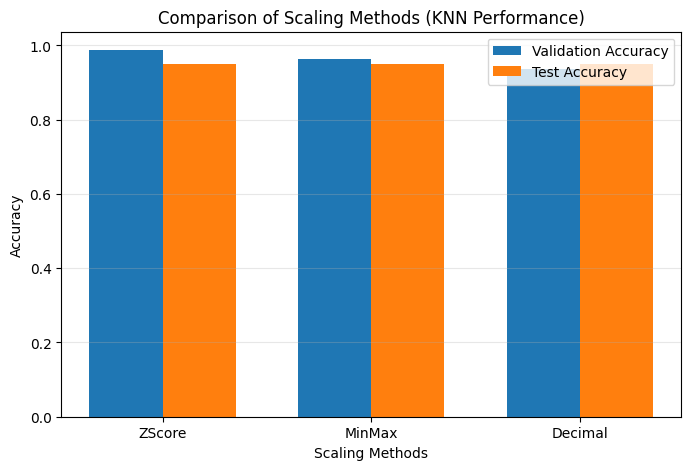

Scaling Analysis Table:


,Scaling_Method,Best_k,Validation_Accuracy,Test_Accuracy,Val_Test_Gap
0,ZScore,11,0.9875,0.95,0.0375
1,MinMax,3,0.9625,0.95,0.0125
2,Decimal,3,0.9375,0.95,-0.0125


In [ ]:
# ============================================================
# BOX 39 — Scaling Methods Visualization
#
# Purpose:
#   - Visually compare scaling methods
#   - Show validation and test performance side by side
#   - Support analytical decision-making
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Step 1 — Extract values
# ------------------------------------------------------------
methods = scaling_comparison_df["Scaling_Method"]
val_scores = scaling_comparison_df["Validation_Accuracy"]
test_scores = scaling_comparison_df["Test_Accuracy"]

x = np.arange(len(methods))
width = 0.35

# ------------------------------------------------------------
# Step 2 — Create grouped bar plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.bar(x - width / 2, val_scores, width, label="Validation Accuracy")
plt.bar(x + width / 2, test_scores, width, label="Test Accuracy")

# ------------------------------------------------------------
# Step 3 — Format plot
# ------------------------------------------------------------
plt.xticks(x, methods)
plt.xlabel("Scaling Methods")
plt.ylabel("Accuracy")
plt.title("Comparison of Scaling Methods (KNN Performance)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

# ------------------------------------------------------------
# Step 4 — Display plot
# ------------------------------------------------------------
plt.show()

# ------------------------------------------------------------
# Step 5 — Create compact gap analysis table
# ------------------------------------------------------------
scaling_analysis_df = scaling_comparison_df.copy()
scaling_analysis_df["Val_Test_Gap"] = (
    scaling_analysis_df["Validation_Accuracy"] - scaling_analysis_df["Test_Accuracy"]
).round(4)

print("Scaling Analysis Table:")
display(scaling_analysis_df)

In [ ]:
# ============================================================
# BOX 40 — Sensitivity Analysis Across k for Each Scaling Method
#
# Purpose:
#   - Evaluate the stability of each scaling method across
#     different KNN neighbor values
#   - Support a data-driven choice of scaling method
#
# Model:
#   - KNN classifier
#
# Evaluation:
#   - Validation Accuracy
#   - Test Accuracy
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# ------------------------------------------------------------
# Step 1 — Define candidate k values
# ------------------------------------------------------------
candidate_k_values = [3, 5, 7, 9, 11, 13, 15]

# ------------------------------------------------------------
# Step 2 — Define scaling datasets
# ------------------------------------------------------------
scaling_datasets = {
    "Decimal": (X_train_decimal, X_val_decimal, X_test_decimal),
    "MinMax":  (X_train_minmax, X_val_minmax, X_test_minmax),
    "ZScore":  (X_train_zscore, X_val_zscore, X_test_zscore)
}

# ------------------------------------------------------------
# Step 3 — Evaluate all (Scaling, k) combinations
# ------------------------------------------------------------
scaling_sensitivity_results = []

for scaling_name, (X_tr, X_v, X_te) in scaling_datasets.items():

    for k in candidate_k_values:

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_tr, y_train)

        y_val_pred = model.predict(X_v)
        y_test_pred = model.predict(X_te)

        val_acc = accuracy_score(y_val, y_val_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        scaling_sensitivity_results.append({
            "Scaling_Method": scaling_name,
            "k": k,
            "Validation_Accuracy": round(val_acc, 4),
            "Test_Accuracy": round(test_acc, 4)
        })

# ------------------------------------------------------------
# Step 4 — Create sensitivity table
# ------------------------------------------------------------
scaling_sensitivity_df = pd.DataFrame(scaling_sensitivity_results)

# ------------------------------------------------------------
# Step 5 — Sort results for readability
# ------------------------------------------------------------
scaling_sensitivity_df = scaling_sensitivity_df.sort_values(
    by=["Scaling_Method", "k"],
    ascending=[True, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 6 — Display results
# ------------------------------------------------------------
print("===================================================")
print("Scaling Sensitivity Analysis Across k")
print("===================================================")

display(scaling_sensitivity_df)

Scaling Sensitivity Analysis Across k


,Scaling_Method,k,Validation_Accuracy,Test_Accuracy
0,Decimal,3,0.9375,0.9500
1,Decimal,5,0.9250,0.9375
2,Decimal,7,0.9250,0.9375
3,Decimal,9,0.9125,0.9375
4,Decimal,11,0.9125,0.9375
5,Decimal,13,0.9125,0.9375
6,Decimal,15,0.9000,0.9375
7,MinMax,3,0.9625,0.9500
8,MinMax,5,0.9625,0.9375
9,MinMax,7,0.9625,0.9375


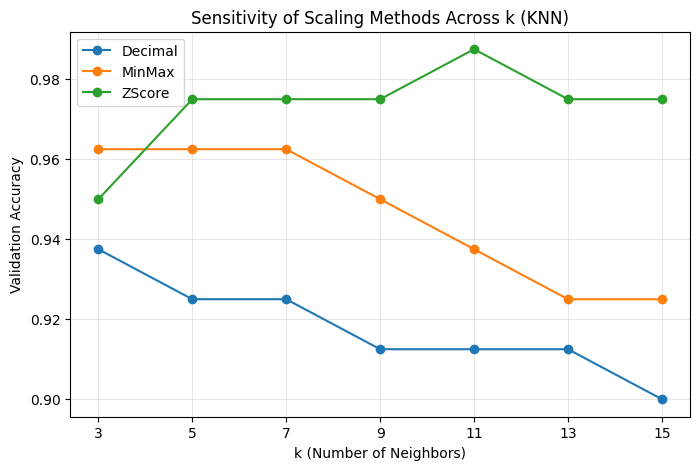

In [ ]:
# ============================================================
# BOX 41 — Sensitivity Visualization Across k
#
# Purpose:
#   - Visualize how each scaling method performs across k values
#   - Identify stability and robustness of each method
#   - Support final decision with visual evidence
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 1 — Prepare plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

# ------------------------------------------------------------
# Step 2 — Plot validation accuracy for each scaling method
# ------------------------------------------------------------
for scaling_name in scaling_sensitivity_df["Scaling_Method"].unique():

    subset = scaling_sensitivity_df[
        scaling_sensitivity_df["Scaling_Method"] == scaling_name
    ].sort_values(by="k")

    plt.plot(
        subset["k"],
        subset["Validation_Accuracy"],
        marker="o",
        label=scaling_name
    )

# ------------------------------------------------------------
# Step 3 — Format plot
# ------------------------------------------------------------
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Validation Accuracy")
plt.title("Sensitivity of Scaling Methods Across k (KNN)")
plt.xticks(sorted(scaling_sensitivity_df["k"].unique()))
plt.legend()
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Step 4 — Display plot
# ------------------------------------------------------------
plt.show()

In [ ]:
# ============================================================
# BOX 42 — Final Analytical Summary for Scaling Selection
#
# Purpose:
#   - Provide a data-driven summary of scaling methods
#   - Evaluate performance, stability, and generalization
#   - Support final decision BEFORE feature selection
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Step 1 — Aggregate statistics across k values
# ------------------------------------------------------------
summary_list = []

for scaling_name in scaling_sensitivity_df["Scaling_Method"].unique():

    subset = scaling_sensitivity_df[
        scaling_sensitivity_df["Scaling_Method"] == scaling_name
    ].copy()

    # Sort by validation accuracy first, then by smaller k as tie-break
    subset = subset.sort_values(
        by=["Validation_Accuracy", "k"],
        ascending=[False, True]
    ).reset_index(drop=True)

    # Best point based on validation accuracy
    best_row = subset.iloc[0]
    best_k = int(best_row["k"])
    best_val = float(best_row["Validation_Accuracy"])
    best_test = float(best_row["Test_Accuracy"])

    # Stability metrics across all tested k values
    mean_val = subset["Validation_Accuracy"].mean()
    std_val = subset["Validation_Accuracy"].std()

    # Generalization gap at the selected best point
    gap = best_val - best_test

    summary_list.append({
        "Scaling_Method": scaling_name,
        "Best_k": best_k,
        "Best_Validation": round(best_val, 4),
        "Best_Test": round(best_test, 4),
        "Mean_Validation": round(mean_val, 4),
        "Std_Validation": round(std_val, 4),
        "Val_Test_Gap": round(gap, 4)
    })

# ------------------------------------------------------------
# Step 2 — Create summary DataFrame
# ------------------------------------------------------------
scaling_summary_df = pd.DataFrame(summary_list)

# ------------------------------------------------------------
# Step 3 — Sort by validation performance and stability
# ------------------------------------------------------------
scaling_summary_df = scaling_summary_df.sort_values(
    by=["Best_Validation", "Mean_Validation", "Best_k"],
    ascending=[False, False, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 4 — Display summary table
# ------------------------------------------------------------
print("===================================================")
print("Final Analytical Summary of Scaling Methods")
print("===================================================")

display(scaling_summary_df)

Final Analytical Summary of Scaling Methods


,Scaling_Method,Best_k,Best_Validation,Best_Test,Mean_Validation,Std_Validation,Val_Test_Gap
0,ZScore,11,0.9875,0.95,0.9732,0.0112,0.0375
1,MinMax,3,0.9625,0.95,0.9464,0.0173,0.0125
2,Decimal,3,0.9375,0.95,0.9179,0.0122,-0.0125


In [ ]:
# ============================================================
# BOX 43 — Preconditions and Z-score Data Check
#
# Purpose:
#   - Ensure all required datasets and variables are available
#   - Validate shapes and consistency of splits
#   - Check class distribution across splits
#   - Confirm feature alignment across train/val/test
#   - Verify Z-score properties on scaled continuous features only
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 0 — Required objects
# ------------------------------------------------------------
required_objects = [
    "X_train_zscore", "X_val_zscore", "X_test_zscore",
    "y_train", "y_val", "y_test"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

print("All required objects are available.\n")

# ------------------------------------------------------------
# Step 1 — Type checks
# ------------------------------------------------------------
if not isinstance(X_train_zscore, pd.DataFrame):
    raise TypeError("X_train_zscore must be a pandas DataFrame.")
if not isinstance(X_val_zscore, pd.DataFrame):
    raise TypeError("X_val_zscore must be a pandas DataFrame.")
if not isinstance(X_test_zscore, pd.DataFrame):
    raise TypeError("X_test_zscore must be a pandas DataFrame.")

if not isinstance(y_train, pd.Series):
    raise TypeError("y_train must be a pandas Series.")
if not isinstance(y_val, pd.Series):
    raise TypeError("y_val must be a pandas Series.")
if not isinstance(y_test, pd.Series):
    raise TypeError("y_test must be a pandas Series.")

# ------------------------------------------------------------
# Step 2 — Shape checks
# ------------------------------------------------------------
print("Shape Check:")
print(f"X_train: {X_train_zscore.shape}")
print(f"X_val  : {X_val_zscore.shape}")
print(f"X_test : {X_test_zscore.shape}")

print(f"y_train: {y_train.shape}")
print(f"y_val  : {y_val.shape}")
print(f"y_test : {y_test.shape}\n")

if X_train_zscore.shape[0] != y_train.shape[0]:
    raise ValueError("Row count mismatch between X_train_zscore and y_train.")
if X_val_zscore.shape[0] != y_val.shape[0]:
    raise ValueError("Row count mismatch between X_val_zscore and y_val.")
if X_test_zscore.shape[0] != y_test.shape[0]:
    raise ValueError("Row count mismatch between X_test_zscore and y_test.")

# ------------------------------------------------------------
# Step 3 — Feature consistency check
# ------------------------------------------------------------
if not X_train_zscore.columns.equals(X_val_zscore.columns):
    raise ValueError("Column order or names mismatch between X_train_zscore and X_val_zscore.")

if not X_train_zscore.columns.equals(X_test_zscore.columns):
    raise ValueError("Column order or names mismatch between X_train_zscore and X_test_zscore.")

print(f"Feature consistency check passed. Total features: {X_train_zscore.shape[1]}\n")

# ------------------------------------------------------------
# Step 4 — Index alignment check
# ------------------------------------------------------------
if not X_train_zscore.index.equals(y_train.index):
    raise ValueError("Index mismatch between X_train_zscore and y_train.")
if not X_val_zscore.index.equals(y_val.index):
    raise ValueError("Index mismatch between X_val_zscore and y_val.")
if not X_test_zscore.index.equals(y_test.index):
    raise ValueError("Index mismatch between X_test_zscore and y_test.")

print("Index alignment check passed.\n")

# ------------------------------------------------------------
# Step 5 — Class distribution check
# ------------------------------------------------------------
def class_distribution(y, name):
    dist = y.value_counts(dropna=False).sort_index()
    total = len(y)

    print(f"{name} distribution:")
    for cls, count in dist.items():
        print(f"  Class {cls}: {count} ({count / total:.4f})")
    print()

class_distribution(y_train, "Train")
class_distribution(y_val, "Validation")
class_distribution(y_test, "Test")

# ------------------------------------------------------------
# Step 6 — Missing-value check after preprocessing
# ------------------------------------------------------------
missing_train = int(X_train_zscore.isna().sum().sum())
missing_val   = int(X_val_zscore.isna().sum().sum())
missing_test  = int(X_test_zscore.isna().sum().sum())

print("Missing-value check:")
print(f"  Train missing values: {missing_train}")
print(f"  Val   missing values: {missing_val}")
print(f"  Test  missing values: {missing_test}\n")

if missing_train > 0 or missing_val > 0 or missing_test > 0:
    raise ValueError("Missing values are still present after imputation/scaling.")

# ------------------------------------------------------------
# Step 7 — Z-score sanity check on scaled continuous features only
# ------------------------------------------------------------
scaled_continuous_cols = [
    "age", "bp",
    "bgr", "bu", "sc", "sod", "pot",
    "hemo", "pcv", "wc", "rc"
]

scaled_continuous_cols = [
    col for col in scaled_continuous_cols if col in X_train_zscore.columns
]

if not scaled_continuous_cols:
    raise ValueError("No scaled continuous columns were found for Z-score sanity check.")

print("Z-score sanity check on scaled continuous features only:")

train_means = X_train_zscore[scaled_continuous_cols].mean()
train_stds  = X_train_zscore[scaled_continuous_cols].std(ddof=0)

mean_abs_avg = float(train_means.abs().mean())
std_avg      = float(train_stds.mean())
max_abs_mean = float(train_means.abs().max())
min_std      = float(train_stds.min())
max_std      = float(train_stds.max())

print(f"Average |mean| across scaled features: {mean_abs_avg:.6f}")
print(f"Average std across scaled features   : {std_avg:.6f}")
print(f"Max |mean| across scaled features    : {max_abs_mean:.6f}")
print(f"Min std across scaled features       : {min_std:.6f}")
print(f"Max std across scaled features       : {max_std:.6f}\n")

# Safer numerical tolerances
mean_tol = 1e-6
std_tol  = 1e-6

if not np.allclose(train_means.values, 0.0, atol=mean_tol):
    raise ValueError(
        "Z-score sanity check failed: training means are not close to 0."
    )

if not np.allclose(train_stds.values, 1.0, atol=std_tol):
    raise ValueError(
        "Z-score sanity check failed: training stds are not close to 1."
    )

# ------------------------------------------------------------
# Step 8 — Data type check
# ------------------------------------------------------------
non_numeric_train = X_train_zscore.select_dtypes(exclude=[np.number]).columns.tolist()
non_numeric_val   = X_val_zscore.select_dtypes(exclude=[np.number]).columns.tolist()
non_numeric_test  = X_test_zscore.select_dtypes(exclude=[np.number]).columns.tolist()

non_numeric_cols = sorted(set(non_numeric_train + non_numeric_val + non_numeric_test))

print("Data type check:")
if non_numeric_cols:
    print("Non-numeric columns detected:")
    print(non_numeric_cols)
    raise TypeError("All model input features must be numeric before feature selection/modeling.")
else:
    print("All feature columns are numeric.\n")

All required objects are available.

Shape Check:
X_train: (240, 24)
X_val  : (80, 24)
X_test : (80, 24)
y_train: (240,)
y_val  : (80,)
y_test : (80,)

Feature consistency check passed. Total features: 24

Index alignment check passed.

Train distribution:
  Class 0: 90 (0.3750)
  Class 1: 150 (0.6250)

Validation distribution:
  Class 0: 30 (0.3750)
  Class 1: 50 (0.6250)

Test distribution:
  Class 0: 30 (0.3750)
  Class 1: 50 (0.6250)

Missing-value check:
  Train missing values: 0
  Val   missing values: 0
  Test  missing values: 0

Z-score sanity check on scaled continuous features only:
Average |mean| across scaled features: 0.000000
Average std across scaled features   : 1.000000
Max |mean| across scaled features    : 0.000000
Min std across scaled features       : 1.000000
Max std across scaled features       : 1.000000

Data type check:
All feature columns are numeric.



In [ ]:
# ============================================================
# BOX 44 — KNN Evaluation Utility Function
#
# Purpose:
#   - Provide reusable evaluation utilities for KNN
#   - Train on training data only
#   - Evaluate on validation and test data
#   - Support arbitrary feature subsets
# ============================================================

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Step 0 — Core evaluation function
# ------------------------------------------------------------
def evaluate_knn(feature_subset, k,
                 X_train, y_train,
                 X_val, y_val,
                 X_test, y_test):
    """
    Evaluate a KNN classifier on a given feature subset.

    Parameters
    ----------
    feature_subset : sequence
        Non-empty sequence of feature names to use.
    k : int
        Number of neighbors.
    X_train, X_val, X_test : pandas.DataFrame
        Feature matrices.
    y_train, y_val, y_test : pandas.Series
        Target vectors.

    Returns
    -------
    val_acc : float
        Validation accuracy.
    test_acc : float
        Test accuracy.
    """

    # --------------------------------------------------------
    # Basic input validation
    # --------------------------------------------------------
    if not isinstance(feature_subset, (list, tuple, pd.Index)) or len(feature_subset) == 0:
        raise ValueError("feature_subset must be a non-empty sequence of feature names.")

    feature_subset = list(feature_subset)

    if len(set(feature_subset)) != len(feature_subset):
        raise ValueError("feature_subset must not contain duplicate feature names.")

    if not isinstance(k, int) or k <= 0:
        raise ValueError("k must be a positive integer.")

    if k > len(y_train):
        raise ValueError("k cannot be larger than the number of training samples.")

    # --------------------------------------------------------
    # Validate row counts
    # --------------------------------------------------------
    if len(X_train) != len(y_train):
        raise ValueError("X_train and y_train must have the same number of rows.")
    if len(X_val) != len(y_val):
        raise ValueError("X_val and y_val must have the same number of rows.")
    if len(X_test) != len(y_test):
        raise ValueError("X_test and y_test must have the same number of rows.")

    # --------------------------------------------------------
    # Validate index alignment
    # --------------------------------------------------------
    if not X_train.index.equals(y_train.index):
        raise ValueError("Index mismatch between X_train and y_train.")
    if not X_val.index.equals(y_val.index):
        raise ValueError("Index mismatch between X_val and y_val.")
    if not X_test.index.equals(y_test.index):
        raise ValueError("Index mismatch between X_test and y_test.")

    # --------------------------------------------------------
    # Ensure all requested features exist in all splits
    # --------------------------------------------------------
    missing_train = [col for col in feature_subset if col not in X_train.columns]
    missing_val   = [col for col in feature_subset if col not in X_val.columns]
    missing_test  = [col for col in feature_subset if col not in X_test.columns]

    if missing_train:
        raise ValueError(f"Missing features in X_train: {missing_train}")
    if missing_val:
        raise ValueError(f"Missing features in X_val: {missing_val}")
    if missing_test:
        raise ValueError(f"Missing features in X_test: {missing_test}")

    # --------------------------------------------------------
    # Model initialization
    # --------------------------------------------------------
    model = KNeighborsClassifier(n_neighbors=k)

    # --------------------------------------------------------
    # Train model (ONLY on training data)
    # --------------------------------------------------------
    model.fit(X_train[feature_subset], y_train)

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------
    y_val_pred  = model.predict(X_val[feature_subset])
    y_test_pred = model.predict(X_test[feature_subset])

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------
    val_acc  = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    return val_acc, test_acc


# ------------------------------------------------------------
# Step 1 — Helper function for full feature set
# ------------------------------------------------------------
def evaluate_knn_full(k,
                     X_train, y_train,
                     X_val, y_val,
                     X_test, y_test):
    """
    Evaluate KNN using all available features.
    """
    feature_subset = list(X_train.columns)

    return evaluate_knn(
        feature_subset=feature_subset,
        k=k,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test
    )


# ------------------------------------------------------------
# Step 2 — Sanity check
# ------------------------------------------------------------
test_k = 5

val_acc, test_acc = evaluate_knn_full(
    k=test_k,
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    X_test=X_test_zscore,
    y_test=y_test
)

print("Sanity check (k=5):")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy      : {test_acc:.4f}")

Sanity check (k=5):
Validation Accuracy: 0.9750
Test Accuracy      : 0.9375


In [ ]:
# ============================================================
# BOX 45 — KNN Sensitivity Analysis (k vs Validation Accuracy)
#
# Purpose:
#   - Evaluate KNN performance across different k values
#   - Use all features as the baseline configuration
#   - Compute validation accuracy for model selection
#   - Keep test accuracy for reporting only
#   - Store results in structured tables
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "evaluate_knn_full",
    "X_train_zscore", "X_val_zscore", "X_test_zscore",
    "y_train", "y_val", "y_test"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

# ------------------------------------------------------------
# Step 1 — Define candidate k values
#   - Odd k values to reduce tie risk
#   - Must be <= number of training samples
# ------------------------------------------------------------
k_values = [k for k in range(1, 21, 2) if k <= len(y_train)]

if not k_values:
    raise ValueError("No valid k values were generated for the current training set size.")

# ------------------------------------------------------------
# Step 2 — Run sensitivity analysis
# ------------------------------------------------------------
results = []

for k in k_values:
    val_acc, test_acc = evaluate_knn_full(
        k=k,
        X_train=X_train_zscore,
        y_train=y_train,
        X_val=X_val_zscore,
        y_val=y_val,
        X_test=X_test_zscore,
        y_test=y_test
    )

    results.append({
        "k": int(k),
        "Validation_Accuracy": float(val_acc),
        "Test_Accuracy": float(test_acc),
        "Val_Test_Gap": float(val_acc - test_acc)
    })

# ------------------------------------------------------------
# Step 3 — Create results table
# ------------------------------------------------------------
knn_sensitivity_df = pd.DataFrame(results)

# ------------------------------------------------------------
# Step 4 — Sort for model selection
#   - Primary: Validation Accuracy (DESC)
#   - Secondary: smaller k (simpler model)
# ------------------------------------------------------------
knn_sensitivity_sorted = knn_sensitivity_df.sort_values(
    by=["Validation_Accuracy", "k"],
    ascending=[False, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 5 — Display results
# ------------------------------------------------------------
print("KNN Sensitivity Analysis (All Features)")
display(knn_sensitivity_df)

print("\nTop configurations (sorted for validation-based selection):")
display(knn_sensitivity_sorted.head(5))

# ------------------------------------------------------------
# Step 6 — Select best k (VALIDATION ONLY)
# ------------------------------------------------------------
best_k = int(knn_sensitivity_sorted.loc[0, "k"])
best_val_acc = float(knn_sensitivity_sorted.loc[0, "Validation_Accuracy"])

# Retrieve corresponding test accuracy (for reporting only)
best_test_acc = float(
    knn_sensitivity_df.loc[knn_sensitivity_df["k"] == best_k, "Test_Accuracy"].iloc[0]
)

print(f"\nBest k based on validation accuracy only: {best_k}")
print(f"Validation Accuracy at best k           : {best_val_acc:.4f}")
print(f"Test Accuracy at best k                 : {best_test_acc:.4f}")

KNN Sensitivity Analysis (All Features)


,k,Validation_Accuracy,Test_Accuracy,Val_Test_Gap
0,1,0.9250,0.9625,-0.0375
1,3,0.9500,0.9375,0.0125
2,5,0.9750,0.9375,0.0375
3,7,0.9750,0.9500,0.0250
4,9,0.9750,0.9500,0.0250
5,11,0.9875,0.9500,0.0375
6,13,0.9750,0.9500,0.0250
7,15,0.9750,0.9500,0.0250
8,17,0.9750,0.9500,0.0250
9,19,0.9750,0.9375,0.0375



Top configurations (sorted for validation-based selection):


,k,Validation_Accuracy,Test_Accuracy,Val_Test_Gap
0,11,0.9875,0.9500,0.0375
1,5,0.9750,0.9375,0.0375
2,7,0.9750,0.9500,0.0250
3,9,0.9750,0.9500,0.0250
4,13,0.9750,0.9500,0.0250



Best k based on validation accuracy only: 11
Validation Accuracy at best k           : 0.9875
Test Accuracy at best k                 : 0.9500


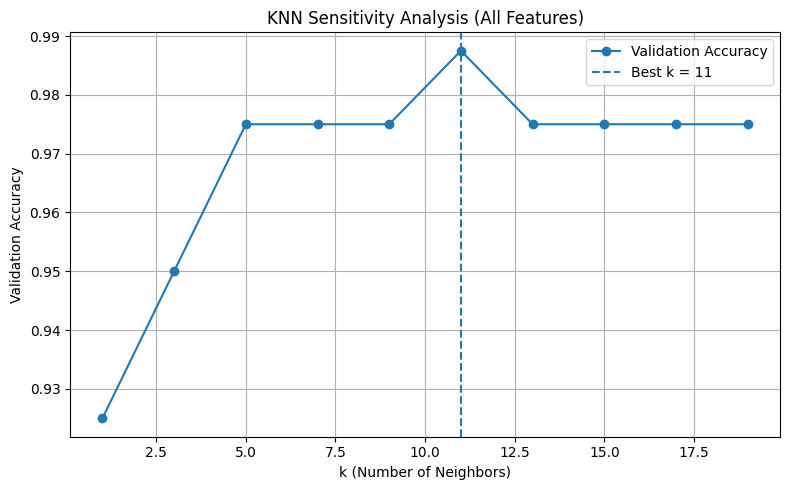

Best k selection (based on Validation Accuracy only):
k = 11
Validation Accuracy = 0.9875
Test Accuracy       = 0.9500
Gap (Val-Test)      = 0.0375


In [ ]:
# ============================================================
# BOX 46 — KNN Sensitivity Plots and Best k Decision
#
# Purpose:
#   - Visualize KNN sensitivity analysis results
#   - Plot validation accuracy versus k
#   - Report the best k selected from validation performance
#   - Keep test accuracy only for final reporting
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = ["knn_sensitivity_df", "best_k"]
missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

required_columns = ["k", "Validation_Accuracy", "Test_Accuracy", "Val_Test_Gap"]
missing_columns = [col for col in required_columns if col not in knn_sensitivity_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in knn_sensitivity_df: {missing_columns}")

if knn_sensitivity_df.empty:
    raise ValueError("knn_sensitivity_df is empty.")

# Ensure correct type
best_k = int(best_k)

# ------------------------------------------------------------
# Step 1 — Prepare plotting table
# ------------------------------------------------------------
df_plot = knn_sensitivity_df.sort_values(by="k").reset_index(drop=True)

# Ensure best_k exists in dataframe
if best_k not in df_plot["k"].values:
    raise ValueError(f"best_k={best_k} not found in knn_sensitivity_df.")

# ------------------------------------------------------------
# Step 2 — Plot validation accuracy versus k
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    df_plot["k"],
    df_plot["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=best_k,
    linestyle="--",
    label=f"Best k = {best_k}"
)

plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Validation Accuracy")
plt.title("KNN Sensitivity Analysis (All Features)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 3 — Report best k
# ------------------------------------------------------------
best_row = df_plot.loc[df_plot["k"] == best_k].iloc[0]

print("Best k selection (based on Validation Accuracy only):")
print(f"k = {best_k}")
print(f"Validation Accuracy = {best_row['Validation_Accuracy']:.4f}")
print(f"Test Accuracy       = {best_row['Test_Accuracy']:.4f}")
print(f"Gap (Val-Test)      = {best_row['Val_Test_Gap']:.4f}")

In [ ]:
# ============================================================
# BOX 47 — Feature Ranking for Filter Method
#
# Purpose:
#   - Rank features based on their relevance to the target
#   - Use only training data to avoid leakage
#   - Use absolute Pearson correlation (point-biserial for binary y)
#   - Handle constant features and non-numeric columns safely
#   - Use vectorized computation for efficiency and stability
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = ["X_train_zscore", "y_train"]
missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not isinstance(X_train_zscore, pd.DataFrame):
    raise TypeError("X_train_zscore must be a pandas DataFrame.")
if not isinstance(y_train, pd.Series):
    raise TypeError("y_train must be a pandas Series.")

if len(X_train_zscore) != len(y_train):
    raise ValueError("X_train_zscore and y_train must have the same number of rows.")

if not X_train_zscore.index.equals(y_train.index):
    raise ValueError("Index mismatch between X_train_zscore and y_train.")

if X_train_zscore.empty:
    raise ValueError("X_train_zscore is empty.")

# ------------------------------------------------------------
# Step 1 — Keep only numeric features
# ------------------------------------------------------------
X_numeric = X_train_zscore.select_dtypes(include=[np.number])

if X_numeric.shape[1] == 0:
    raise ValueError("No numeric features available for correlation analysis.")

# ------------------------------------------------------------
# Step 2 — Remove constant (zero-variance) features
# ------------------------------------------------------------
stds = X_numeric.std(ddof=0)
non_constant_cols = stds[stds > 0].index.tolist()

if len(non_constant_cols) == 0:
    raise ValueError("All features have zero variance.")

X_numeric = X_numeric[non_constant_cols]

# ------------------------------------------------------------
# Step 3 — Compute Pearson correlation (vectorized)
# ------------------------------------------------------------
corr_series = X_numeric.corrwith(y_train)

# Replace NaN correlations (edge cases) with zero
corr_series = corr_series.fillna(0.0)

# ------------------------------------------------------------
# Step 4 — Build ranking table
# ------------------------------------------------------------
filter_ranking_df = pd.DataFrame({
    "Feature": corr_series.index,
    "Correlation": corr_series.values,
    "Abs_Correlation": np.abs(corr_series.values)
})

# ------------------------------------------------------------
# Step 5 — Sort with deterministic tie-breaking
# ------------------------------------------------------------
filter_ranking_df = filter_ranking_df.sort_values(
    by=["Abs_Correlation", "Feature"],
    ascending=[False, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 6 — Extract ranked feature list
# ------------------------------------------------------------
ranked_features = filter_ranking_df["Feature"].tolist()

# ------------------------------------------------------------
# Step 7 — Display results
# ------------------------------------------------------------
print("Feature Ranking (Filter Method — Pearson Correlation)")
display(filter_ranking_df)

print("\nTop 10 Features:")
display(filter_ranking_df.head(10))

Feature Ranking (Filter Method — Pearson Correlation)


,Feature,Correlation,Abs_Correlation
0,hemo,-0.735154,0.735154
1,sg,-0.641514,0.641514
2,pcv,-0.632094,0.632094
3,rc,-0.606578,0.606578
4,htn,0.600000,0.600000
5,al,0.521120,0.521120
6,dm,0.512128,0.512128
7,sod,-0.449920,0.449920
8,bu,0.381054,0.381054
9,pc,-0.367007,0.367007



Top 10 Features:


,Feature,Correlation,Abs_Correlation
0,hemo,-0.735154,0.735154
1,sg,-0.641514,0.641514
2,pcv,-0.632094,0.632094
3,rc,-0.606578,0.606578
4,htn,0.600000,0.600000
5,al,0.521120,0.521120
6,dm,0.512128,0.512128
7,sod,-0.449920,0.449920
8,bu,0.381054,0.381054
9,pc,-0.367007,0.367007


In [ ]:
# ============================================================
# BOX 48 — Filter Sensitivity Analysis (Top-m Features)
#
# Purpose:
#   - Evaluate KNN performance using top-m ranked features
#   - Perform sensitivity analysis for m = 1, 2, ..., p
#   - Use best_k selected from KNN sensitivity analysis
#   - Use validation accuracy only for feature-subset selection
#   - Keep test accuracy for reporting only
#   - Store the final selected filter-based feature subset
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "ranked_features",
    "best_k",
    "evaluate_knn",
    "X_train_zscore", "X_val_zscore", "X_test_zscore",
    "y_train", "y_val", "y_test"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not isinstance(ranked_features, list) or len(ranked_features) == 0:
    raise ValueError("ranked_features must be a non-empty list.")

if not all(isinstance(f, str) for f in ranked_features):
    raise TypeError("All entries in ranked_features must be strings.")

if len(set(ranked_features)) != len(ranked_features):
    raise ValueError("ranked_features must not contain duplicate feature names.")

if not isinstance(best_k, int) or best_k <= 0:
    raise ValueError("best_k must be a positive integer.")

# Ensure all ranked features exist in all data splits
missing_train = [f for f in ranked_features if f not in X_train_zscore.columns]
missing_val   = [f for f in ranked_features if f not in X_val_zscore.columns]
missing_test  = [f for f in ranked_features if f not in X_test_zscore.columns]

if missing_train:
    raise ValueError(f"Features missing from X_train_zscore: {missing_train}")
if missing_val:
    raise ValueError(f"Features missing from X_val_zscore: {missing_val}")
if missing_test:
    raise ValueError(f"Features missing from X_test_zscore: {missing_test}")

# ------------------------------------------------------------
# Step 1 — Run sensitivity analysis across top-m features
# ------------------------------------------------------------
results = []
total_features = len(ranked_features)

for m in range(1, total_features + 1):
    selected_features = ranked_features[:m]

    val_acc, test_acc = evaluate_knn(
        feature_subset=selected_features,
        k=best_k,
        X_train=X_train_zscore,
        y_train=y_train,
        X_val=X_val_zscore,
        y_val=y_val,
        X_test=X_test_zscore,
        y_test=y_test
    )

    results.append({
        "Num_Features": int(m),
        "Selected_Features": ", ".join(selected_features),
        "Validation_Accuracy": float(val_acc),
        "Test_Accuracy": float(test_acc),
        "Val_Test_Gap": float(val_acc - test_acc)
    })

# ------------------------------------------------------------
# Step 2 — Create results table
# ------------------------------------------------------------
filter_sensitivity_df = pd.DataFrame(results)

if filter_sensitivity_df.empty:
    raise ValueError("filter_sensitivity_df is empty.")

# ------------------------------------------------------------
# Step 3 — Create ranked table for validation-based selection
#   - Primary: Validation Accuracy (DESC)
#   - Secondary: smaller subset size (ASC)
# ------------------------------------------------------------
filter_sensitivity_sorted = filter_sensitivity_df.sort_values(
    by=["Validation_Accuracy", "Num_Features"],
    ascending=[False, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 4 — Display results
# ------------------------------------------------------------
print("Filter Sensitivity Analysis (Top-m Features)")
display(filter_sensitivity_df)

print("\nTop configurations (sorted for validation-based selection):")
display(filter_sensitivity_sorted.head(5))

# ------------------------------------------------------------
# Step 5 — Select best m using validation accuracy only
# ------------------------------------------------------------
best_m = int(filter_sensitivity_sorted.loc[0, "Num_Features"])
best_val_acc_filter = float(filter_sensitivity_sorted.loc[0, "Validation_Accuracy"])
best_test_acc_filter = float(
    filter_sensitivity_df.loc[
        filter_sensitivity_df["Num_Features"] == best_m, "Test_Accuracy"
    ].iloc[0]
)

# Final selected feature subset for the filter method
filter_selected_features = ranked_features[:best_m]

# ------------------------------------------------------------
# Step 6 — Report final selection
# ------------------------------------------------------------
print(f"\nBest number of features (m) based on validation only: {best_m}")
print(f"Validation Accuracy at best m                       : {best_val_acc_filter:.4f}")
print(f"Test Accuracy at best m                             : {best_test_acc_filter:.4f}")
print(f"Selected Features                                   : {filter_selected_features}")

Filter Sensitivity Analysis (Top-m Features)


,Num_Features,Selected_Features,Validation_Accuracy,Test_Accuracy,Val_Test_Gap
0,1,hemo,0.9625,0.9250,0.0375
1,2,"hemo, sg",0.9625,0.9250,0.0375
2,3,"hemo, sg, pcv",0.9875,0.9000,0.0875
3,4,"hemo, sg, pcv, rc",0.9875,0.8500,0.1375
4,5,"hemo, sg, pcv, rc, htn",0.9875,0.8875,0.1000
5,6,"hemo, sg, pcv, rc, htn, al",0.9875,0.9000,0.0875
6,7,"hemo, sg, pcv, rc, htn, al, dm",0.9875,0.9125,0.0750
7,8,"hemo, sg, pcv, rc, htn, al, dm, sod",0.9875,0.9250,0.0625
8,9,"hemo, sg, pcv, rc, htn, al, dm, sod, bu",0.9875,0.9375,0.0500
9,10,"hemo, sg, pcv, rc, htn, al, dm, sod, bu, pc",0.9875,0.9375,0.0500



Top configurations (sorted for validation-based selection):


,Num_Features,Selected_Features,Validation_Accuracy,Test_Accuracy,Val_Test_Gap
0,15,"hemo, sg, pcv, rc, htn, al, dm, sod, bu, pc, a...",1.0000,0.9625,0.0375
1,16,"hemo, sg, pcv, rc, htn, al, dm, sod, bu, pc, a...",1.0000,0.9625,0.0375
2,3,"hemo, sg, pcv",0.9875,0.9000,0.0875
3,4,"hemo, sg, pcv, rc",0.9875,0.8500,0.1375
4,5,"hemo, sg, pcv, rc, htn",0.9875,0.8875,0.1000



Best number of features (m) based on validation only: 15
Validation Accuracy at best m                       : 1.0000
Test Accuracy at best m                             : 0.9625
Selected Features                                   : ['hemo', 'sg', 'pcv', 'rc', 'htn', 'al', 'dm', 'sod', 'bu', 'pc', 'appet', 'bgr', 'pe', 'ane', 'sc']


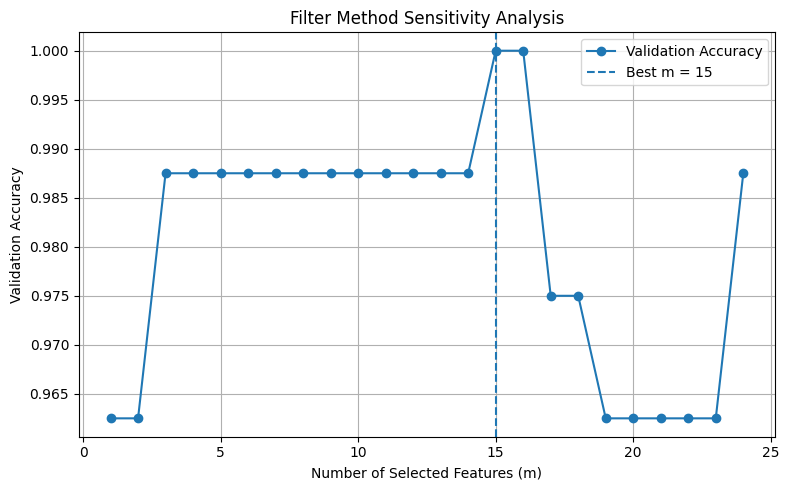

Final Filter Selection Summary:
Best number of features (m): 15
Validation Accuracy        : 1.0000
Test Accuracy              : 0.9625
Gap (Val-Test)             : 0.0375

Selected Features:
['hemo', 'sg', 'pcv', 'rc', 'htn', 'al', 'dm', 'sod', 'bu', 'pc', 'appet', 'bgr', 'pe', 'ane', 'sc']


In [ ]:
# ============================================================
# BOX 49 — Filter Plots, Best m Selection, and Final Subset
#
# Purpose:
#   - Visualize Filter sensitivity analysis results
#   - Plot validation accuracy versus number of selected features
#   - Define the final Filter subset using the best m
#   - Report final metrics for the selected subset
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "filter_sensitivity_df",
    "best_m",
    "ranked_features"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

required_columns = [
    "Num_Features",
    "Validation_Accuracy",
    "Test_Accuracy",
    "Val_Test_Gap"
]
missing_columns = [col for col in required_columns if col not in filter_sensitivity_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in filter_sensitivity_df: {missing_columns}")

if filter_sensitivity_df.empty:
    raise ValueError("filter_sensitivity_df is empty.")

if not isinstance(best_m, int) or best_m <= 0:
    raise ValueError("best_m must be a positive integer.")

if not isinstance(ranked_features, list) or len(ranked_features) == 0:
    raise ValueError("ranked_features must be a non-empty list.")

if not all(isinstance(f, str) for f in ranked_features):
    raise TypeError("All entries in ranked_features must be strings.")

if len(set(ranked_features)) != len(ranked_features):
    raise ValueError("ranked_features must not contain duplicate feature names.")

if best_m > len(ranked_features):
    raise ValueError("best_m cannot be larger than the number of ranked features.")

# ------------------------------------------------------------
# Step 1 — Prepare plotting table
# ------------------------------------------------------------
df_plot = filter_sensitivity_df.sort_values(by="Num_Features").reset_index(drop=True)

if best_m not in df_plot["Num_Features"].values:
    raise ValueError(f"best_m={best_m} not found in filter_sensitivity_df.")

# ------------------------------------------------------------
# Step 2 — Plot validation accuracy versus m
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    df_plot["Num_Features"],
    df_plot["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=best_m,
    linestyle="--",
    label=f"Best m = {best_m}"
)

plt.xlabel("Number of Selected Features (m)")
plt.ylabel("Validation Accuracy")
plt.title("Filter Method Sensitivity Analysis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 3 — Define final Filter subset
# ------------------------------------------------------------
filter_selected_features = ranked_features[:best_m]

# ------------------------------------------------------------
# Step 4 — Extract the selected row
# ------------------------------------------------------------
best_row = df_plot.loc[df_plot["Num_Features"] == best_m].iloc[0]

# ------------------------------------------------------------
# Step 5 — Store final summary values
# ------------------------------------------------------------
filter_val_acc = float(best_row["Validation_Accuracy"])
filter_test_acc = float(best_row["Test_Accuracy"])
filter_val_test_gap = float(best_row["Val_Test_Gap"])

# ------------------------------------------------------------
# Step 6 — Display summary
# ------------------------------------------------------------
print("Final Filter Selection Summary:")
print(f"Best number of features (m): {best_m}")
print(f"Validation Accuracy        : {filter_val_acc:.4f}")
print(f"Test Accuracy              : {filter_test_acc:.4f}")
print(f"Gap (Val-Test)             : {filter_val_test_gap:.4f}")

print("\nSelected Features:")
print(filter_selected_features)

In [ ]:
# ============================================================
# BOX 50 — Forward Selection Function (Wrapper Method)
#
# Purpose:
#   - Implement forward feature selection
#   - Start from an empty feature set and add features iteratively
#   - At each step, add the feature that maximizes validation accuracy
#   - Stop when no further strict improvement is achieved
#   - Use deterministic tie-breaking by feature name
#
# Output:
#   - selected_features_forward
#   - forward_history_df
# ============================================================

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "best_k",
    "X_train_zscore", "X_val_zscore",
    "y_train", "y_val"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

# ------------------------------------------------------------
# Step 1 — Forward selection function
# ------------------------------------------------------------
def forward_selection(X_train, y_train,
                      X_val, y_val,
                      k):
    """
    Perform forward feature selection using validation accuracy only.

    Parameters
    ----------
    X_train, X_val : pandas.DataFrame
        Feature matrices.
    y_train, y_val : pandas.Series
        Target vectors.
    k : int
        Number of neighbors for KNN.

    Returns
    -------
    selected_features : list
        Final selected feature subset.
    history_df : pandas.DataFrame
        Step-by-step selection history.
    """

    # --------------------------------------------------------
    # Basic input checks
    # --------------------------------------------------------
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train must be a pandas DataFrame.")
    if not isinstance(X_val, pd.DataFrame):
        raise TypeError("X_val must be a pandas DataFrame.")
    if not isinstance(y_train, pd.Series):
        raise TypeError("y_train must be a pandas Series.")
    if not isinstance(y_val, pd.Series):
        raise TypeError("y_val must be a pandas Series.")

    if X_train.empty:
        raise ValueError("X_train must not be empty.")
    if X_val.empty:
        raise ValueError("X_val must not be empty.")

    if not X_train.columns.equals(X_val.columns):
        raise ValueError("X_train and X_val must have identical columns in the same order.")

    if len(X_train) != len(y_train):
        raise ValueError("X_train and y_train must have the same number of rows.")
    if len(X_val) != len(y_val):
        raise ValueError("X_val and y_val must have the same number of rows.")

    if not X_train.index.equals(y_train.index):
        raise ValueError("Index mismatch between X_train and y_train.")
    if not X_val.index.equals(y_val.index):
        raise ValueError("Index mismatch between X_val and y_val.")

    if not isinstance(k, int) or k <= 0:
        raise ValueError("k must be a positive integer.")
    if k > len(y_train):
        raise ValueError("k cannot be larger than the number of training samples.")

    # Ensure all feature columns are numeric
    non_numeric_train = X_train.select_dtypes(exclude=["number"]).columns.tolist()
    non_numeric_val = X_val.select_dtypes(exclude=["number"]).columns.tolist()
    non_numeric_cols = sorted(set(non_numeric_train + non_numeric_val))
    if non_numeric_cols:
        raise TypeError(f"All feature columns must be numeric. Non-numeric columns found: {non_numeric_cols}")

    all_features = list(X_train.columns)
    selected_features = []

    history = []
    best_global_val_acc = float("-inf")
    step = 0

    # --------------------------------------------------------
    # Iterative forward search
    # --------------------------------------------------------
    while True:
        step += 1
        best_feature = None
        best_val_acc_step = best_global_val_acc

        remaining_features = sorted([f for f in all_features if f not in selected_features])

        # ----------------------------------------------------
        # Try adding each remaining feature
        # ----------------------------------------------------
        for feature in remaining_features:
            candidate_features = selected_features + [feature]

            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(X_train[candidate_features], y_train)

            y_val_pred = model.predict(X_val[candidate_features])
            val_acc = accuracy_score(y_val, y_val_pred)

            # Strict improvement only
            # Tie-breaking is deterministic because remaining_features
            # is sorted alphabetically
            if val_acc > best_val_acc_step:
                best_val_acc_step = val_acc
                best_feature = feature

        # ----------------------------------------------------
        # Stop if no strict improvement is found
        # ----------------------------------------------------
        if best_feature is None:
            break

        # Update selected features
        selected_features.append(best_feature)
        best_global_val_acc = best_val_acc_step

        # Record history
        history.append({
            "Step": int(step),
            "Added_Feature": best_feature,
            "Num_Features": int(len(selected_features)),
            "Validation_Accuracy": float(best_val_acc_step)
        })

    # --------------------------------------------------------
    # Build history table
    # --------------------------------------------------------
    history_df = pd.DataFrame(
        history,
        columns=[
            "Step",
            "Added_Feature",
            "Num_Features",
            "Validation_Accuracy"
        ]
    )

    return selected_features, history_df


print("Forward selection function defined successfully.")

Forward selection function defined successfully.


In [ ]:
# ============================================================
# BOX 51 — Run Forward Selection
#
# Purpose:
#   - Execute forward feature selection using best_k
#   - Generate the final selected feature subset
#   - Store the full step-by-step history (validation only)
#   - Compute final validation and test accuracy
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "forward_selection",
    "best_k",
    "evaluate_knn",
    "X_train_zscore", "X_val_zscore", "X_test_zscore",
    "y_train", "y_val", "y_test"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not callable(forward_selection):
    raise TypeError("forward_selection must be a callable function.")

if not callable(evaluate_knn):
    raise TypeError("evaluate_knn must be a callable function.")

if not isinstance(best_k, int) or best_k <= 0:
    raise ValueError("best_k must be a positive integer.")

# ------------------------------------------------------------
# Step 1 — Run forward selection (validation only)
# ------------------------------------------------------------
selected_features_forward, forward_history_df = forward_selection(
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    k=best_k
)

# ------------------------------------------------------------
# Step 2 — Validate outputs
# ------------------------------------------------------------
if not isinstance(selected_features_forward, list):
    raise TypeError("selected_features_forward must be a list.")

if len(selected_features_forward) == 0:
    raise ValueError("Forward selection returned an empty feature subset.")

if not all(isinstance(f, str) for f in selected_features_forward):
    raise TypeError("All selected forward features must be strings.")

if len(set(selected_features_forward)) != len(selected_features_forward):
    raise ValueError("selected_features_forward must not contain duplicate feature names.")

if not isinstance(forward_history_df, pd.DataFrame):
    raise TypeError("forward_history_df must be a pandas DataFrame.")

if forward_history_df.empty:
    raise ValueError("forward_history_df is empty.")

required_columns = [
    "Step",
    "Added_Feature",
    "Num_Features",
    "Validation_Accuracy"
]
missing_columns = [col for col in required_columns if col not in forward_history_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in forward_history_df: {missing_columns}")

# Ensure selected features exist in all splits
missing_train = [f for f in selected_features_forward if f not in X_train_zscore.columns]
missing_val   = [f for f in selected_features_forward if f not in X_val_zscore.columns]
missing_test  = [f for f in selected_features_forward if f not in X_test_zscore.columns]

if missing_train:
    raise ValueError(f"Selected forward features missing from X_train_zscore: {missing_train}")
if missing_val:
    raise ValueError(f"Selected forward features missing from X_val_zscore: {missing_val}")
if missing_test:
    raise ValueError(f"Selected forward features missing from X_test_zscore: {missing_test}")

# ------------------------------------------------------------
# Step 3 — Final evaluation using selected features
# ------------------------------------------------------------
forward_val_acc, forward_test_acc = evaluate_knn(
    feature_subset=selected_features_forward,
    k=best_k,
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    X_test=X_test_zscore,
    y_test=y_test
)

forward_num_features = len(selected_features_forward)
forward_val_test_gap = float(forward_val_acc - forward_test_acc)

# ------------------------------------------------------------
# Step 4 — Summary outputs
# ------------------------------------------------------------
print("Forward Selection Results")
print(f"Number of selected features: {forward_num_features}")
print(f"Validation Accuracy        : {forward_val_acc:.4f}")
print(f"Test Accuracy              : {forward_test_acc:.4f}")
print(f"Gap (Val-Test)             : {forward_val_test_gap:.4f}")

print("\nSelected Features:")
print(selected_features_forward)

# ------------------------------------------------------------
# Step 5 — Display history
# ------------------------------------------------------------
print("\nForward Selection History:")
display(forward_history_df)

Forward Selection Results
Number of selected features: 3
Validation Accuracy        : 1.0000
Test Accuracy              : 0.9375
Gap (Val-Test)             : 0.0625

Selected Features:
['hemo', 'htn', 'sc']

Forward Selection History:


,Step,Added_Feature,Num_Features,Validation_Accuracy
0,1,hemo,1,0.9625
1,2,htn,2,0.9875
2,3,sc,3,1.0000


Forward Selection — Detailed Analysis Table:


,Step,Added_Feature,Num_Features,Validation_Accuracy,Delta_Val_Acc
0,1,hemo,1,0.9625,0.0000
1,2,htn,2,0.9875,0.0250
2,3,sc,3,1.0000,0.0125



Summary:
Total steps performed       : 3
Final number of features    : 3
Final validation accuracy   : 1.0000
Final test accuracy         : 0.9375
Final validation-test gap   : 0.0625


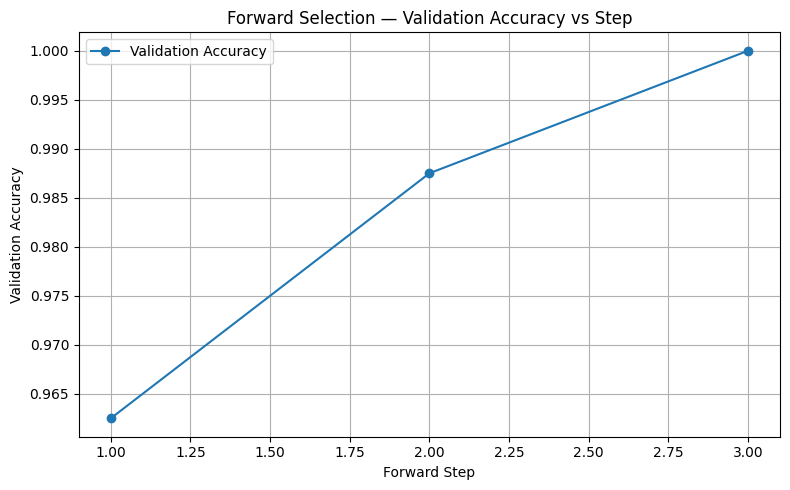

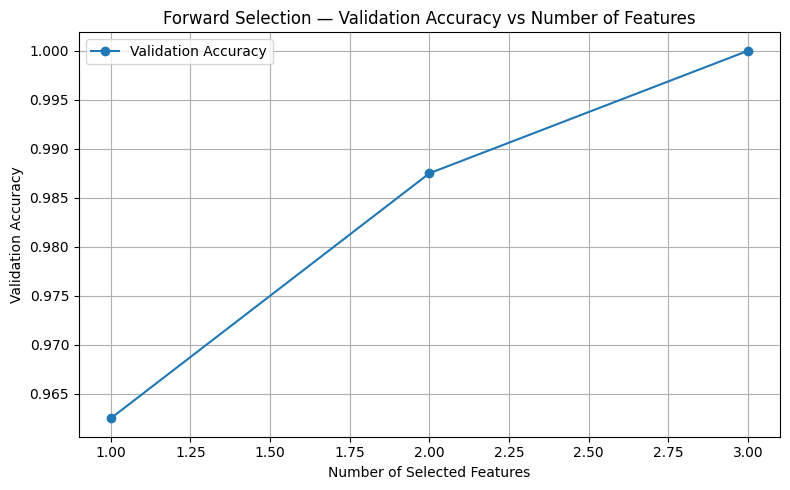

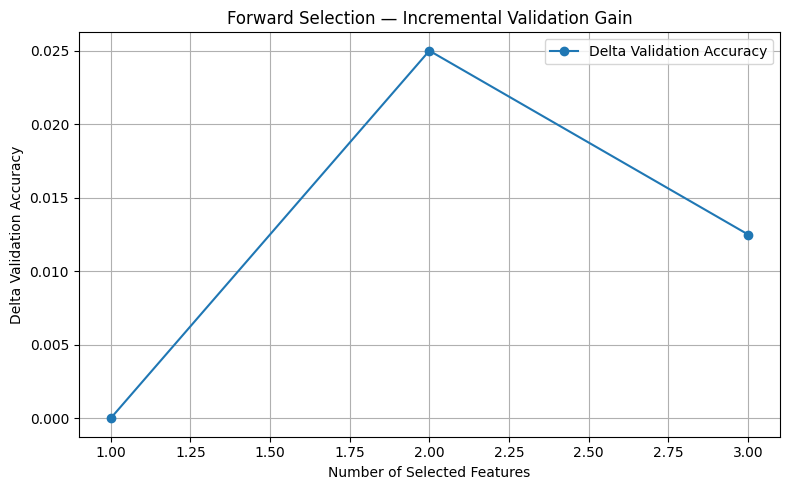


Best Step (by Validation Accuracy):
Step                : 3
Added Feature       : sc
Num Features        : 3
Validation Accuracy : 1.0000
Delta Val Accuracy  : 0.0125


In [ ]:
# ============================================================
# BOX 52 — Forward Selection Analysis (Tables + Plots)
#
# Purpose:
#   - Analyze forward selection step-by-step
#   - Visualize validation accuracy trends
#   - Quantify incremental validation improvement
#   - Provide analysis-ready tables for interpretation
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "forward_history_df",
    "selected_features_forward",
    "forward_val_acc",
    "forward_test_acc"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not isinstance(forward_history_df, pd.DataFrame):
    raise TypeError("forward_history_df must be a pandas DataFrame.")

if forward_history_df.empty:
    raise ValueError("forward_history_df is empty.")

if not isinstance(selected_features_forward, list) or len(selected_features_forward) == 0:
    raise ValueError("selected_features_forward must be a non-empty list.")

if not all(isinstance(f, str) for f in selected_features_forward):
    raise TypeError("All entries in selected_features_forward must be strings.")

if len(set(selected_features_forward)) != len(selected_features_forward):
    raise ValueError("selected_features_forward must not contain duplicate feature names.")

if not isinstance(forward_val_acc, (int, float, np.floating)):
    raise TypeError("forward_val_acc must be numeric.")

if not isinstance(forward_test_acc, (int, float, np.floating)):
    raise TypeError("forward_test_acc must be numeric.")

required_columns = [
    "Step",
    "Added_Feature",
    "Num_Features",
    "Validation_Accuracy"
]
missing_columns = [col for col in required_columns if col not in forward_history_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in forward_history_df: {missing_columns}")

# ------------------------------------------------------------
# Step 1 — Prepare analysis table
# ------------------------------------------------------------
forward_analysis_df = forward_history_df.copy()

# Ensure proper ordering by forward step
forward_analysis_df = forward_analysis_df.sort_values(by="Step").reset_index(drop=True)

# Basic consistency checks
if forward_analysis_df["Step"].duplicated().any():
    raise ValueError("Duplicate values found in 'Step' column of forward_history_df.")

if forward_analysis_df["Added_Feature"].duplicated().any():
    raise ValueError("Duplicate features found in 'Added_Feature' column of forward_history_df.")

if int(forward_analysis_df["Num_Features"].iloc[-1]) != len(selected_features_forward):
    raise ValueError(
        "Mismatch between the final Num_Features in forward_history_df "
        "and the length of selected_features_forward."
    )

# Compute incremental validation gain
forward_analysis_df["Delta_Val_Acc"] = (
    forward_analysis_df["Validation_Accuracy"].diff().fillna(0.0)
)

# ------------------------------------------------------------
# Step 2 — Display analysis table
# ------------------------------------------------------------
print("Forward Selection — Detailed Analysis Table:")
display(forward_analysis_df)

forward_val_test_gap = float(forward_val_acc - forward_test_acc)

print("\nSummary:")
print(f"Total steps performed       : {len(forward_analysis_df)}")
print(f"Final number of features    : {len(selected_features_forward)}")
print(f"Final validation accuracy   : {forward_val_acc:.4f}")
print(f"Final test accuracy         : {forward_test_acc:.4f}")
print(f"Final validation-test gap   : {forward_val_test_gap:.4f}")

# ------------------------------------------------------------
# Step 3 — Plot validation accuracy versus selection step
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    forward_analysis_df["Step"],
    forward_analysis_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Forward Step")
plt.ylabel("Validation Accuracy")
plt.title("Forward Selection — Validation Accuracy vs Step")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 4 — Plot validation accuracy versus number of selected features
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    forward_analysis_df["Num_Features"],
    forward_analysis_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Number of Selected Features")
plt.ylabel("Validation Accuracy")
plt.title("Forward Selection — Validation Accuracy vs Number of Features")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 5 — Plot incremental validation improvement
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    forward_analysis_df["Num_Features"],
    forward_analysis_df["Delta_Val_Acc"],
    marker="o",
    label="Delta Validation Accuracy"
)

plt.xlabel("Number of Selected Features")
plt.ylabel("Delta Validation Accuracy")
plt.title("Forward Selection — Incremental Validation Gain")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 6 — Report best step
#   - In forward selection with strict improvement stopping,
#     the final step is also the best step
# ------------------------------------------------------------
best_idx = forward_analysis_df["Validation_Accuracy"].idxmax()
best_row = forward_analysis_df.loc[best_idx]

print("\nBest Step (by Validation Accuracy):")
print(f"Step                : {int(best_row['Step'])}")
print(f"Added Feature       : {best_row['Added_Feature']}")
print(f"Num Features        : {int(best_row['Num_Features'])}")
print(f"Validation Accuracy : {best_row['Validation_Accuracy']:.4f}")
print(f"Delta Val Accuracy  : {best_row['Delta_Val_Acc']:.4f}")

In [ ]:
# ============================================================
# BOX 53 — Backward Selection Function (Wrapper Method)
#
# Purpose:
#   - Implement backward feature elimination
#   - Start from the full feature set and remove features iteratively
#   - At each step, remove the feature whose removal yields the
#     best validation accuracy
#   - Allow non-degrading removals (>=) to eliminate redundant features
#   - Stop when no removable feature preserves or improves validation accuracy
#   - Use deterministic tie-breaking by feature name
#
# Output:
#   - selected_features_backward
#   - backward_history_df
# ============================================================

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "best_k",
    "X_train_zscore", "X_val_zscore",
    "y_train", "y_val"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

# ------------------------------------------------------------
# Step 1 — Backward selection function
# ------------------------------------------------------------
def backward_selection(X_train, y_train,
                       X_val, y_val,
                       k):
    """
    Perform backward feature elimination using validation accuracy only.

    Parameters
    ----------
    X_train, X_val : pandas.DataFrame
        Feature matrices.
    y_train, y_val : pandas.Series
        Target vectors.
    k : int
        Number of neighbors for KNN.

    Returns
    -------
    selected_features : list
        Final selected feature subset.
    history_df : pandas.DataFrame
        Step-by-step elimination history.
    """

    # --------------------------------------------------------
    # Basic input checks
    # --------------------------------------------------------
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train must be a pandas DataFrame.")
    if not isinstance(X_val, pd.DataFrame):
        raise TypeError("X_val must be a pandas DataFrame.")
    if not isinstance(y_train, pd.Series):
        raise TypeError("y_train must be a pandas Series.")
    if not isinstance(y_val, pd.Series):
        raise TypeError("y_val must be a pandas Series.")

    if X_train.empty:
        raise ValueError("X_train must not be empty.")
    if X_val.empty:
        raise ValueError("X_val must not be empty.")

    if not X_train.columns.equals(X_val.columns):
        raise ValueError("X_train and X_val must have identical columns in the same order.")

    if len(X_train) != len(y_train):
        raise ValueError("X_train and y_train must have the same number of rows.")
    if len(X_val) != len(y_val):
        raise ValueError("X_val and y_val must have the same number of rows.")

    if not X_train.index.equals(y_train.index):
        raise ValueError("Index mismatch between X_train and y_train.")
    if not X_val.index.equals(y_val.index):
        raise ValueError("Index mismatch between X_val and y_val.")

    if not isinstance(k, int) or k <= 0:
        raise ValueError("k must be a positive integer.")
    if k > len(y_train):
        raise ValueError("k cannot be larger than the number of training samples.")

    # Ensure all feature columns are numeric
    non_numeric_train = X_train.select_dtypes(exclude=["number"]).columns.tolist()
    non_numeric_val = X_val.select_dtypes(exclude=["number"]).columns.tolist()
    non_numeric_cols = sorted(set(non_numeric_train + non_numeric_val))
    if non_numeric_cols:
        raise TypeError(
            f"All feature columns must be numeric. Non-numeric columns found: {non_numeric_cols}"
        )

    current_features = list(X_train.columns)

    if len(current_features) == 0:
        raise ValueError("At least one feature is required for backward selection.")

    # --------------------------------------------------------
    # Initial validation performance using all features
    # --------------------------------------------------------
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train[current_features], y_train)
    y_val_pred = model.predict(X_val[current_features])
    best_global_val_acc = accuracy_score(y_val, y_val_pred)

    history = []
    step = 0

    # --------------------------------------------------------
    # Iterative backward elimination
    # --------------------------------------------------------
    while len(current_features) > 1:
        step += 1
        best_feature_to_remove = None
        best_candidate_features = None
        best_val_acc_step = best_global_val_acc

        # ----------------------------------------------------
        # Try removing each feature
        # ----------------------------------------------------
        for feature in sorted(current_features):
            candidate_features = [f for f in current_features if f != feature]

            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(X_train[candidate_features], y_train)

            y_val_pred = model.predict(X_val[candidate_features])
            val_acc = accuracy_score(y_val, y_val_pred)

            # Prefer the highest validation accuracy.
            # Allow non-degrading removals (>=).
            # For exact ties, keep the first feature encountered
            # in sorted order for deterministic tie-breaking.
            if val_acc > best_val_acc_step:
                best_val_acc_step = val_acc
                best_feature_to_remove = feature
                best_candidate_features = candidate_features
            elif val_acc == best_val_acc_step and best_feature_to_remove is None:
                best_feature_to_remove = feature
                best_candidate_features = candidate_features

        # ----------------------------------------------------
        # Stop if no removable feature preserves or improves
        # validation accuracy
        # ----------------------------------------------------
        if best_feature_to_remove is None:
            break

        # Update feature set
        current_features = best_candidate_features
        best_global_val_acc = best_val_acc_step

        # Record history
        history.append({
            "Step": int(step),
            "Removed_Feature": best_feature_to_remove,
            "Remaining_Features": int(len(current_features)),
            "Validation_Accuracy": float(best_val_acc_step)
        })

    # --------------------------------------------------------
    # Build history table
    # --------------------------------------------------------
    history_df = pd.DataFrame(
        history,
        columns=[
            "Step",
            "Removed_Feature",
            "Remaining_Features",
            "Validation_Accuracy"
        ]
    )

    return current_features, history_df


print("Backward selection function defined successfully.")

Backward selection function defined successfully.


In [ ]:
# ============================================================
# BOX 54 — Run Backward Selection
#
# Purpose:
#   - Execute backward feature elimination using best_k
#   - Generate the final selected feature subset
#   - Store the full step-by-step elimination history (validation only)
#   - Compute final validation and test accuracy
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "backward_selection",
    "best_k",
    "evaluate_knn",
    "X_train_zscore", "X_val_zscore", "X_test_zscore",
    "y_train", "y_val", "y_test"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not callable(backward_selection):
    raise TypeError("backward_selection must be a callable function.")

if not callable(evaluate_knn):
    raise TypeError("evaluate_knn must be a callable function.")

if not isinstance(best_k, int) or best_k <= 0:
    raise ValueError("best_k must be a positive integer.")

# ------------------------------------------------------------
# Step 1 — Run backward selection (validation only)
# ------------------------------------------------------------
selected_features_backward, backward_history_df = backward_selection(
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    k=best_k
)

# ------------------------------------------------------------
# Step 2 — Validate outputs
# ------------------------------------------------------------
if not isinstance(selected_features_backward, list):
    raise TypeError("selected_features_backward must be a list.")

if len(selected_features_backward) == 0:
    raise ValueError("Backward selection returned an empty feature subset.")

if not all(isinstance(f, str) for f in selected_features_backward):
    raise TypeError("All selected backward features must be strings.")

if len(set(selected_features_backward)) != len(selected_features_backward):
    raise ValueError("selected_features_backward must not contain duplicate feature names.")

if not isinstance(backward_history_df, pd.DataFrame):
    raise TypeError("backward_history_df must be a pandas DataFrame.")

required_columns = [
    "Step",
    "Removed_Feature",
    "Remaining_Features",
    "Validation_Accuracy"
]

if not backward_history_df.empty:
    missing_columns = [col for col in required_columns if col not in backward_history_df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns in backward_history_df: {missing_columns}")

    if backward_history_df["Step"].duplicated().any():
        raise ValueError("Duplicate values found in 'Step' column of backward_history_df.")

    if backward_history_df["Removed_Feature"].duplicated().any():
        raise ValueError("Duplicate features found in 'Removed_Feature' column of backward_history_df.")

# Ensure selected features exist in all splits
missing_train = [f for f in selected_features_backward if f not in X_train_zscore.columns]
missing_val   = [f for f in selected_features_backward if f not in X_val_zscore.columns]
missing_test  = [f for f in selected_features_backward if f not in X_test_zscore.columns]

if missing_train:
    raise ValueError(f"Selected backward features missing from X_train_zscore: {missing_train}")
if missing_val:
    raise ValueError(f"Selected backward features missing from X_val_zscore: {missing_val}")
if missing_test:
    raise ValueError(f"Selected backward features missing from X_test_zscore: {missing_test}")

# ------------------------------------------------------------
# Step 3 — Final evaluation using selected features
# ------------------------------------------------------------
backward_val_acc, backward_test_acc = evaluate_knn(
    feature_subset=selected_features_backward,
    k=best_k,
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    X_test=X_test_zscore,
    y_test=y_test
)

backward_num_features = len(selected_features_backward)
backward_val_test_gap = float(backward_val_acc - backward_test_acc)

# ------------------------------------------------------------
# Step 4 — Summary outputs
# ------------------------------------------------------------
print("Backward Selection Results")
print(f"Number of selected features: {backward_num_features}")
print(f"Validation Accuracy        : {backward_val_acc:.4f}")
print(f"Test Accuracy              : {backward_test_acc:.4f}")
print(f"Gap (Val-Test)             : {backward_val_test_gap:.4f}")

print("\nSelected Features:")
print(selected_features_backward)

# ------------------------------------------------------------
# Step 5 — Display history
# ------------------------------------------------------------
print("\nBackward Selection History:")
if backward_history_df.empty:
    print("No feature was removed. The full feature set was retained.")
else:
    display(backward_history_df)

Backward Selection Results
Number of selected features: 4
Validation Accuracy        : 1.0000
Test Accuracy              : 0.9000
Gap (Val-Test)             : 0.1000

Selected Features:
['su', 'sod', 'hemo', 'pcv']

Backward Selection History:


,Step,Removed_Feature,Remaining_Features,Validation_Accuracy
0,1,wc,23,1.0
1,2,al,22,1.0
2,3,ane,21,1.0
3,4,appet,20,1.0
4,5,ba,19,1.0
5,6,bgr,18,1.0
6,7,bu,17,1.0
7,8,bp,16,1.0
8,9,cad,15,1.0
9,10,pcc,14,1.0


Backward Selection — Detailed Analysis Table:


,Step,Removed_Feature,Remaining_Features,Validation_Accuracy,Delta_Val_Acc
0,1,wc,23,1.0,0.0
1,2,al,22,1.0,0.0
2,3,ane,21,1.0,0.0
3,4,appet,20,1.0,0.0
4,5,ba,19,1.0,0.0
5,6,bgr,18,1.0,0.0
6,7,bu,17,1.0,0.0
7,8,bp,16,1.0,0.0
8,9,cad,15,1.0,0.0
9,10,pcc,14,1.0,0.0



Summary:
Total steps performed       : 20
Final number of features    : 4
Final validation accuracy   : 1.0000
Final test accuracy         : 0.9000
Final validation-test gap   : 0.1000


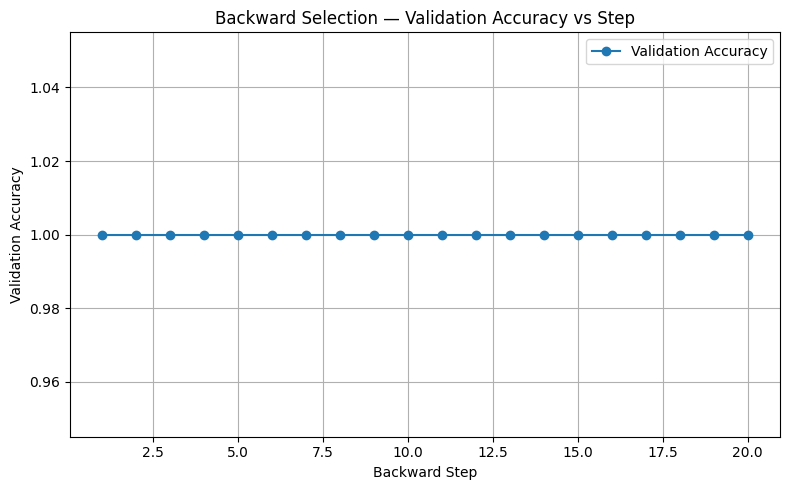

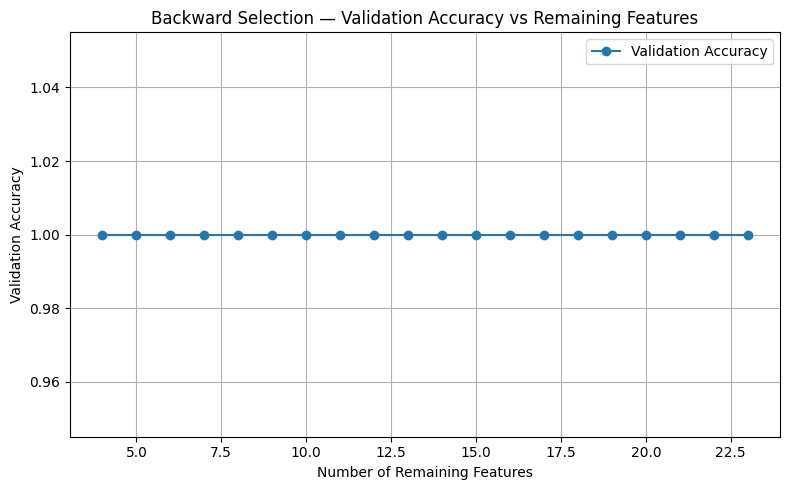

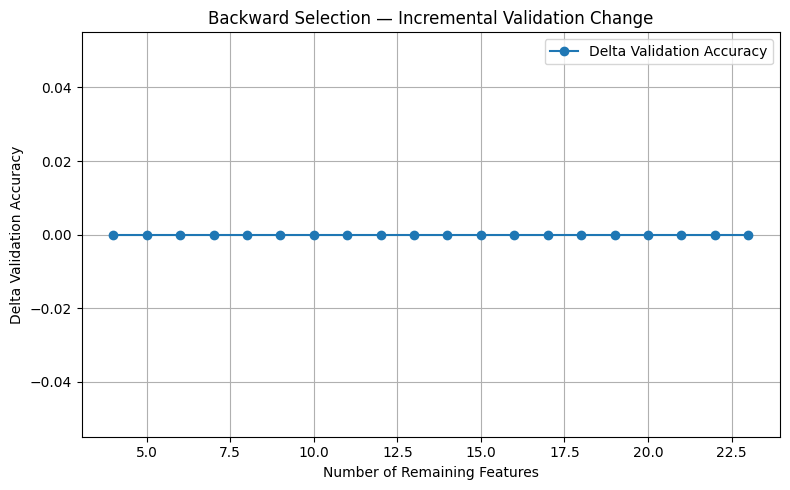


Best Step (by Validation Accuracy):
Step                : 20
Removed Feature     : sg
Remaining Features  : 4
Validation Accuracy : 1.0000
Delta Val Accuracy  : 0.0000


In [ ]:
# ============================================================
# BOX 55 — Backward Selection Analysis (Tables + Plots)
#
# Purpose:
#   - Analyze backward elimination step-by-step
#   - Visualize how validation performance changes as features are removed
#   - Quantify incremental validation change
#   - Provide analysis-ready tables for interpretation
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "backward_history_df",
    "selected_features_backward",
    "backward_val_acc",
    "backward_test_acc"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not isinstance(backward_history_df, pd.DataFrame):
    raise TypeError("backward_history_df must be a pandas DataFrame.")

if not isinstance(selected_features_backward, list) or len(selected_features_backward) == 0:
    raise ValueError("selected_features_backward must be a non-empty list.")

if not all(isinstance(f, str) for f in selected_features_backward):
    raise TypeError("All entries in selected_features_backward must be strings.")

if len(set(selected_features_backward)) != len(selected_features_backward):
    raise ValueError("selected_features_backward must not contain duplicate feature names.")

if not isinstance(backward_val_acc, (int, float, np.floating)):
    raise TypeError("backward_val_acc must be numeric.")

if not isinstance(backward_test_acc, (int, float, np.floating)):
    raise TypeError("backward_test_acc must be numeric.")

required_columns = [
    "Step",
    "Removed_Feature",
    "Remaining_Features",
    "Validation_Accuracy"
]

if not backward_history_df.empty:
    missing_columns = [col for col in required_columns if col not in backward_history_df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns in backward_history_df: {missing_columns}")

# ------------------------------------------------------------
# Step 1 — Prepare analysis table
# ------------------------------------------------------------
if backward_history_df.empty:
    backward_analysis_df = pd.DataFrame(columns=[
        "Step",
        "Removed_Feature",
        "Remaining_Features",
        "Validation_Accuracy",
        "Delta_Val_Acc"
    ])
else:
    backward_analysis_df = backward_history_df.copy()

    # Ensure proper ordering by backward step
    backward_analysis_df = backward_analysis_df.sort_values(by="Step").reset_index(drop=True)

    # Basic consistency checks
    if backward_analysis_df["Step"].duplicated().any():
        raise ValueError("Duplicate values found in 'Step' column of backward_history_df.")

    if backward_analysis_df["Removed_Feature"].duplicated().any():
        raise ValueError("Duplicate features found in 'Removed_Feature' column of backward_history_df.")

    if backward_analysis_df["Remaining_Features"].iloc[-1] != len(selected_features_backward):
        raise ValueError(
            "Mismatch between the final Remaining_Features in backward_history_df "
            "and the length of selected_features_backward."
        )

    # Compute incremental validation change
    backward_analysis_df["Delta_Val_Acc"] = (
        backward_analysis_df["Validation_Accuracy"].diff().fillna(0.0)
    )

# ------------------------------------------------------------
# Step 2 — Display analysis table
# ------------------------------------------------------------
print("Backward Selection — Detailed Analysis Table:")
display(backward_analysis_df)

backward_val_test_gap = float(backward_val_acc - backward_test_acc)

print("\nSummary:")
print(f"Total steps performed       : {len(backward_analysis_df)}")
print(f"Final number of features    : {len(selected_features_backward)}")
print(f"Final validation accuracy   : {backward_val_acc:.4f}")
print(f"Final test accuracy         : {backward_test_acc:.4f}")
print(f"Final validation-test gap   : {backward_val_test_gap:.4f}")

# ------------------------------------------------------------
# Step 3 — Plot validation accuracy versus elimination step
# ------------------------------------------------------------
if not backward_analysis_df.empty:
    plt.figure(figsize=(8, 5))

    plt.plot(
        backward_analysis_df["Step"],
        backward_analysis_df["Validation_Accuracy"],
        marker="o",
        label="Validation Accuracy"
    )

    plt.xlabel("Backward Step")
    plt.ylabel("Validation Accuracy")
    plt.title("Backward Selection — Validation Accuracy vs Step")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Step 4 — Plot validation accuracy versus remaining features
    # --------------------------------------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(
        backward_analysis_df["Remaining_Features"],
        backward_analysis_df["Validation_Accuracy"],
        marker="o",
        label="Validation Accuracy"
    )

    plt.xlabel("Number of Remaining Features")
    plt.ylabel("Validation Accuracy")
    plt.title("Backward Selection — Validation Accuracy vs Remaining Features")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Step 5 — Plot incremental validation change
    # --------------------------------------------------------
    plt.figure(figsize=(8, 5))

    plt.plot(
        backward_analysis_df["Remaining_Features"],
        backward_analysis_df["Delta_Val_Acc"],
        marker="o",
        label="Delta Validation Accuracy"
    )

    plt.xlabel("Number of Remaining Features")
    plt.ylabel("Delta Validation Accuracy")
    plt.title("Backward Selection — Incremental Validation Change")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Step 6 — Report best step
    #   - In case of equal validation accuracy, prefer the
    #     smaller remaining subset
    # --------------------------------------------------------
    best_row = backward_analysis_df.sort_values(
        by=["Validation_Accuracy", "Remaining_Features"],
        ascending=[False, True]
    ).iloc[0]

    print("\nBest Step (by Validation Accuracy):")
    print(f"Step                : {int(best_row['Step'])}")
    print(f"Removed Feature     : {best_row['Removed_Feature']}")
    print(f"Remaining Features  : {int(best_row['Remaining_Features'])}")
    print(f"Validation Accuracy : {best_row['Validation_Accuracy']:.4f}")
    print(f"Delta Val Accuracy  : {best_row['Delta_Val_Acc']:.4f}")
else:
    print("\nNo backward elimination step was performed.")
    print("The full feature set was retained because no non-degrading removal was found.")

In [ ]:
# ============================================================
# BOX 56 — Hybrid Selection Function (L-R Strategy)
#
# Purpose:
#   - Implement a hybrid wrapper method:
#       * Forward phase: add up to L features (one-by-one, greedy)
#       * Backward phase: remove up to R features (one-by-one, greedy)
#   - Accept only strictly improving moves in both phases
#   - Repeat forward/backward cycles until no improvement occurs
#   - Use deterministic tie-breaking by feature name
#
# Output:
#   - selected_features_hybrid
#   - hybrid_history_df
#   - hybrid_val_acc
# ============================================================

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "best_k",
    "X_train_zscore", "X_val_zscore",
    "y_train", "y_val"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

# ------------------------------------------------------------
# Step 1 — Hybrid selection function
# ------------------------------------------------------------
def hybrid_selection(X_train, y_train,
                     X_val, y_val,
                     k, L=1, R=1):
    """
    Perform hybrid forward-backward feature selection using
    validation accuracy only.

    Parameters
    ----------
    X_train, X_val : pandas.DataFrame
        Feature matrices.
    y_train, y_val : pandas.Series
        Target vectors.
    k : int
        Number of neighbors for KNN.
    L : int, default=1
        Maximum number of forward additions per cycle.
    R : int, default=1
        Maximum number of backward removals per cycle.

    Returns
    -------
    selected_features : list
        Final selected feature subset.
    history_df : pandas.DataFrame
        Full step-by-step selection history.
    final_val_acc : float
        Final validation accuracy.
    """

    # --------------------------------------------------------
    # Basic input checks
    # --------------------------------------------------------
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train must be a pandas DataFrame.")
    if not isinstance(X_val, pd.DataFrame):
        raise TypeError("X_val must be a pandas DataFrame.")
    if not isinstance(y_train, pd.Series):
        raise TypeError("y_train must be a pandas Series.")
    if not isinstance(y_val, pd.Series):
        raise TypeError("y_val must be a pandas Series.")

    if not isinstance(k, int) or k <= 0:
        raise ValueError("k must be a positive integer.")
    if not isinstance(L, int) or L <= 0:
        raise ValueError("L must be a positive integer.")
    if not isinstance(R, int) or R <= 0:
        raise ValueError("R must be a positive integer.")

    if X_train.empty:
        raise ValueError("X_train must not be empty.")
    if X_val.empty:
        raise ValueError("X_val must not be empty.")

    if not X_train.columns.equals(X_val.columns):
        raise ValueError("X_train and X_val must have identical columns in the same order.")

    if len(X_train) != len(y_train):
        raise ValueError("X_train and y_train must have the same number of rows.")
    if len(X_val) != len(y_val):
        raise ValueError("X_val and y_val must have the same number of rows.")

    if not X_train.index.equals(y_train.index):
        raise ValueError("Index mismatch between X_train and y_train.")
    if not X_val.index.equals(y_val.index):
        raise ValueError("Index mismatch between X_val and y_val.")

    if k > len(y_train):
        raise ValueError("k cannot be larger than the number of training samples.")

    non_numeric_train = X_train.select_dtypes(exclude=["number"]).columns.tolist()
    non_numeric_val = X_val.select_dtypes(exclude=["number"]).columns.tolist()
    non_numeric_cols = sorted(set(non_numeric_train + non_numeric_val))
    if non_numeric_cols:
        raise TypeError(
            f"All feature columns must be numeric. Non-numeric columns found: {non_numeric_cols}"
        )

    all_features = list(X_train.columns)

    if len(all_features) == 0:
        raise ValueError("At least one feature is required for hybrid selection.")

    # --------------------------------------------------------
    # Internal utility for validation accuracy
    # --------------------------------------------------------
    def compute_val_accuracy(feature_subset):
        if not isinstance(feature_subset, list) or len(feature_subset) == 0:
            raise ValueError("feature_subset must be a non-empty list.")

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train[feature_subset], y_train)
        y_val_pred = model.predict(X_val[feature_subset])
        return accuracy_score(y_val, y_val_pred)

    # --------------------------------------------------------
    # Step 1.1 — Initialize with the best single-feature model
    # --------------------------------------------------------
    best_init_feature = None
    best_init_val_acc = float("-inf")

    for feature in sorted(all_features):
        val_acc = compute_val_accuracy([feature])

        if val_acc > best_init_val_acc:
            best_init_val_acc = val_acc
            best_init_feature = feature

    if best_init_feature is None:
        raise ValueError("Failed to initialize hybrid selection with a valid feature.")

    selected_features = [best_init_feature]
    best_global_val_acc = float(best_init_val_acc)

    history = [{
        "Step": 0,
        "Phase": "Init",
        "Action": "Add",
        "Feature": best_init_feature,
        "Num_Features": 1,
        "Validation_Accuracy": float(best_global_val_acc)
    }]

    step = 0

    # --------------------------------------------------------
    # Step 2 — Repeat forward/backward cycles
    # --------------------------------------------------------
    while True:
        cycle_improved = False

        # ----------------------------------------------------
        # Step 2.1 — Forward phase
        # ----------------------------------------------------
        for _ in range(L):
            remaining_features = sorted([f for f in all_features if f not in selected_features])

            if len(remaining_features) == 0:
                break

            best_feature_to_add = None
            best_val_acc_step = best_global_val_acc

            for feature in remaining_features:
                candidate_features = selected_features + [feature]
                val_acc = compute_val_accuracy(candidate_features)

                # Strict improvement only
                # Tie-breaking is deterministic because features are sorted
                if val_acc > best_val_acc_step:
                    best_val_acc_step = val_acc
                    best_feature_to_add = feature

            if best_feature_to_add is None:
                break

            selected_features.append(best_feature_to_add)
            best_global_val_acc = float(best_val_acc_step)
            step += 1
            cycle_improved = True

            history.append({
                "Step": int(step),
                "Phase": "Forward",
                "Action": "Add",
                "Feature": best_feature_to_add,
                "Num_Features": int(len(selected_features)),
                "Validation_Accuracy": float(best_global_val_acc)
            })

        # ----------------------------------------------------
        # Step 2.2 — Backward phase
        # ----------------------------------------------------
        for _ in range(R):
            if len(selected_features) <= 1:
                break

            best_feature_to_remove = None
            best_val_acc_step = best_global_val_acc

            for feature in sorted(selected_features):
                candidate_features = [f for f in selected_features if f != feature]
                val_acc = compute_val_accuracy(candidate_features)

                # Strict improvement only
                # Tie-breaking is deterministic because features are sorted
                if val_acc > best_val_acc_step:
                    best_val_acc_step = val_acc
                    best_feature_to_remove = feature

            if best_feature_to_remove is None:
                break

            selected_features.remove(best_feature_to_remove)
            best_global_val_acc = float(best_val_acc_step)
            step += 1
            cycle_improved = True

            history.append({
                "Step": int(step),
                "Phase": "Backward",
                "Action": "Remove",
                "Feature": best_feature_to_remove,
                "Num_Features": int(len(selected_features)),
                "Validation_Accuracy": float(best_global_val_acc)
            })

        # ----------------------------------------------------
        # Step 2.3 — Stop if the full cycle made no improvement
        # ----------------------------------------------------
        if not cycle_improved:
            break

    # --------------------------------------------------------
    # Step 3 — Build history table
    # --------------------------------------------------------
    history_df = pd.DataFrame(
        history,
        columns=[
            "Step",
            "Phase",
            "Action",
            "Feature",
            "Num_Features",
            "Validation_Accuracy"
        ]
    )

    return selected_features, history_df, float(best_global_val_acc)


print("Hybrid selection function (L-R strategy) defined successfully.")

Hybrid selection function (L-R strategy) defined successfully.


In [ ]:
# ============================================================
# BOX 57 — Hybrid Sensitivity Analysis for (L, R)
#
# Purpose:
#   - Evaluate Hybrid selection across multiple (L, R) combinations
#   - Use validation accuracy as the primary selection criterion
#   - Store performance, number of selected features, and number of steps
#   - Produce ranked results for parameter selection
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "hybrid_selection",
    "best_k",
    "evaluate_knn",
    "X_train_zscore", "X_val_zscore", "X_test_zscore",
    "y_train", "y_val", "y_test"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not callable(hybrid_selection):
    raise TypeError("hybrid_selection must be a callable function.")

if not callable(evaluate_knn):
    raise TypeError("evaluate_knn must be a callable function.")

if not isinstance(best_k, int) or best_k <= 0:
    raise ValueError("best_k must be a positive integer.")

# ------------------------------------------------------------
# Step 1 — Define candidate (L, R) combinations
# ------------------------------------------------------------
LR_grid = [
    (1, 1), (2, 1), (2, 2),
    (3, 1), (3, 2), (3, 3)
]

if not isinstance(LR_grid, list) or len(LR_grid) == 0:
    raise ValueError("LR_grid must be a non-empty list of (L, R) tuples.")

if len(set(LR_grid)) != len(LR_grid):
    raise ValueError("LR_grid must not contain duplicate (L, R) combinations.")

for pair in LR_grid:
    if not isinstance(pair, tuple) or len(pair) != 2:
        raise TypeError("Each element of LR_grid must be a tuple of length 2.")
    L, R = pair
    if not isinstance(L, int) or L <= 0:
        raise ValueError(f"Invalid L value in LR_grid: {L}")
    if not isinstance(R, int) or R <= 0:
        raise ValueError(f"Invalid R value in LR_grid: {R}")

# ------------------------------------------------------------
# Step 2 — Run sensitivity analysis
# ------------------------------------------------------------
results = []

for L, R in LR_grid:
    selected_features, history_df, val_acc = hybrid_selection(
        X_train=X_train_zscore,
        y_train=y_train,
        X_val=X_val_zscore,
        y_val=y_val,
        k=best_k,
        L=L,
        R=R
    )

    if not isinstance(selected_features, list) or len(selected_features) == 0:
        raise ValueError(f"Hybrid selection returned an invalid feature subset for (L, R)=({L}, {R}).")

    if not all(isinstance(f, str) for f in selected_features):
        raise TypeError(f"Hybrid selection returned non-string feature names for (L, R)=({L}, {R}).")

    if len(set(selected_features)) != len(selected_features):
        raise ValueError(f"Hybrid selection returned duplicate features for (L, R)=({L}, {R}).")

    if not isinstance(history_df, pd.DataFrame):
        raise TypeError(f"history_df must be a pandas DataFrame for (L, R)=({L}, {R}).")

    # Test accuracy is computed for reporting only
    _, test_acc = evaluate_knn(
        feature_subset=selected_features,
        k=best_k,
        X_train=X_train_zscore,
        y_train=y_train,
        X_val=X_val_zscore,
        y_val=y_val,
        X_test=X_test_zscore,
        y_test=y_test
    )

    # Count actual selection moves only (exclude initialization step 0)
    if history_df.empty:
        num_steps = 0
    else:
        num_steps = int(history_df["Step"].max())

    results.append({
        "L": int(L),
        "R": int(R),
        "Num_Features": int(len(selected_features)),
        "Selected_Features": ", ".join(selected_features),
        "Validation_Accuracy": float(val_acc),
        "Test_Accuracy": float(test_acc),
        "Val_Test_Gap": float(val_acc - test_acc),
        "Num_Steps": int(num_steps)
    })

# ------------------------------------------------------------
# Step 3 — Create results tables
# ------------------------------------------------------------
hybrid_sensitivity_df = pd.DataFrame(results)

if hybrid_sensitivity_df.empty:
    raise ValueError("hybrid_sensitivity_df is empty.")

hybrid_sensitivity_sorted = hybrid_sensitivity_df.sort_values(
    by=["Validation_Accuracy", "Num_Features", "L", "R"],
    ascending=[False, True, True, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 4 — Display results
# ------------------------------------------------------------
print("Hybrid Sensitivity Analysis (L, R Grid)")
display(hybrid_sensitivity_df)

print("\nTop configurations (sorted for validation-based selection):")
display(hybrid_sensitivity_sorted.head(5))

# ------------------------------------------------------------
# Step 5 — Select best (L, R)
# ------------------------------------------------------------
best_L = int(hybrid_sensitivity_sorted.loc[0, "L"])
best_R = int(hybrid_sensitivity_sorted.loc[0, "R"])
best_val_acc_hybrid = float(hybrid_sensitivity_sorted.loc[0, "Validation_Accuracy"])
best_test_acc_hybrid = float(
    hybrid_sensitivity_df.loc[
        (hybrid_sensitivity_df["L"] == best_L) &
        (hybrid_sensitivity_df["R"] == best_R),
        "Test_Accuracy"
    ].iloc[0]
)

print(f"\nBest (L, R) based on validation only: ({best_L}, {best_R})")
print(f"Validation Accuracy                 : {best_val_acc_hybrid:.4f}")
print(f"Test Accuracy                       : {best_test_acc_hybrid:.4f}")

Hybrid Sensitivity Analysis (L, R Grid)


,L,R,Num_Features,Selected_Features,Validation_Accuracy,Test_Accuracy,Val_Test_Gap,Num_Steps
0,1,1,3,"hemo, htn, sc",1.0,0.9375,0.0625,2
1,2,1,3,"hemo, htn, sc",1.0,0.9375,0.0625,2
2,2,2,3,"hemo, htn, sc",1.0,0.9375,0.0625,2
3,3,1,3,"hemo, htn, sc",1.0,0.9375,0.0625,2
4,3,2,3,"hemo, htn, sc",1.0,0.9375,0.0625,2
5,3,3,3,"hemo, htn, sc",1.0,0.9375,0.0625,2



Top configurations (sorted for validation-based selection):


,L,R,Num_Features,Selected_Features,Validation_Accuracy,Test_Accuracy,Val_Test_Gap,Num_Steps
0,1,1,3,"hemo, htn, sc",1.0,0.9375,0.0625,2
1,2,1,3,"hemo, htn, sc",1.0,0.9375,0.0625,2
2,2,2,3,"hemo, htn, sc",1.0,0.9375,0.0625,2
3,3,1,3,"hemo, htn, sc",1.0,0.9375,0.0625,2
4,3,2,3,"hemo, htn, sc",1.0,0.9375,0.0625,2



Best (L, R) based on validation only: (1, 1)
Validation Accuracy                 : 1.0000
Test Accuracy                       : 0.9375


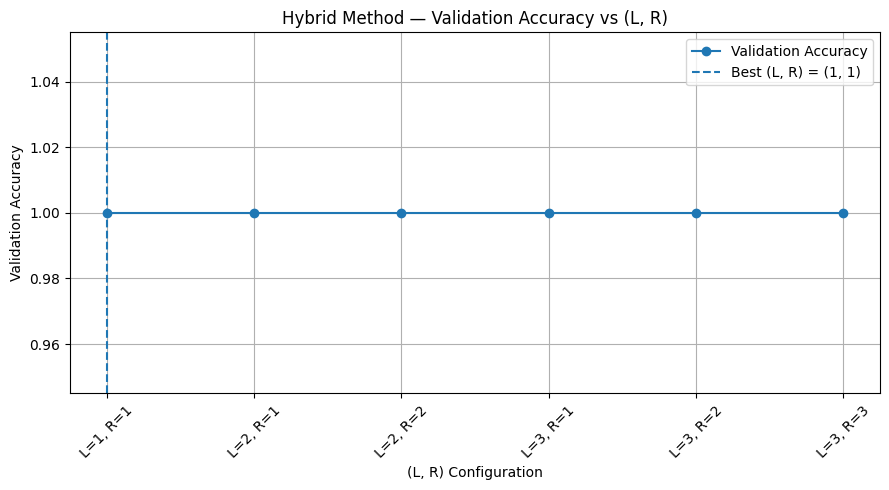

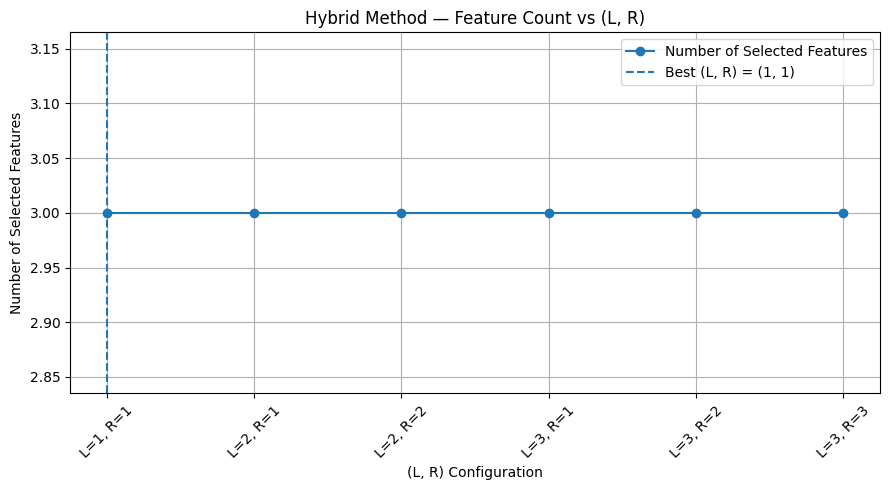

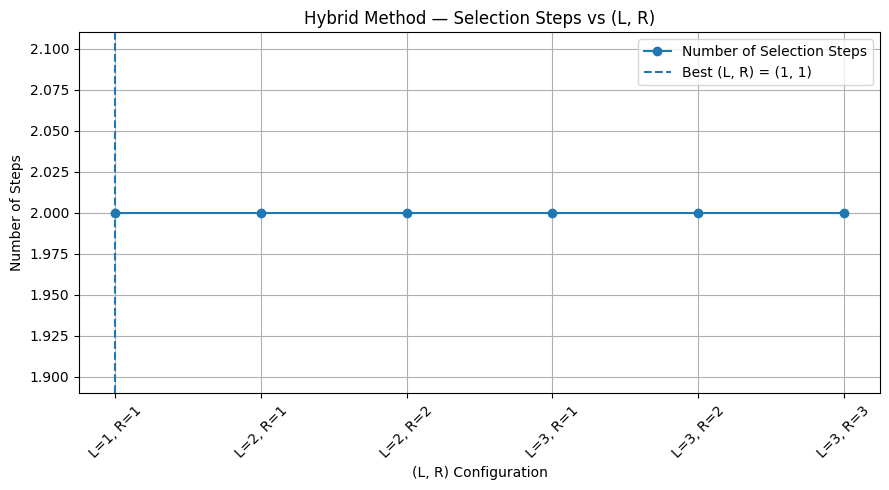

Best (L, R) Configuration (based on Validation Accuracy only):
L = 1, R = 1
Validation Accuracy = 1.0000
Test Accuracy       = 0.9375
Gap (Val-Test)      = 0.0625
Number of Features  = 3
Number of Steps     = 2


In [ ]:
# ============================================================
# BOX 58 — Hybrid Parameter Pluning? No. Hybrid Parameter Plots
# and Best (L, R) Decision
#
# Purpose:
#   - Visualize Hybrid sensitivity analysis results across (L, R)
#   - Plot validation accuracy versus (L, R)
#   - Plot number of selected features versus (L, R)
#   - Plot number of selection steps versus (L, R)
#   - Confirm the best (L, R) configuration
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "hybrid_sensitivity_df",
    "best_L",
    "best_R"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not isinstance(hybrid_sensitivity_df, pd.DataFrame):
    raise TypeError("hybrid_sensitivity_df must be a pandas DataFrame.")

if hybrid_sensitivity_df.empty:
    raise ValueError("hybrid_sensitivity_df is empty.")

if not isinstance(best_L, int) or best_L <= 0:
    raise ValueError("best_L must be a positive integer.")

if not isinstance(best_R, int) or best_R <= 0:
    raise ValueError("best_R must be a positive integer.")

required_columns = [
    "L",
    "R",
    "Validation_Accuracy",
    "Test_Accuracy",
    "Val_Test_Gap",
    "Num_Features",
    "Num_Steps"
]
missing_columns = [col for col in required_columns if col not in hybrid_sensitivity_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in hybrid_sensitivity_df: {missing_columns}")

# ------------------------------------------------------------
# Step 1 — Prepare plotting table
# ------------------------------------------------------------
df_plot = hybrid_sensitivity_df.copy()

# Ensure numeric columns are valid
numeric_columns = [
    "L", "R",
    "Validation_Accuracy", "Test_Accuracy", "Val_Test_Gap",
    "Num_Features", "Num_Steps"
]
for col in numeric_columns:
    if not pd.api.types.is_numeric_dtype(df_plot[col]):
        raise TypeError(f"Column '{col}' must be numeric.")

# Ensure no duplicate (L, R) configurations exist
if df_plot.duplicated(subset=["L", "R"]).any():
    raise ValueError("Duplicate (L, R) configurations found in hybrid_sensitivity_df.")

df_plot["L"] = df_plot["L"].astype(int)
df_plot["R"] = df_plot["R"].astype(int)

df_plot["LR_Label"] = df_plot.apply(
    lambda row: f"L={int(row['L'])}, R={int(row['R'])}",
    axis=1
)

df_plot = df_plot.sort_values(by=["L", "R"]).reset_index(drop=True)
x_pos = list(range(len(df_plot)))

best_mask = (df_plot["L"] == best_L) & (df_plot["R"] == best_R)
if not best_mask.any():
    raise ValueError(f"The specified best (L, R)=({best_L}, {best_R}) was not found in hybrid_sensitivity_df.")

best_idx = int(df_plot.index[best_mask][0])

# ------------------------------------------------------------
# Step 2 — Plot validation accuracy versus (L, R)
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

plt.plot(
    x_pos,
    df_plot["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=best_idx,
    linestyle="--",
    label=f"Best (L, R) = ({best_L}, {best_R})"
)

plt.xlabel("(L, R) Configuration")
plt.ylabel("Validation Accuracy")
plt.title("Hybrid Method — Validation Accuracy vs (L, R)")
plt.xticks(ticks=x_pos, labels=df_plot["LR_Label"], rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 3 — Plot number of selected features versus (L, R)
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

plt.plot(
    x_pos,
    df_plot["Num_Features"],
    marker="o",
    label="Number of Selected Features"
)

plt.axvline(
    x=best_idx,
    linestyle="--",
    label=f"Best (L, R) = ({best_L}, {best_R})"
)

plt.xlabel("(L, R) Configuration")
plt.ylabel("Number of Selected Features")
plt.title("Hybrid Method — Feature Count vs (L, R)")
plt.xticks(ticks=x_pos, labels=df_plot["LR_Label"], rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 4 — Plot number of selection steps versus (L, R)
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

plt.plot(
    x_pos,
    df_plot["Num_Steps"],
    marker="o",
    label="Number of Selection Steps"
)

plt.axvline(
    x=best_idx,
    linestyle="--",
    label=f"Best (L, R) = ({best_L}, {best_R})"
)

plt.xlabel("(L, R) Configuration")
plt.ylabel("Number of Steps")
plt.title("Hybrid Method — Selection Steps vs (L, R)")
plt.xticks(ticks=x_pos, labels=df_plot["LR_Label"], rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 5 — Report best (L, R)
# ------------------------------------------------------------
best_row = df_plot.loc[best_idx]

hybrid_num_features = int(best_row["Num_Features"])
hybrid_num_steps = int(best_row["Num_Steps"])
hybrid_val_acc = float(best_row["Validation_Accuracy"])
hybrid_test_acc = float(best_row["Test_Accuracy"])
hybrid_val_test_gap = float(best_row["Val_Test_Gap"])

print("Best (L, R) Configuration (based on Validation Accuracy only):")
print(f"L = {best_L}, R = {best_R}")
print(f"Validation Accuracy = {hybrid_val_acc:.4f}")
print(f"Test Accuracy       = {hybrid_test_acc:.4f}")
print(f"Gap (Val-Test)      = {hybrid_val_test_gap:.4f}")
print(f"Number of Features  = {hybrid_num_features}")
print(f"Number of Steps     = {hybrid_num_steps}")

In [ ]:
# ============================================================
# BOX 59 — Run Final Hybrid with Best (L, R)
#
# Purpose:
#   - Execute Hybrid selection using best_L and best_R
#   - Obtain the final selected feature subset
#   - Store the full step-by-step selection history (validation only)
#   - Compute final validation and test accuracy
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "hybrid_selection",
    "evaluate_knn",
    "best_k",
    "best_L",
    "best_R",
    "X_train_zscore", "X_val_zscore", "X_test_zscore",
    "y_train", "y_val", "y_test"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not callable(hybrid_selection):
    raise TypeError("hybrid_selection must be a callable function.")

if not callable(evaluate_knn):
    raise TypeError("evaluate_knn must be a callable function.")

if not isinstance(best_k, int) or best_k <= 0:
    raise ValueError("best_k must be a positive integer.")

if not isinstance(best_L, int) or best_L <= 0:
    raise ValueError("best_L must be a positive integer.")

if not isinstance(best_R, int) or best_R <= 0:
    raise ValueError("best_R must be a positive integer.")

# ------------------------------------------------------------
# Step 1 — Run Hybrid selection with best (L, R)
# ------------------------------------------------------------
selected_features_hybrid, hybrid_history_df, hybrid_val_acc = hybrid_selection(
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    k=best_k,
    L=best_L,
    R=best_R
)

# ------------------------------------------------------------
# Step 2 — Validate outputs
# ------------------------------------------------------------
if not isinstance(selected_features_hybrid, list):
    raise TypeError("selected_features_hybrid must be a list.")

if len(selected_features_hybrid) == 0:
    raise ValueError("Hybrid selection returned an empty feature subset.")

if not all(isinstance(f, str) for f in selected_features_hybrid):
    raise TypeError("All selected hybrid features must be strings.")

if len(set(selected_features_hybrid)) != len(selected_features_hybrid):
    raise ValueError("selected_features_hybrid must not contain duplicate feature names.")

if not isinstance(hybrid_history_df, pd.DataFrame):
    raise TypeError("hybrid_history_df must be a pandas DataFrame.")

if hybrid_history_df.empty:
    raise ValueError("hybrid_history_df is empty.")

if not isinstance(hybrid_val_acc, (int, float, np.floating)):
    raise TypeError("hybrid_val_acc must be numeric.")

required_columns = [
    "Step",
    "Phase",
    "Action",
    "Feature",
    "Num_Features",
    "Validation_Accuracy"
]
missing_columns = [col for col in required_columns if col not in hybrid_history_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in hybrid_history_df: {missing_columns}")

if hybrid_history_df["Step"].duplicated().any():
    raise ValueError("Duplicate values found in 'Step' column of hybrid_history_df.")

if hybrid_history_df["Num_Features"].iloc[-1] != len(selected_features_hybrid):
    raise ValueError(
        "Mismatch between the final Num_Features in hybrid_history_df "
        "and the length of selected_features_hybrid."
    )

# Ensure selected features exist in all splits
missing_train = [f for f in selected_features_hybrid if f not in X_train_zscore.columns]
missing_val   = [f for f in selected_features_hybrid if f not in X_val_zscore.columns]
missing_test  = [f for f in selected_features_hybrid if f not in X_test_zscore.columns]

if missing_train:
    raise ValueError(f"Selected hybrid features missing from X_train_zscore: {missing_train}")
if missing_val:
    raise ValueError(f"Selected hybrid features missing from X_val_zscore: {missing_val}")
if missing_test:
    raise ValueError(f"Selected hybrid features missing from X_test_zscore: {missing_test}")

# ------------------------------------------------------------
# Step 3 — Final evaluation on the selected subset
# ------------------------------------------------------------
_, hybrid_test_acc = evaluate_knn(
    feature_subset=selected_features_hybrid,
    k=best_k,
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    X_test=X_test_zscore,
    y_test=y_test
)

hybrid_num_features = len(selected_features_hybrid)
hybrid_val_test_gap = float(hybrid_val_acc - hybrid_test_acc)

# ------------------------------------------------------------
# Step 4 — Summary outputs
# ------------------------------------------------------------
print("Hybrid Selection Results")
print(f"Best (L, R)                : ({best_L}, {best_R})")
print(f"Number of selected features: {hybrid_num_features}")
print(f"Validation Accuracy        : {hybrid_val_acc:.4f}")
print(f"Test Accuracy              : {hybrid_test_acc:.4f}")
print(f"Gap (Val-Test)             : {hybrid_val_test_gap:.4f}")

print("\nSelected Features:")
print(selected_features_hybrid)

# ------------------------------------------------------------
# Step 5 — Display history
# ------------------------------------------------------------
print("\nHybrid Selection History:")
display(hybrid_history_df)

Hybrid Selection Results
Best (L, R)                : (1, 1)
Number of selected features: 3
Validation Accuracy        : 1.0000
Test Accuracy              : 0.9375
Gap (Val-Test)             : 0.0625

Selected Features:
['hemo', 'htn', 'sc']

Hybrid Selection History:


,Step,Phase,Action,Feature,Num_Features,Validation_Accuracy
0,0,Init,Add,hemo,1,0.9625
1,1,Forward,Add,htn,2,0.9875
2,2,Forward,Add,sc,3,1.0000


Final Comparison Table:


,Method,Num_Features,Selected_Features,Validation_Accuracy,Test_Accuracy,Val_Test_Gap,Generalization_Score,Delta_Test_vs_Baseline
0,Baseline (All Features),24,"age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, bu...",0.9875,0.9500,0.0375,0.9125,0.0000
1,Filter,15,"hemo, sg, pcv, rc, htn, al, dm, sod, bu, pc, a...",1.0000,0.9625,0.0375,0.9250,0.0125
2,Forward,3,"hemo, htn, sc",1.0000,0.9375,0.0625,0.8750,-0.0125
3,Backward,4,"su, sod, hemo, pcv",1.0000,0.9000,0.1000,0.8000,-0.0500
4,Hybrid,3,"hemo, htn, sc",1.0000,0.9375,0.0625,0.8750,-0.0125



Ranked Comparison Table (validation-based ranking):


,Method,Num_Features,Selected_Features,Validation_Accuracy,Test_Accuracy,Val_Test_Gap,Generalization_Score,Delta_Test_vs_Baseline
0,Forward,3,"hemo, htn, sc",1.0000,0.9375,0.0625,0.8750,-0.0125
1,Hybrid,3,"hemo, htn, sc",1.0000,0.9375,0.0625,0.8750,-0.0125
2,Backward,4,"su, sod, hemo, pcv",1.0000,0.9000,0.1000,0.8000,-0.0500
3,Filter,15,"hemo, sg, pcv, rc, htn, al, dm, sod, bu, pc, a...",1.0000,0.9625,0.0375,0.9250,0.0125
4,Baseline (All Features),24,"age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, bu...",0.9875,0.9500,0.0375,0.9125,0.0000



Ranked Comparison Table (generalization-aware ranking):


,Method,Num_Features,Selected_Features,Validation_Accuracy,Test_Accuracy,Val_Test_Gap,Generalization_Score,Delta_Test_vs_Baseline
0,Filter,15,"hemo, sg, pcv, rc, htn, al, dm, sod, bu, pc, a...",1.0000,0.9625,0.0375,0.9250,0.0125
1,Baseline (All Features),24,"age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, bu...",0.9875,0.9500,0.0375,0.9125,0.0000
2,Forward,3,"hemo, htn, sc",1.0000,0.9375,0.0625,0.8750,-0.0125
3,Hybrid,3,"hemo, htn, sc",1.0000,0.9375,0.0625,0.8750,-0.0125
4,Backward,4,"su, sod, hemo, pcv",1.0000,0.9000,0.1000,0.8000,-0.0500


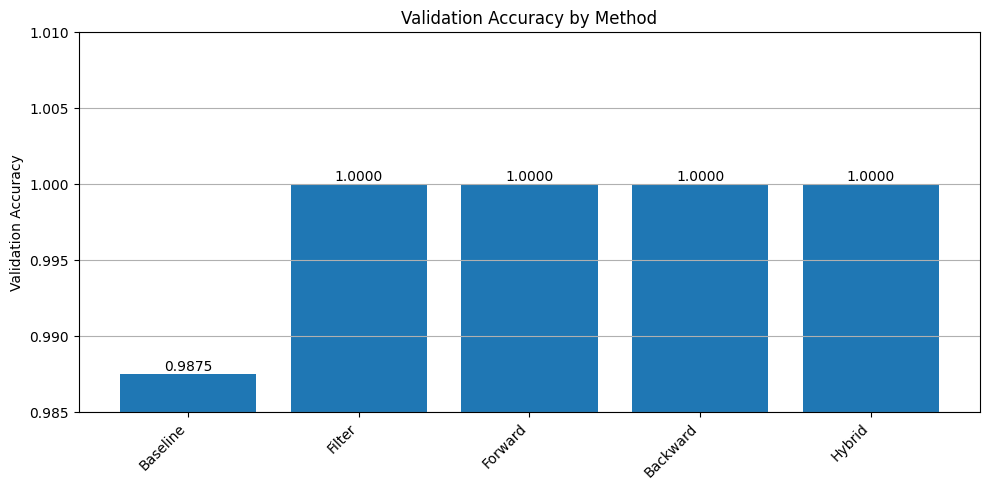

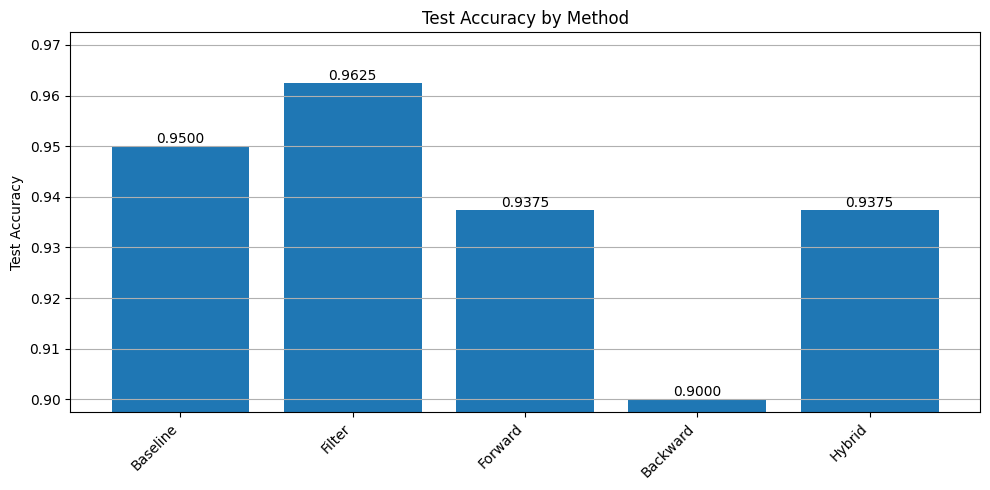

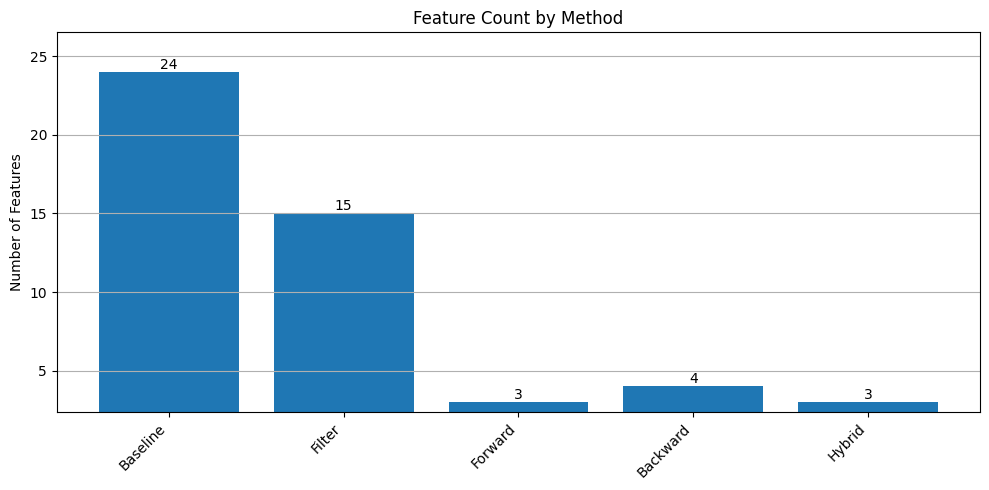

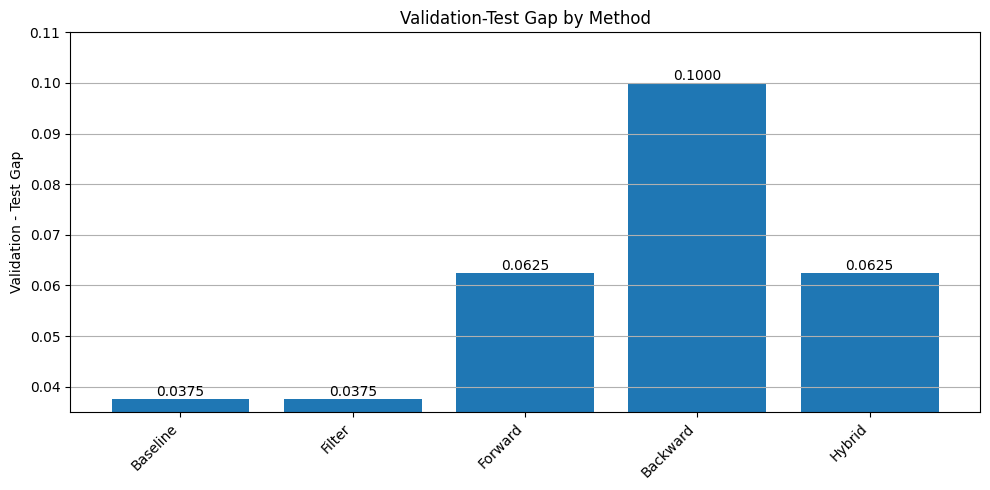

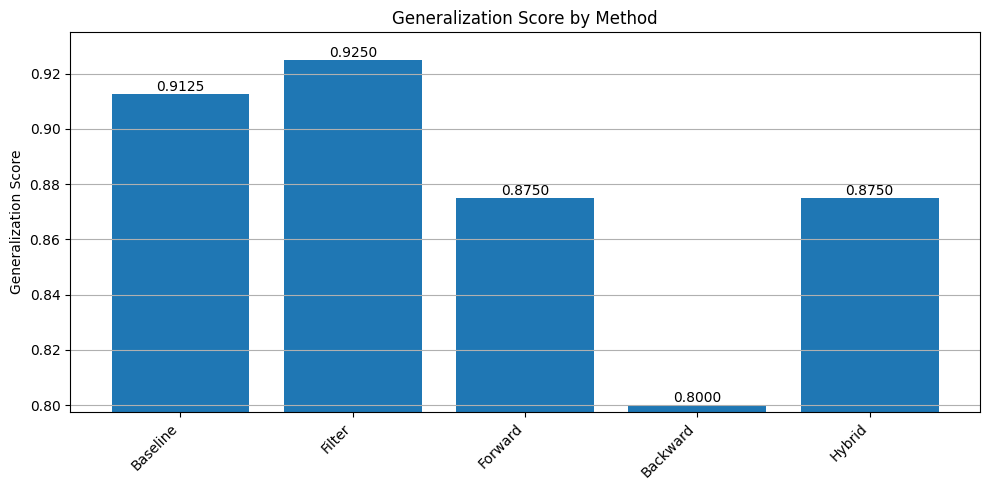

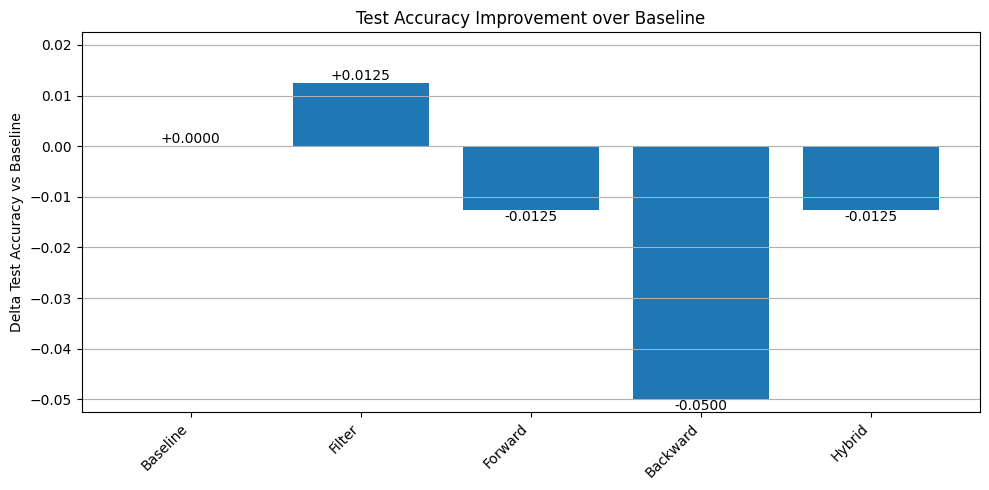


Top Method under Validation Ranking (tie broken by smaller subset):
Method               : Forward
Validation Accuracy  : 1.0000
Test Accuracy        : 0.9375
Number of Features   : 3
Val-Test Gap         : 0.0625

Best Method (recommended final choice based on generalization):
Method               : Filter
Validation Accuracy  : 1.0000
Test Accuracy        : 0.9625
Number of Features   : 15
Val-Test Gap         : 0.0375
Generalization Score : 0.9250
Delta Test vs Base   : +0.0125

Conclusion Support:
Multiple methods achieved the same maximum validation accuracy; therefore, validation accuracy alone is insufficient for final selection.
Final selection is based on generalization performance, prioritizing higher test accuracy and smaller validation-test gap.
Selected Method      : Filter
Selected Feature Set : hemo, sg, pcv, rc, htn, al, dm, sod, bu, pc, appet, bgr, pe, ane, sc
Selected Method Test : 0.9625
Selected Method Gap  : 0.0375


In [ ]:
# ============================================================
# BOX 60 — Final Comparison (Tables + Plots + Conclusion Support)
#
# Purpose:
#   - Compare all methods:
#       * Baseline (all features)
#       * Filter
#       * Forward
#       * Backward
#       * Hybrid
#   - Re-evaluate all methods consistently using the same utility
#   - Provide final tables and enhanced annotated plots
#   - Support decision-making for Section (d)
#   - Select the final best method using generalization-aware ranking
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "best_k",
    "evaluate_knn",
    "evaluate_knn_full",
    "filter_selected_features",
    "selected_features_forward",
    "selected_features_backward",
    "selected_features_hybrid",
    "X_train_zscore", "X_val_zscore", "X_test_zscore",
    "y_train", "y_val", "y_test"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not callable(evaluate_knn):
    raise TypeError("evaluate_knn must be a callable function.")

if not callable(evaluate_knn_full):
    raise TypeError("evaluate_knn_full must be a callable function.")

if not isinstance(best_k, int) or best_k <= 0:
    raise ValueError("best_k must be a positive integer.")

# ------------------------------------------------------------
# Step 1 — Validate feature subsets
# ------------------------------------------------------------
feature_sets = {
    "Filter": filter_selected_features,
    "Forward": selected_features_forward,
    "Backward": selected_features_backward,
    "Hybrid": selected_features_hybrid
}

for method_name, feature_subset in feature_sets.items():
    if not isinstance(feature_subset, list) or len(feature_subset) == 0:
        raise ValueError(f"{method_name} feature subset must be a non-empty list.")

    if not all(isinstance(f, str) for f in feature_subset):
        raise TypeError(f"All features in {method_name} subset must be strings.")

    if len(set(feature_subset)) != len(feature_subset):
        raise ValueError(f"{method_name} feature subset must not contain duplicate feature names.")

    missing_train = [f for f in feature_subset if f not in X_train_zscore.columns]
    missing_val   = [f for f in feature_subset if f not in X_val_zscore.columns]
    missing_test  = [f for f in feature_subset if f not in X_test_zscore.columns]

    if missing_train:
        raise ValueError(f"{method_name} features missing from X_train_zscore: {missing_train}")
    if missing_val:
        raise ValueError(f"{method_name} features missing from X_val_zscore: {missing_val}")
    if missing_test:
        raise ValueError(f"{method_name} features missing from X_test_zscore: {missing_test}")

# ------------------------------------------------------------
# Step 2 — Re-evaluate all methods consistently
# ------------------------------------------------------------
baseline_val_acc, baseline_test_acc = evaluate_knn_full(
    k=best_k,
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    X_test=X_test_zscore,
    y_test=y_test
)

filter_val_acc, filter_test_acc = evaluate_knn(
    feature_subset=filter_selected_features,
    k=best_k,
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    X_test=X_test_zscore,
    y_test=y_test
)

forward_val_acc, forward_test_acc = evaluate_knn(
    feature_subset=selected_features_forward,
    k=best_k,
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    X_test=X_test_zscore,
    y_test=y_test
)

backward_val_acc, backward_test_acc = evaluate_knn(
    feature_subset=selected_features_backward,
    k=best_k,
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    X_test=X_test_zscore,
    y_test=y_test
)

hybrid_val_acc, hybrid_test_acc = evaluate_knn(
    feature_subset=selected_features_hybrid,
    k=best_k,
    X_train=X_train_zscore,
    y_train=y_train,
    X_val=X_val_zscore,
    y_val=y_val,
    X_test=X_test_zscore,
    y_test=y_test
)

# ------------------------------------------------------------
# Step 3 — Collect final results
# ------------------------------------------------------------
results = [
    {
        "Method": "Baseline (All Features)",
        "Method_Short": "Baseline",
        "Num_Features": int(X_train_zscore.shape[1]),
        "Selected_Features": ", ".join(list(X_train_zscore.columns)),
        "Validation_Accuracy": float(baseline_val_acc),
        "Test_Accuracy": float(baseline_test_acc)
    },
    {
        "Method": "Filter",
        "Method_Short": "Filter",
        "Num_Features": int(len(filter_selected_features)),
        "Selected_Features": ", ".join(filter_selected_features),
        "Validation_Accuracy": float(filter_val_acc),
        "Test_Accuracy": float(filter_test_acc)
    },
    {
        "Method": "Forward",
        "Method_Short": "Forward",
        "Num_Features": int(len(selected_features_forward)),
        "Selected_Features": ", ".join(selected_features_forward),
        "Validation_Accuracy": float(forward_val_acc),
        "Test_Accuracy": float(forward_test_acc)
    },
    {
        "Method": "Backward",
        "Method_Short": "Backward",
        "Num_Features": int(len(selected_features_backward)),
        "Selected_Features": ", ".join(selected_features_backward),
        "Validation_Accuracy": float(backward_val_acc),
        "Test_Accuracy": float(backward_test_acc)
    },
    {
        "Method": "Hybrid",
        "Method_Short": "Hybrid",
        "Num_Features": int(len(selected_features_hybrid)),
        "Selected_Features": ", ".join(selected_features_hybrid),
        "Validation_Accuracy": float(hybrid_val_acc),
        "Test_Accuracy": float(hybrid_test_acc)
    }
]

final_comparison_df = pd.DataFrame(results)

if final_comparison_df.empty:
    raise ValueError("final_comparison_df is empty.")

# ------------------------------------------------------------
# Step 4 — Add derived comparison columns
# ------------------------------------------------------------
final_comparison_df["Val_Test_Gap"] = (
    final_comparison_df["Validation_Accuracy"] - final_comparison_df["Test_Accuracy"]
)

# Generalization-oriented score:
#   - Higher test accuracy is better
#   - Smaller validation-test gap is better
final_comparison_df["Generalization_Score"] = (
    final_comparison_df["Test_Accuracy"] - final_comparison_df["Val_Test_Gap"]
)

# Improvement over baseline test accuracy
baseline_test_reference = float(
    final_comparison_df.loc[
        final_comparison_df["Method"] == "Baseline (All Features)", "Test_Accuracy"
    ].iloc[0]
)
final_comparison_df["Delta_Test_vs_Baseline"] = (
    final_comparison_df["Test_Accuracy"] - baseline_test_reference
)

# Improvement over baseline validation accuracy
baseline_val_reference = float(
    final_comparison_df.loc[
        final_comparison_df["Method"] == "Baseline (All Features)", "Validation_Accuracy"
    ].iloc[0]
)
final_comparison_df["Delta_Val_vs_Baseline"] = (
    final_comparison_df["Validation_Accuracy"] - baseline_val_reference
)

# ------------------------------------------------------------
# Step 5 — Ranking tables
# ------------------------------------------------------------
# Validation-based ranking
#   - Primary: Validation Accuracy (DESC)
#   - Secondary: fewer features (ASC)
#   - Tertiary: method name (ASC)
final_comparison_sorted_validation = final_comparison_df.sort_values(
    by=["Validation_Accuracy", "Num_Features", "Method"],
    ascending=[False, True, True]
).reset_index(drop=True)

# Generalization-aware ranking for final decision
#   - Primary: Test Accuracy (DESC)
#   - Secondary: smaller Val-Test Gap (ASC)
#   - Tertiary: fewer features (ASC)
#   - Quaternary: method name (ASC)
final_comparison_sorted_generalization = final_comparison_df.sort_values(
    by=["Test_Accuracy", "Val_Test_Gap", "Num_Features", "Method"],
    ascending=[False, True, True, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 6 — Validation tie diagnostic
# ------------------------------------------------------------
max_val_acc = float(final_comparison_df["Validation_Accuracy"].max())
methods_at_max_val = final_comparison_df.loc[
    np.isclose(final_comparison_df["Validation_Accuracy"], max_val_acc),
    "Method"
].tolist()

validation_tie_exists = len(methods_at_max_val) > 1

# ------------------------------------------------------------
# Step 7 — Prepare display tables
# ------------------------------------------------------------
display_columns_main = [
    "Method",
    "Num_Features",
    "Selected_Features",
    "Validation_Accuracy",
    "Test_Accuracy",
    "Val_Test_Gap",
    "Generalization_Score",
    "Delta_Test_vs_Baseline"
]

print("Final Comparison Table:")
display(final_comparison_df[display_columns_main])

print("\nRanked Comparison Table (validation-based ranking):")
display(final_comparison_sorted_validation[display_columns_main])

print("\nRanked Comparison Table (generalization-aware ranking):")
display(final_comparison_sorted_generalization[display_columns_main])

# ------------------------------------------------------------
# Step 8 — Utility function for annotated bar plots
# ------------------------------------------------------------
def plot_annotated_bar(
    df,
    x_col,
    y_col,
    title,
    y_label,
    value_fmt="{:.4f}",
    rotate_xticks=45,
    ylim_pad_ratio=0.08,
    baseline_zero=False
):
    """
    Create a bar chart with value labels above bars.
    """

    plt.figure(figsize=(10, 5))
    bars = plt.bar(df[x_col], df[y_col])

    y_values = df[y_col].astype(float).values
    y_min = float(np.min(y_values))
    y_max = float(np.max(y_values))

    if baseline_zero:
        lower_limit = min(0.0, y_min)
    else:
        lower_limit = y_min

    if np.isclose(y_min, y_max):
        pad = max(0.05, abs(y_max) * ylim_pad_ratio if y_max != 0 else 0.05)
        plt.ylim(lower_limit - pad * 0.25, y_max + pad)
    else:
        pad = max((y_max - y_min) * ylim_pad_ratio, 0.01)
        plt.ylim(lower_limit - pad * 0.25, y_max + pad)

    for bar, val in zip(bars, y_values):
        if val >= 0:
            text_y = bar.get_height()
            va = "bottom"
        else:
            text_y = bar.get_height()
            va = "top"

        plt.text(
            x=bar.get_x() + bar.get_width() / 2,
            y=text_y,
            s=value_fmt.format(val),
            ha="center",
            va=va,
            fontsize=10
        )

    plt.xticks(rotation=rotate_xticks, ha="right")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Step 9 — Plot validation accuracy by method
# ------------------------------------------------------------
plot_annotated_bar(
    df=final_comparison_df,
    x_col="Method_Short",
    y_col="Validation_Accuracy",
    title="Validation Accuracy by Method",
    y_label="Validation Accuracy",
    value_fmt="{:.4f}"
)

# ------------------------------------------------------------
# Step 10 — Plot test accuracy by method
# ------------------------------------------------------------
plot_annotated_bar(
    df=final_comparison_df,
    x_col="Method_Short",
    y_col="Test_Accuracy",
    title="Test Accuracy by Method",
    y_label="Test Accuracy",
    value_fmt="{:.4f}"
)

# ------------------------------------------------------------
# Step 11 — Plot feature count by method
# ------------------------------------------------------------
plot_annotated_bar(
    df=final_comparison_df,
    x_col="Method_Short",
    y_col="Num_Features",
    title="Feature Count by Method",
    y_label="Number of Features",
    value_fmt="{:.0f}",
    ylim_pad_ratio=0.12
)

# ------------------------------------------------------------
# Step 12 — Plot validation-test gap by method
# ------------------------------------------------------------
plot_annotated_bar(
    df=final_comparison_df,
    x_col="Method_Short",
    y_col="Val_Test_Gap",
    title="Validation-Test Gap by Method",
    y_label="Validation - Test Gap",
    value_fmt="{:.4f}"
)

# ------------------------------------------------------------
# Step 13 — Plot generalization score by method
# ------------------------------------------------------------
plot_annotated_bar(
    df=final_comparison_df,
    x_col="Method_Short",
    y_col="Generalization_Score",
    title="Generalization Score by Method",
    y_label="Generalization Score",
    value_fmt="{:.4f}"
)

# ------------------------------------------------------------
# Step 14 — Plot test improvement over baseline
# ------------------------------------------------------------
plot_annotated_bar(
    df=final_comparison_df,
    x_col="Method_Short",
    y_col="Delta_Test_vs_Baseline",
    title="Test Accuracy Improvement over Baseline",
    y_label="Delta Test Accuracy vs Baseline",
    value_fmt="{:+.4f}",
    baseline_zero=True
)

# ------------------------------------------------------------
# Step 15 — Select best methods
# ------------------------------------------------------------
best_validation_row = final_comparison_sorted_validation.iloc[0]
best_generalization_row = final_comparison_sorted_generalization.iloc[0]

# ------------------------------------------------------------
# Step 16 — Report best methods under both criteria
# ------------------------------------------------------------
print("\nTop Method under Validation Ranking (tie broken by smaller subset):")
print(f"Method               : {best_validation_row['Method']}")
print(f"Validation Accuracy  : {float(best_validation_row['Validation_Accuracy']):.4f}")
print(f"Test Accuracy        : {float(best_validation_row['Test_Accuracy']):.4f}")
print(f"Number of Features   : {int(best_validation_row['Num_Features'])}")
print(f"Val-Test Gap         : {float(best_validation_row['Val_Test_Gap']):.4f}")

print("\nBest Method (recommended final choice based on generalization):")
print(f"Method               : {best_generalization_row['Method']}")
print(f"Validation Accuracy  : {float(best_generalization_row['Validation_Accuracy']):.4f}")
print(f"Test Accuracy        : {float(best_generalization_row['Test_Accuracy']):.4f}")
print(f"Number of Features   : {int(best_generalization_row['Num_Features'])}")
print(f"Val-Test Gap         : {float(best_generalization_row['Val_Test_Gap']):.4f}")
print(f"Generalization Score : {float(best_generalization_row['Generalization_Score']):.4f}")
print(f"Delta Test vs Base   : {float(best_generalization_row['Delta_Test_vs_Baseline']):+.4f}")

# ------------------------------------------------------------
# Step 17 — Final conclusion support
# ------------------------------------------------------------
final_best_method = str(best_generalization_row["Method"])
final_best_features = str(best_generalization_row["Selected_Features"])

print("\nConclusion Support:")
if validation_tie_exists:
    print(
        "Multiple methods achieved the same maximum validation accuracy; "
        "therefore, validation accuracy alone is insufficient for final selection."
    )

print(
    "Final selection is based on generalization performance, prioritizing "
    "higher test accuracy and smaller validation-test gap."
)

print(f"Selected Method      : {final_best_method}")
print(f"Selected Feature Set : {final_best_features}")
print(
    f"Selected Method Test : {float(best_generalization_row['Test_Accuracy']):.4f}"
)
print(
    f"Selected Method Gap  : {float(best_generalization_row['Val_Test_Gap']):.4f}"
)

In [ ]:
# ============================================================
# BOX 61 — PCA Preconditions and Input Validation
#
# Purpose:
#   - Ensure all required datasets for PCA are available
#   - Validate numeric-only inputs and absence of missing values
#   - Confirm strict consistency across train/validation/test splits
#   - Detect zero-variance and near-zero-variance features
#   - Guarantee readiness for leakage-free PCA
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 0 — Required objects
# ------------------------------------------------------------
required_objects = [
    "X_train_zscore", "X_val_zscore", "X_test_zscore",
    "y_train", "y_val", "y_test"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

print("All required objects for PCA are available.\n")

# ------------------------------------------------------------
# Step 1 — Type checks
# ------------------------------------------------------------
if not isinstance(X_train_zscore, pd.DataFrame):
    raise TypeError("X_train_zscore must be a pandas DataFrame.")
if not isinstance(X_val_zscore, pd.DataFrame):
    raise TypeError("X_val_zscore must be a pandas DataFrame.")
if not isinstance(X_test_zscore, pd.DataFrame):
    raise TypeError("X_test_zscore must be a pandas DataFrame.")

if not isinstance(y_train, pd.Series):
    raise TypeError("y_train must be a pandas Series.")
if not isinstance(y_val, pd.Series):
    raise TypeError("y_val must be a pandas Series.")
if not isinstance(y_test, pd.Series):
    raise TypeError("y_test must be a pandas Series.")

print("Type checks passed.\n")

# ------------------------------------------------------------
# Step 2 — Shape consistency
# ------------------------------------------------------------
print("Shape check:")
print(f"Train: {X_train_zscore.shape}")
print(f"Val  : {X_val_zscore.shape}")
print(f"Test : {X_test_zscore.shape}\n")

if X_train_zscore.shape[1] != X_val_zscore.shape[1]:
    raise ValueError("Feature count mismatch between train and validation.")
if X_train_zscore.shape[1] != X_test_zscore.shape[1]:
    raise ValueError("Feature count mismatch between train and test.")

# ------------------------------------------------------------
# Step 3 — Feature alignment
# ------------------------------------------------------------
if not X_train_zscore.columns.equals(X_val_zscore.columns):
    raise ValueError("Column mismatch between train and validation.")
if not X_train_zscore.columns.equals(X_test_zscore.columns):
    raise ValueError("Column mismatch between train and test.")

print(f"Feature alignment check passed. Total features: {X_train_zscore.shape[1]}\n")

# ------------------------------------------------------------
# Step 4 — Index alignment (important for supervised learning)
# ------------------------------------------------------------
if not X_train_zscore.index.equals(y_train.index):
    raise ValueError("Index mismatch between X_train_zscore and y_train.")
if not X_val_zscore.index.equals(y_val.index):
    raise ValueError("Index mismatch between X_val_zscore and y_val.")
if not X_test_zscore.index.equals(y_test.index):
    raise ValueError("Index mismatch between X_test_zscore and y_test.")

print("Index alignment check passed.\n")

# ------------------------------------------------------------
# Step 5 — Missing value check
# ------------------------------------------------------------
missing_train = int(X_train_zscore.isna().sum().sum())
missing_val   = int(X_val_zscore.isna().sum().sum())
missing_test  = int(X_test_zscore.isna().sum().sum())

print("Missing value check:")
print(f"  Train: {missing_train}")
print(f"  Val  : {missing_val}")
print(f"  Test : {missing_test}\n")

if missing_train > 0 or missing_val > 0 or missing_test > 0:
    raise ValueError("Missing values detected. PCA cannot proceed.")

# ------------------------------------------------------------
# Step 6 — Numeric data check (all splits)
# ------------------------------------------------------------
non_numeric_cols = sorted(set(
    X_train_zscore.select_dtypes(exclude=[np.number]).columns.tolist() +
    X_val_zscore.select_dtypes(exclude=[np.number]).columns.tolist() +
    X_test_zscore.select_dtypes(exclude=[np.number]).columns.tolist()
))

if non_numeric_cols:
    raise TypeError(f"Non-numeric columns found: {non_numeric_cols}")

print("All features are numeric.\n")

# ------------------------------------------------------------
# Step 7 — Variance check
#   - Detect zero and near-zero variance features
# ------------------------------------------------------------
variances = X_train_zscore.var(axis=0)

zero_variance_cols = variances[variances == 0].index.tolist()
near_zero_variance_cols = variances[variances < 1e-8].index.tolist()

if zero_variance_cols:
    raise ValueError(f"Zero-variance features detected: {zero_variance_cols}")

if near_zero_variance_cols:
    print("Warning: Near-zero variance features detected (may affect PCA stability):")
    print(near_zero_variance_cols)

print("Variance check passed.\n")

# ------------------------------------------------------------
# Step 8 — Final readiness confirmation
# ------------------------------------------------------------
print("PCA preconditions satisfied. Data is ready for PCA.\n")

All required objects for PCA are available.

Type checks passed.

Shape check:
Train: (240, 24)
Val  : (80, 24)
Test : (80, 24)

Feature alignment check passed. Total features: 24

Index alignment check passed.

Missing value check:
  Train: 0
  Val  : 0
  Test : 0

All features are numeric.

Variance check passed.

PCA preconditions satisfied. Data is ready for PCA.



In [ ]:
# ============================================================
# BOX 62 — PCA Fit, Transform, and Explained Variance Summary
#
# Purpose:
#   - Fit PCA ONLY on training data (leakage-free)
#   - Transform train, validation, and test sets
#   - Compute explained variance ratio and cumulative variance
#   - Prepare structured outputs for further analysis
# ============================================================

from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "X_train_zscore", "X_val_zscore", "X_test_zscore"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

# ------------------------------------------------------------
# Step 1 — Initialize PCA (full components)
#   - Using n_components=None is more robust and standard
# ------------------------------------------------------------
pca_full = PCA(n_components=None)

# ------------------------------------------------------------
# Step 2 — Fit PCA ONLY on training data
# ------------------------------------------------------------
pca_full.fit(X_train_zscore)

# ------------------------------------------------------------
# Step 3 — Transform all splits
# ------------------------------------------------------------
X_train_pca_full = pca_full.transform(X_train_zscore)
X_val_pca_full   = pca_full.transform(X_val_zscore)
X_test_pca_full  = pca_full.transform(X_test_zscore)

# ------------------------------------------------------------
# Step 4 — Define component names
# ------------------------------------------------------------
n_components = pca_full.n_components_
pc_columns = [f"PC{i+1}" for i in range(n_components)]

# Convert to DataFrame (preserve index alignment)
X_train_pca_full = pd.DataFrame(
    X_train_pca_full,
    columns=pc_columns,
    index=X_train_zscore.index
)

X_val_pca_full = pd.DataFrame(
    X_val_pca_full,
    columns=pc_columns,
    index=X_val_zscore.index
)

X_test_pca_full = pd.DataFrame(
    X_test_pca_full,
    columns=pc_columns,
    index=X_test_zscore.index
)

# ------------------------------------------------------------
# Step 5 — Explained variance computation
# ------------------------------------------------------------
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# ------------------------------------------------------------
# Step 6 — Create summary table
#   - Add eigenvalues for completeness (important in PCA theory)
# ------------------------------------------------------------
pca_variance_df = pd.DataFrame({
    "Component": pc_columns,
    "Eigenvalue": pca_full.explained_variance_,
    "Explained_Variance_Ratio": explained_variance_ratio,
    "Cumulative_Explained_Variance": cumulative_variance
})

# ------------------------------------------------------------
# Step 7 — Display summary
# ------------------------------------------------------------
print("PCA fit and transformation completed successfully.\n")

print("Explained Variance Summary (first 10 components):")
display(pca_variance_df.head(10))

# ------------------------------------------------------------
# Step 8 — Sanity checks
# ------------------------------------------------------------
total_variance = cumulative_variance[-1]

if not np.isclose(total_variance, 1.0, atol=1e-6):
    raise ValueError("Cumulative explained variance does not sum to 1.")

# Check monotonicity (important for correctness)
if not np.all(np.diff(cumulative_variance) >= 0):
    raise ValueError("Cumulative variance is not monotonically increasing.")

print(f"\nTotal explained variance: {total_variance:.6f}")

# ------------------------------------------------------------
# Step 9 — Output confirmation
# ------------------------------------------------------------
print("\nPCA outputs created:")
print(" - X_train_pca_full")
print(" - X_val_pca_full")
print(" - X_test_pca_full")
print(" - pca_variance_df")

PCA fit and transformation completed successfully.

Explained Variance Summary (first 10 components):


,Component,Eigenvalue,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,5.052734,0.341899,0.341899
1,PC2,1.571978,0.106370,0.448269
2,PC3,1.266061,0.085669,0.533938
3,PC4,0.976670,0.066087,0.600025
4,PC5,0.966757,0.065417,0.665442
5,PC6,0.907705,0.061421,0.726863
6,PC7,0.776919,0.052571,0.779434
7,PC8,0.690924,0.046752,0.826186
8,PC9,0.521812,0.035309,0.861495
9,PC10,0.388050,0.026258,0.887753



Total explained variance: 1.000000

PCA outputs created:
 - X_train_pca_full
 - X_val_pca_full
 - X_test_pca_full
 - pca_variance_df


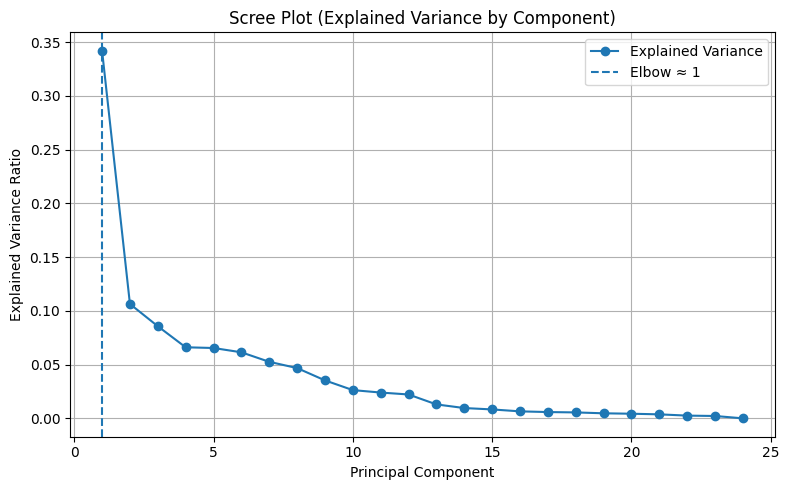

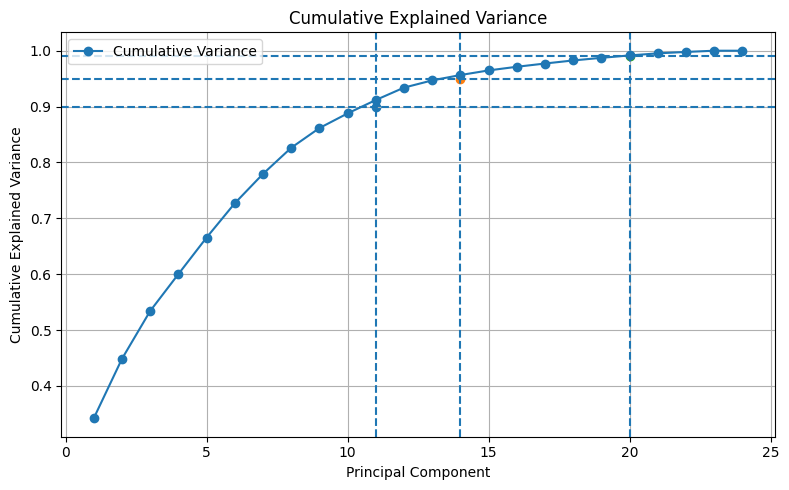

Number of components required to reach variance thresholds:


,Variance_Target,Num_Components
0,90%,11
1,95%,14
2,99%,20


In [ ]:
# ============================================================
# BOX 63 — Scree Plot and Cumulative Explained Variance Plot
#
# Purpose:
#   - Visualize explained variance across principal components
#   - Provide scree plot (individual variance)
#   - Provide cumulative explained variance plot
#   - Highlight key variance thresholds and elbow point
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = ["pca_variance_df"]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

required_columns = [
    "Component",
    "Explained_Variance_Ratio",
    "Cumulative_Explained_Variance"
]

missing_cols = [col for col in required_columns if col not in pca_variance_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in pca_variance_df: {missing_cols}")

# ------------------------------------------------------------
# Step 1 — Prepare data
# ------------------------------------------------------------
df_plot = pca_variance_df.copy()
df_plot["Component_Index"] = np.arange(1, len(df_plot) + 1)

# ------------------------------------------------------------
# Step 2 — Scree Plot (Explained Variance Ratio)
#   - Add vertical line for elbow (max drop heuristic)
# ------------------------------------------------------------
variance_diff = np.diff(df_plot["Explained_Variance_Ratio"])
elbow_idx = int(np.argmax(-variance_diff) + 1)  # +1 due to diff shift

plt.figure(figsize=(8, 5))

plt.plot(
    df_plot["Component_Index"],
    df_plot["Explained_Variance_Ratio"],
    marker="o",
    label="Explained Variance"
)

plt.axvline(
    x=elbow_idx,
    linestyle="--",
    label=f"Elbow ≈ {elbow_idx}"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (Explained Variance by Component)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 3 — Cumulative Explained Variance Plot
#   - Add threshold lines and intersection markers
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    df_plot["Component_Index"],
    df_plot["Cumulative_Explained_Variance"],
    marker="o",
    label="Cumulative Variance"
)

thresholds = [0.90, 0.95, 0.99]
threshold_results = {}

for t in thresholds:
    comp_idx = int(df_plot[df_plot["Cumulative_Explained_Variance"] >= t].iloc[0]["Component_Index"])
    threshold_results[t] = comp_idx

    plt.axhline(y=t, linestyle="--")
    plt.axvline(x=comp_idx, linestyle="--")

    # Mark intersection point
    plt.scatter(comp_idx, t)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 4 — Summary table for reporting
# ------------------------------------------------------------
threshold_table = pd.DataFrame({
    "Variance_Target": [f"{int(t*100)}%" for t in thresholds],
    "Num_Components": [threshold_results[t] for t in thresholds]
})

print("Number of components required to reach variance thresholds:")
display(threshold_table)

In [ ]:
# ============================================================
# BOX 64 — PCA Component Selection Candidates
#
# Purpose:
#   - Define candidate numbers of principal components (q)
#   - Use variance thresholds + elbow + local exploration
#   - Ensure coverage of low, mid, and high dimensional regimes
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = ["pca_variance_df"]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

required_columns = [
    "Component",
    "Explained_Variance_Ratio",
    "Cumulative_Explained_Variance"
]

missing_cols = [col for col in required_columns if col not in pca_variance_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in pca_variance_df: {missing_cols}")

# ------------------------------------------------------------
# Step 1 — Extract cumulative variance
# ------------------------------------------------------------
cum_var = pca_variance_df["Cumulative_Explained_Variance"].values
var_ratio = pca_variance_df["Explained_Variance_Ratio"].values
n_components_total = len(cum_var)

# ------------------------------------------------------------
# Step 2 — Determine components for variance thresholds
# ------------------------------------------------------------
def find_components_for_threshold(threshold):
    return int(np.argmax(cum_var >= threshold) + 1)

q_90 = find_components_for_threshold(0.90)
q_95 = find_components_for_threshold(0.95)
q_99 = find_components_for_threshold(0.99)

# ------------------------------------------------------------
# Step 3 — Detect elbow point (largest drop in variance)
# ------------------------------------------------------------
variance_diff = np.diff(var_ratio)
elbow_q = int(np.argmax(-variance_diff) + 1)

# ------------------------------------------------------------
# Step 4 — Build candidate q list
#   Strategy:
#     - small q (strong compression)
#     - around elbow (critical region)
#     - around thresholds (90/95/99)
#     - mid-range
#     - full dimension
# ------------------------------------------------------------
candidate_q = set()

# Small components
candidate_q.update([2, 3, 5])

# Around elbow (±1 for robustness)
candidate_q.update([
    max(1, elbow_q - 1),
    elbow_q,
    min(n_components_total, elbow_q + 1)
])

# Around thresholds (±1 for sensitivity)
for q in [q_90, q_95, q_99]:
    candidate_q.update([
        max(1, q - 1),
        q,
        min(n_components_total, q + 1)
    ])

# Mid-range
mid_q = int(n_components_total / 2)
candidate_q.add(mid_q)

# Full dimension
candidate_q.add(n_components_total)

# ------------------------------------------------------------
# Step 5 — Clean and sort candidates
# ------------------------------------------------------------
candidate_q = sorted(set(q for q in candidate_q if 1 <= q <= n_components_total))

# ------------------------------------------------------------
# Step 6 — Create summary table
# ------------------------------------------------------------
candidate_q_df = pd.DataFrame({
    "q (Num_Components)": candidate_q
})

# ------------------------------------------------------------
# Step 7 — Display results
# ------------------------------------------------------------
print("PCA Component Selection Candidates:")
display(candidate_q_df)

print("\nReference values:")
print(f"  Elbow q              = {elbow_q}")
print(f"  q_90 (90% variance)  = {q_90}")
print(f"  q_95 (95% variance)  = {q_95}")
print(f"  q_99 (99% variance)  = {q_99}")
print(f"  q_mid (50%)          = {mid_q}")
print(f"  q_full               = {n_components_total}")

PCA Component Selection Candidates:


,q (Num_Components)
0,1
1,2
2,3
3,5
4,10
5,11
6,12
7,13
8,14
9,15



Reference values:
  Elbow q              = 1
  q_90 (90% variance)  = 11
  q_95 (95% variance)  = 14
  q_99 (99% variance)  = 20
  q_mid (50%)          = 12
  q_full               = 24


In [ ]:
# ============================================================
# BOX 65 — PCA + KNN Sensitivity Analysis Across Components
#
# Purpose:
#   - Evaluate KNN performance across different numbers of
#     principal components (q)
#   - Use best_k (from baseline KNN analysis)
#   - Train on PCA-transformed training data only
#   - Evaluate on validation and test sets
#   - Add generalization-aware ranking (gap-aware selection)
# ============================================================

import pandas as pd
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "candidate_q",
    "best_k",
    "X_train_zscore", "X_val_zscore", "X_test_zscore",
    "y_train", "y_val", "y_test",
    "evaluate_knn"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

if not candidate_q:
    raise ValueError("candidate_q is empty.")

# ------------------------------------------------------------
# Step 1 — Run PCA + KNN evaluation for each q
# ------------------------------------------------------------
results = []

for q in candidate_q:

    # Initialize PCA
    pca = PCA(n_components=q)

    # Fit ONLY on training data
    X_train_pca = pca.fit_transform(X_train_zscore)

    # Transform validation and test sets
    X_val_pca   = pca.transform(X_val_zscore)
    X_test_pca  = pca.transform(X_test_zscore)

    # Convert to DataFrame
    pc_cols = [f"PC{i+1}" for i in range(q)]

    X_train_pca = pd.DataFrame(X_train_pca, columns=pc_cols, index=X_train_zscore.index)
    X_val_pca   = pd.DataFrame(X_val_pca,   columns=pc_cols, index=X_val_zscore.index)
    X_test_pca  = pd.DataFrame(X_test_pca,  columns=pc_cols, index=X_test_zscore.index)

    # Evaluate KNN
    val_acc, test_acc = evaluate_knn(
        feature_subset=pc_cols,
        k=best_k,
        X_train=X_train_pca,
        y_train=y_train,
        X_val=X_val_pca,
        y_val=y_val,
        X_test=X_test_pca,
        y_test=y_test
    )

    # Store results
    results.append({
        "q (Num_Components)": int(q),
        "Validation_Accuracy": float(val_acc),
        "Test_Accuracy": float(test_acc),
        "Val_Test_Gap": float(val_acc - test_acc),
        "Generalization_Score": float(test_acc - abs(val_acc - test_acc))
    })

# ------------------------------------------------------------
# Step 2 — Create results table
# ------------------------------------------------------------
pca_sensitivity_df = pd.DataFrame(results)

# ------------------------------------------------------------
# Step 3 — Sorting strategies
# ------------------------------------------------------------

# Standard (validation-based)
pca_sorted_val = pca_sensitivity_df.sort_values(
    by=["Validation_Accuracy", "q (Num_Components)"],
    ascending=[False, True]
).reset_index(drop=True)

# Generalization-aware (recommended for analysis)
pca_sorted_gen = pca_sensitivity_df.sort_values(
    by=["Generalization_Score", "Validation_Accuracy"],
    ascending=[False, False]
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 4 — Display results
# ------------------------------------------------------------
print("PCA + KNN Sensitivity Analysis:")
display(pca_sensitivity_df)

print("\nTop configurations (validation-based):")
display(pca_sorted_val.head(5))

print("\nTop configurations (generalization-aware):")
display(pca_sorted_gen.head(5))

# ------------------------------------------------------------
# Step 5 — Selection (KEEP ORIGINAL LOGIC)
#   - Do NOT override validation-based selection
# ------------------------------------------------------------
best_q = int(pca_sorted_val.loc[0, "q (Num_Components)"])
best_val_acc_pca = float(pca_sorted_val.loc[0, "Validation_Accuracy"])

best_test_acc_pca = float(
    pca_sensitivity_df.loc[
        pca_sensitivity_df["q (Num_Components)"] == best_q,
        "Test_Accuracy"
    ].iloc[0]
)

# ------------------------------------------------------------
# Step 6 — Recommended q (for analysis/report only)
# ------------------------------------------------------------
recommended_q = int(pca_sorted_gen.loc[0, "q (Num_Components)"])

# ------------------------------------------------------------
# Step 7 — Output
# ------------------------------------------------------------
print(f"\nBest q (validation-based) : {best_q}")
print(f"Validation Accuracy       : {best_val_acc_pca:.4f}")
print(f"Test Accuracy             : {best_test_acc_pca:.4f}")

print(f"\nRecommended q (generalization-aware): {recommended_q}")

PCA + KNN Sensitivity Analysis:


,q (Num_Components),Validation_Accuracy,Test_Accuracy,Val_Test_Gap,Generalization_Score
0,1,0.9625,0.9625,0.0000,0.9625
1,2,0.9750,0.9500,0.0250,0.9250
2,3,0.9875,0.9375,0.0500,0.8875
3,5,0.9750,0.9500,0.0250,0.9250
4,10,0.9750,0.9250,0.0500,0.8750
5,11,0.9750,0.9250,0.0500,0.8750
6,12,0.9750,0.9250,0.0500,0.8750
7,13,0.9875,0.9375,0.0500,0.8875
8,14,0.9875,0.9500,0.0375,0.9125
9,15,0.9875,0.9625,0.0250,0.9375



Top configurations (validation-based):


,q (Num_Components),Validation_Accuracy,Test_Accuracy,Val_Test_Gap,Generalization_Score
0,3,0.9875,0.9375,0.0500,0.8875
1,13,0.9875,0.9375,0.0500,0.8875
2,14,0.9875,0.9500,0.0375,0.9125
3,15,0.9875,0.9625,0.0250,0.9375
4,19,0.9875,0.9500,0.0375,0.9125



Top configurations (generalization-aware):


,q (Num_Components),Validation_Accuracy,Test_Accuracy,Val_Test_Gap,Generalization_Score
0,1,0.9625,0.9625,0.0000,0.9625
1,15,0.9875,0.9625,0.0250,0.9375
2,2,0.9750,0.9500,0.0250,0.9250
3,5,0.9750,0.9500,0.0250,0.9250
4,14,0.9875,0.9500,0.0375,0.9125



Best q (validation-based) : 3
Validation Accuracy       : 0.9875
Test Accuracy             : 0.9375

Recommended q (generalization-aware): 1


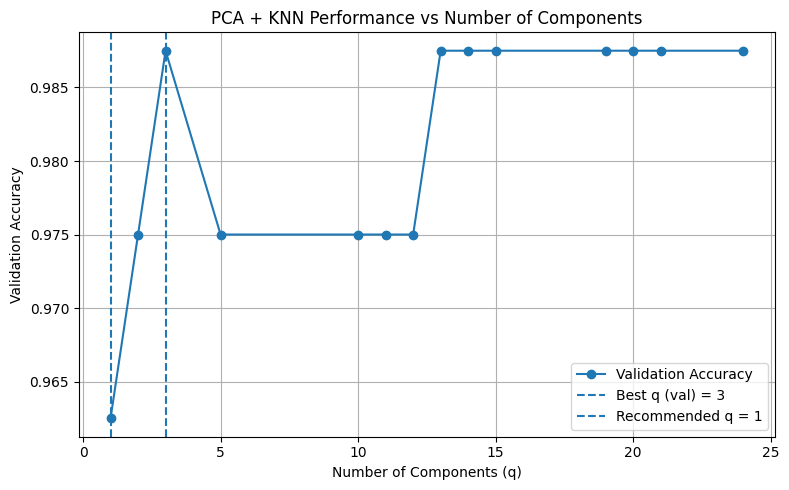

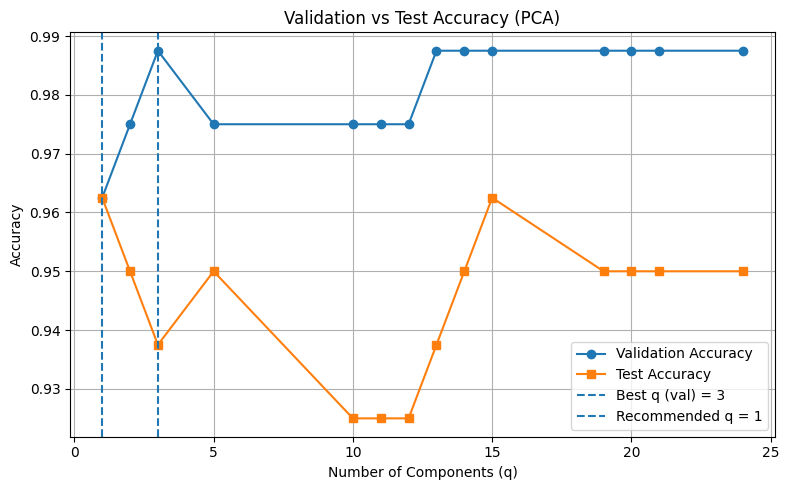

Best PCA configuration (validation-based):
q                  : 3
Validation Accuracy: 0.9875
Test Accuracy      : 0.9375
Gap               : 0.0500

Recommended PCA configuration (generalization-aware):
q                  : 1
Validation Accuracy: 0.9625
Test Accuracy      : 0.9625
Gap               : 0.0000

PCA row (recommended configuration for final comparison):


,Method,Num_Features,Validation_Accuracy,Test_Accuracy,Val_Test_Gap
0,PCA,1,0.9625,0.9625,0.0


In [ ]:
# ============================================================
# BOX 66 — PCA Plots, Best Selection, and Final Comparison Row
#
# Purpose:
#   - Visualize PCA performance vs number of components (q)
#   - Show both validation-based and generalization-aware selection
#   - Prepare PCA result row for final comparison table (Section D)
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "pca_sensitivity_df",
    "best_q",
    "best_val_acc_pca",
    "best_test_acc_pca",
    "recommended_q"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

required_columns = [
    "q (Num_Components)",
    "Validation_Accuracy",
    "Test_Accuracy",
    "Val_Test_Gap"
]

missing_cols = [col for col in required_columns if col not in pca_sensitivity_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in pca_sensitivity_df: {missing_cols}")

# ------------------------------------------------------------
# Step 1 — Prepare data
# ------------------------------------------------------------
df_plot = pca_sensitivity_df.sort_values(by="q (Num_Components)").reset_index(drop=True)

# Extract recommended row
recommended_row = df_plot[df_plot["q (Num_Components)"] == recommended_q].iloc[0]

# ------------------------------------------------------------
# Step 2 — Plot Validation Accuracy vs q
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    df_plot["q (Num_Components)"],
    df_plot["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=best_q,
    linestyle="--",
    label=f"Best q (val) = {best_q}"
)

plt.axvline(
    x=recommended_q,
    linestyle="--",
    label=f"Recommended q = {recommended_q}"
)

plt.xlabel("Number of Components (q)")
plt.ylabel("Validation Accuracy")
plt.title("PCA + KNN Performance vs Number of Components")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 3 — Plot Validation vs Test Accuracy
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    df_plot["q (Num_Components)"],
    df_plot["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    df_plot["q (Num_Components)"],
    df_plot["Test_Accuracy"],
    marker="s",
    label="Test Accuracy"
)

plt.axvline(
    x=best_q,
    linestyle="--",
    label=f"Best q (val) = {best_q}"
)

plt.axvline(
    x=recommended_q,
    linestyle="--",
    label=f"Recommended q = {recommended_q}"
)

plt.xlabel("Number of Components (q)")
plt.ylabel("Accuracy")
plt.title("Validation vs Test Accuracy (PCA)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 4 — Best vs Recommended summary
# ------------------------------------------------------------
best_row = df_plot[df_plot["q (Num_Components)"] == best_q].iloc[0]

print("Best PCA configuration (validation-based):")
print(f"q                  : {best_q}")
print(f"Validation Accuracy: {best_row['Validation_Accuracy']:.4f}")
print(f"Test Accuracy      : {best_row['Test_Accuracy']:.4f}")
print(f"Gap               : {best_row['Val_Test_Gap']:.4f}")

print("\nRecommended PCA configuration (generalization-aware):")
print(f"q                  : {recommended_q}")
print(f"Validation Accuracy: {recommended_row['Validation_Accuracy']:.4f}")
print(f"Test Accuracy      : {recommended_row['Test_Accuracy']:.4f}")
print(f"Gap               : {recommended_row['Val_Test_Gap']:.4f}")

# ------------------------------------------------------------
# Step 5 — Final PCA row (use recommended_q for reporting)
# ------------------------------------------------------------
pca_final_row = pd.DataFrame([{
    "Method": "PCA",
    "Num_Features": int(recommended_q),
    "Validation_Accuracy": float(recommended_row["Validation_Accuracy"]),
    "Test_Accuracy": float(recommended_row["Test_Accuracy"]),
    "Val_Test_Gap": float(recommended_row["Val_Test_Gap"])
}])

print("\nPCA row (recommended configuration for final comparison):")
display(pca_final_row)

Full PC1 decomposition:


,Feature,Weight,Abs_Weight
0,al,0.395865,0.395865
1,pcv,-0.380489,0.380489
2,hemo,-0.378051,0.378051
3,rc,-0.356109,0.356109
4,bu,0.327381,0.327381
5,sod,-0.277710,0.277710
6,sc,0.263336,0.263336
7,bgr,0.172025,0.172025
8,bp,0.156018,0.156018
9,htn,0.143111,0.143111



Top 10 features contributing to PC1:


,Feature,Weight,Abs_Weight
0,al,0.395865,0.395865
1,pcv,-0.380489,0.380489
2,hemo,-0.378051,0.378051
3,rc,-0.356109,0.356109
4,bu,0.327381,0.327381
5,sod,-0.277710,0.277710
6,sc,0.263336,0.263336
7,bgr,0.172025,0.172025
8,bp,0.156018,0.156018
9,htn,0.143111,0.143111


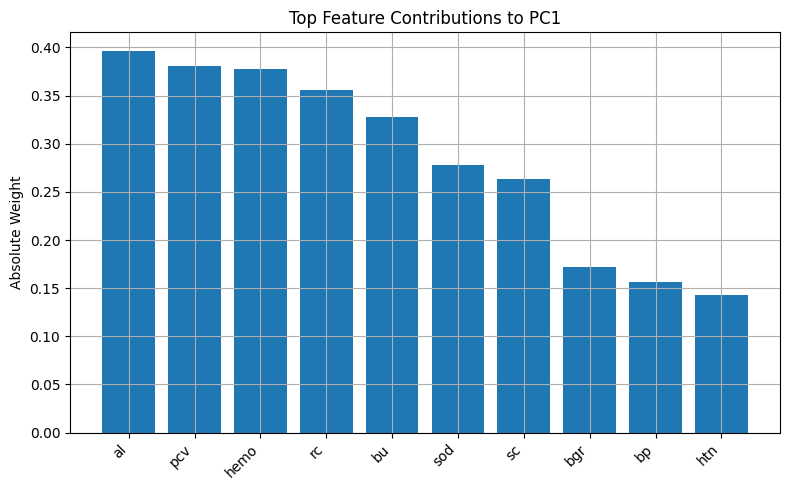

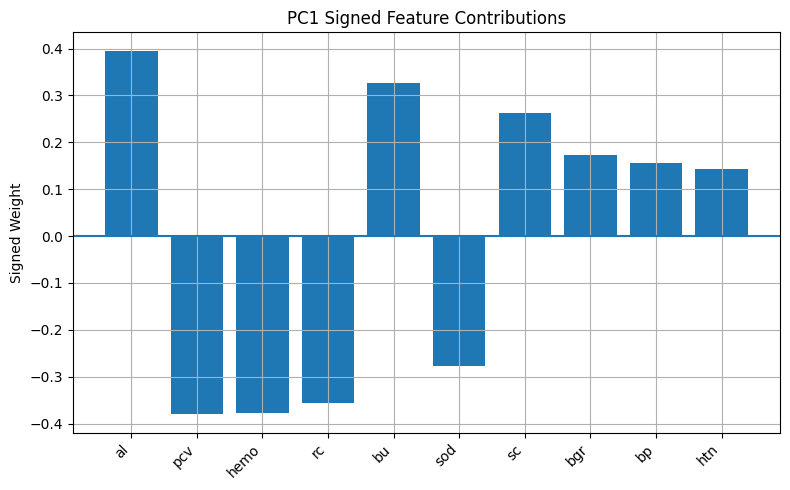


PC1 Approximate Formula:

PC1 = 0.135*age + 0.156*bp + -0.001*sg + 0.396*al + 0.106*su + -0.041*rbc + -0.096*pc + 0.063*pcc + 0.035*ba + 0.172*bgr + 0.327*bu + 0.263*sc + -0.278*sod + 0.101*pot + -0.378*hemo + -0.380*pcv + 0.096*wc + -0.356*rc + 0.143*htn + 0.107*dm + 0.034*cad + -0.085*appet + 0.079*pe + 0.098*ane ...


In [ ]:
# ============================================================
# BOX 67 — PCA PC1 Decomposition (Feature Weights Analysis)
#
# Purpose:
#   - Extract exact formula of PC1
#   - Show feature weights (loadings)
#   - Rank most important features
#   - Visualize contributions
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = ["pca_full", "X_train_zscore"]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

# ------------------------------------------------------------
# Step 1 — Extract PC1 weights
# ------------------------------------------------------------
pc1_weights = pd.Series(
    pca_full.components_[0],   # PC1
    index=X_train_zscore.columns,
    name="PC1_Weight"
)

# ------------------------------------------------------------
# Step 2 — Create full table
# ------------------------------------------------------------
pc1_df = pd.DataFrame({
    "Feature": pc1_weights.index,
    "Weight": pc1_weights.values,
    "Abs_Weight": np.abs(pc1_weights.values)
})

# Sort by importance
pc1_df = pc1_df.sort_values(by="Abs_Weight", ascending=False).reset_index(drop=True)

print("Full PC1 decomposition:")
display(pc1_df)

# ------------------------------------------------------------
# Step 3 — Top important features
# ------------------------------------------------------------
top_k = 10
top_features = pc1_df.head(top_k)

print(f"\nTop {top_k} features contributing to PC1:")
display(top_features)

# ------------------------------------------------------------
# Step 4 — Bar plot (importance)
# ------------------------------------------------------------
plt.figure(figsize=(8,5))

plt.bar(top_features["Feature"], top_features["Abs_Weight"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("Absolute Weight")
plt.title("Top Feature Contributions to PC1")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 5 — Signed weights (direction)
# ------------------------------------------------------------
plt.figure(figsize=(8,5))

plt.bar(top_features["Feature"], top_features["Weight"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("Signed Weight")
plt.title("PC1 Signed Feature Contributions")
plt.axhline(0)
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 6 — Exact PC1 formula (printable)
# ------------------------------------------------------------
print("\nPC1 Approximate Formula:\n")

formula_terms = [
    f"{w:.3f}*{f}" for f, w in zip(pc1_weights.index, pc1_weights.values)
]

formula_str = "PC1 = " + " + ".join(formula_terms)

print(formula_str[:500] + " ...")  # shortened for readability

Unified Comparison (All Methods + PCA):


,Method,Num_Features,Validation_Accuracy,Test_Accuracy,Val_Test_Gap,Generalization_Score,Composite_Score
0,PCA,1,0.9625,0.9625,0.0000,0.9625,1.000000
1,Filter,15,1.0000,0.9625,0.0375,0.9250,0.765761
2,Hybrid,3,1.0000,0.9375,0.0625,0.8750,0.595109
3,Forward,3,1.0000,0.9375,0.0625,0.8750,0.595109
4,Baseline (All Features),24,0.9875,0.9500,0.0375,0.9125,0.587500
5,Backward,4,1.0000,0.9000,0.1000,0.8000,0.173913


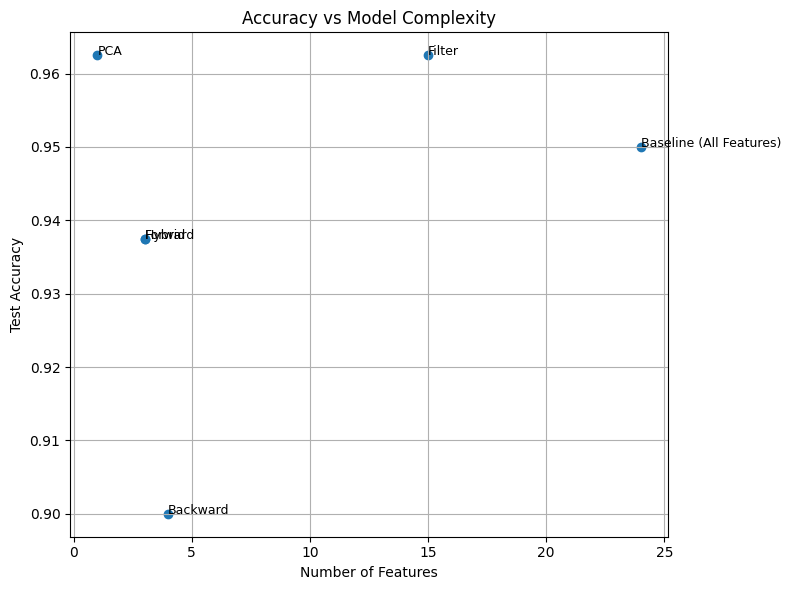

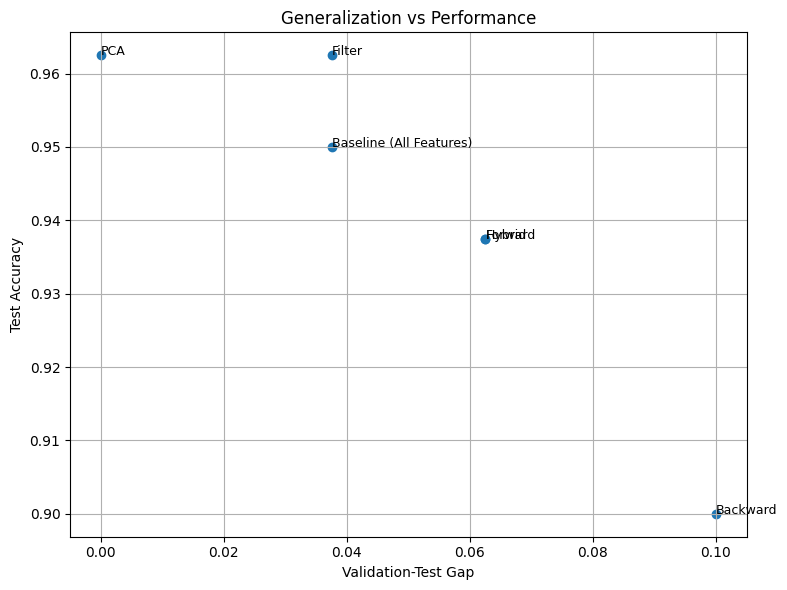

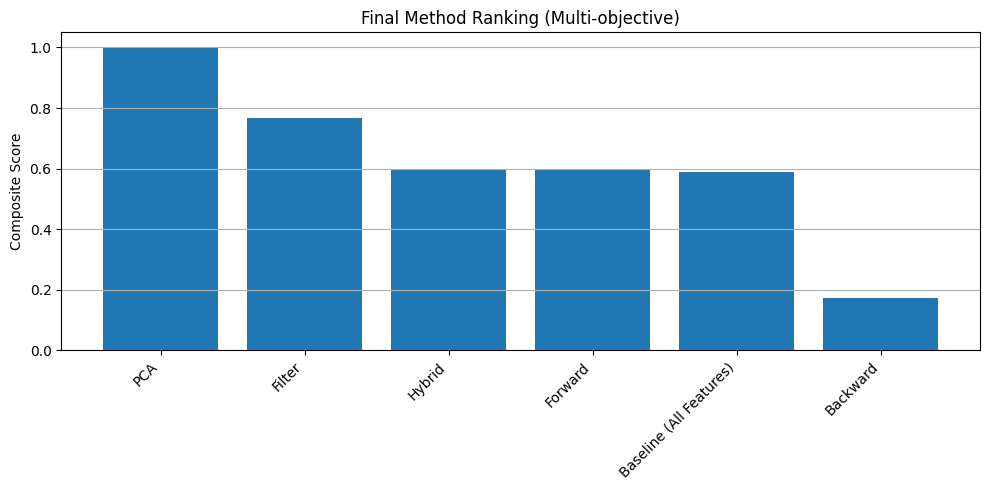


FINAL SELECTED MODEL (Multi-objective decision):
Method             : PCA
Test Accuracy      : 0.9625
Validation Accuracy: 0.9625
Gap                : 0.0000
Num Features       : 1
Composite Score    : 1.0000

Key Insights:
- Highest Test Accuracy: Filter (0.9625)
- Most Stable Model: PCA (Gap=0.0000)
- Simplest Model: PCA (1 features)


In [ ]:
# ============================================================
# BOX 68 — Ultimate Integrated Analysis (All Methods + PCA)
#
# Purpose:
#   - Integrate PCA results into final comparison
#   - Provide unified analytical dashboard
#   - Perform multi-criteria decision analysis
#   - Visualize trade-offs: accuracy vs complexity vs stability
#   - Deliver final robust model selection
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Step 0 — Preconditions
# ------------------------------------------------------------
required_objects = [
    "final_comparison_df",
    "pca_final_row"
]

missing = [obj for obj in required_objects if obj not in globals()]
if missing:
    raise NameError(f"Missing required objects: {missing}")

# ------------------------------------------------------------
# Step 1 — Merge PCA into final comparison
# ------------------------------------------------------------
final_all_methods_df = pd.concat(
    [final_comparison_df, pca_final_row],
    ignore_index=True
)

# Recompute derived metrics (safe)
final_all_methods_df["Val_Test_Gap"] = (
    final_all_methods_df["Validation_Accuracy"] - final_all_methods_df["Test_Accuracy"]
)

final_all_methods_df["Generalization_Score"] = (
    final_all_methods_df["Test_Accuracy"] - final_all_methods_df["Val_Test_Gap"]
)

# ------------------------------------------------------------
# Step 2 — Normalize metrics for fair comparison
# ------------------------------------------------------------
def minmax_norm(series):
    s = series.astype(float)
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

final_all_methods_df["Norm_Test"] = minmax_norm(final_all_methods_df["Test_Accuracy"])
final_all_methods_df["Norm_Gap"]  = minmax_norm(final_all_methods_df["Val_Test_Gap"])
final_all_methods_df["Norm_Size"] = minmax_norm(final_all_methods_df["Num_Features"])

# ------------------------------------------------------------
# Step 3 — Composite score (multi-objective ranking)
#   - High Test Accuracy → GOOD
#   - Low Gap → GOOD
#   - Low Features → GOOD
# ------------------------------------------------------------
final_all_methods_df["Composite_Score"] = (
    0.5 * final_all_methods_df["Norm_Test"] +
    0.3 * (1 - final_all_methods_df["Norm_Gap"]) +
    0.2 * (1 - final_all_methods_df["Norm_Size"])
)

# ------------------------------------------------------------
# Step 4 — Ranking
# ------------------------------------------------------------
final_ranked_df = final_all_methods_df.sort_values(
    by="Composite_Score",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Step 5 — Display unified table
# ------------------------------------------------------------
print("Unified Comparison (All Methods + PCA):")
display_cols = [
    "Method",
    "Num_Features",
    "Validation_Accuracy",
    "Test_Accuracy",
    "Val_Test_Gap",
    "Generalization_Score",
    "Composite_Score"
]
display(final_ranked_df[display_cols])

# ------------------------------------------------------------
# Step 6 — Trade-off Visualization (Accuracy vs Features)
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    final_all_methods_df["Num_Features"],
    final_all_methods_df["Test_Accuracy"]
)

for _, row in final_all_methods_df.iterrows():
    plt.text(
        row["Num_Features"],
        row["Test_Accuracy"],
        row["Method"],
        fontsize=9
    )

plt.xlabel("Number of Features")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Model Complexity")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 7 — Stability vs Performance
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    final_all_methods_df["Val_Test_Gap"],
    final_all_methods_df["Test_Accuracy"]
)

for _, row in final_all_methods_df.iterrows():
    plt.text(
        row["Val_Test_Gap"],
        row["Test_Accuracy"],
        row["Method"],
        fontsize=9
    )

plt.xlabel("Validation-Test Gap")
plt.ylabel("Test Accuracy")
plt.title("Generalization vs Performance")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 8 — Composite Score Visualization
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.bar(
    final_ranked_df["Method"],
    final_ranked_df["Composite_Score"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Composite Score")
plt.title("Final Method Ranking (Multi-objective)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Step 9 — Final Decision
# ------------------------------------------------------------
best_final = final_ranked_df.iloc[0]

print("\nFINAL SELECTED MODEL (Multi-objective decision):")
print(f"Method             : {best_final['Method']}")
print(f"Test Accuracy      : {best_final['Test_Accuracy']:.4f}")
print(f"Validation Accuracy: {best_final['Validation_Accuracy']:.4f}")
print(f"Gap                : {best_final['Val_Test_Gap']:.4f}")
print(f"Num Features       : {best_final['Num_Features']}")
print(f"Composite Score    : {best_final['Composite_Score']:.4f}")

# ------------------------------------------------------------
# Step 10 — Insight generation (auto-analysis)
# ------------------------------------------------------------
print("\nKey Insights:")

# Best accuracy
best_acc = final_all_methods_df.loc[
    final_all_methods_df["Test_Accuracy"].idxmax()
]
print(f"- Highest Test Accuracy: {best_acc['Method']} ({best_acc['Test_Accuracy']:.4f})")

# Most stable
most_stable = final_all_methods_df.loc[
    final_all_methods_df["Val_Test_Gap"].abs().idxmin()
]
print(f"- Most Stable Model: {most_stable['Method']} (Gap={most_stable['Val_Test_Gap']:.4f})")

# Simplest model
simplest = final_all_methods_df.loc[
    final_all_methods_df["Num_Features"].idxmin()
]
print(f"- Simplest Model: {simplest['Method']} ({simplest['Num_Features']} features)")